PART 1


In [ ]:
import numpy as np
import random
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import Dataset
import torchvision
import torchvision.transforms as T
from torchvision.transforms import ToPILImage

from PIL import Image
from scipy.ndimage.interpolation import rotate
from sklearn.linear_model import LogisticRegression
from tqdm import tqdm
from copy import deepcopy
from torch.utils.data import DataLoader




class EdgeDetectionDataset(Dataset):
    def __init__(self, domain_config, mode="train", transform=None) -> None:
        """
        Args:
            domain_config (dict): Domain configuration
                data_per_class (int): Number of data per class
                num_classes (int): Number of classes
                class_type (list): List of class types
                spatial_resolution (int): length of height and width of the image
                max_edge_width (int): Maximum edge width
                max_edge_intensity (float): Maximum edge intensity
                min_edge_intensity (float): Minimum edge intensity
                max_background_intensity (float): Maximum background intensity
                min_background_intensity (float): Minimum background intensity
                possible_edge_location_ratio (float): Confine the possible edge location to a ratio of the spatial resolution
                num_horizontal_edge (int): Number of horizontal edges
                num_vertical_edge (int): Number of vertical edges
                use_permutation (bool): Whether to apply random permutation on the image
            mode (str): Mode of the dataset (train, val, test)
            transform (callable, optional): Optional transform to be applied on a sample.
        """
        self.data_per_class = domain_config.get("data_per_class", 1000)
        self.num_classes = domain_config.get("num_classes", 3)
        self.class_type = domain_config.get(
            "class_type", ["horizontal", "vertical", "none"]
        )
        self.spatial_resolution = domain_config.get("spatial_resolution", 28)
        self.min_edge_width = domain_config.get("min_edge_width", 1)
        self.max_edge_width = domain_config.get("max_edge_width", 4)
        self.max_edge_intensity = domain_config.get("max_edge_intensity", 1)
        self.min_edge_intensity = domain_config.get("min_edge_intensity", 0.25)
        self.max_background_intensity = domain_config.get(
            "max_background_intensity", 0.2
        )
        self.min_background_intensity = domain_config.get("min_background_intensity", 0)
        self.possible_edge_location_ratio = domain_config.get(
            "possible_edge_location_ratio", 1.0
        )
        self.num_horizontal_edge = domain_config.get("num_horizontal_edge", 1)
        self.num_vertical_edge = domain_config.get("num_vertical_edge", 1)
        self.num_diagonal_edge = domain_config.get("num_diagonal_edge", 1)
        self.use_permutation = domain_config.get("use_permutation", False)
        self.permutater = domain_config.get("permutater", None)
        self.unpermutater = domain_config.get("unpermutater", None)

        if self.possible_edge_location_ratio < 1.0:
            self.train_val_domain_shift = True
        else:
            self.train_val_domain_shift = False

        self.possible_edge_location = int(
            self.possible_edge_location_ratio * self.spatial_resolution
        )
        self.mode = mode

        assert self.num_classes == len(
            self.class_type
        ), "Number of classes must match the number of class types"

        assert self.mode in (
            "train",
            "valid",
            "test",
        ), "Mode must be either train, valid, or test"

        self.X = None
        self.y = None

        if self.use_permutation:
            assert self.permutater is not None, "permutater must be provided"
            assert self.unpermutater is not None, "Unpermutater must be provided"

        self._generate_dataset()

        self.transform = transform

    def __len__(self):
        """
        Returns:
            int: Length of the dataset
        """
        return len(self.X)

    def __getitem__(self, idx):
        """
        Args:
            idx (int): Index of the sample
        Returns:
            tuple: (sample, label)
        """
        if torch.is_tensor(idx):
            idx = idx.tolist()

        sample = self.X[idx]
        label = self.y[idx]

        if self.transform:
            sample = self.transform(sample)

        return sample, label

    def get_permutater(self):
        """
        Returns:
            np.ndarray: Permutation matrix
        """
        return self.permutater

    def get_unpermutater(self):
        """
        Returns:
            np.ndarray: Unpermutation matrix
        """
        return self.unpermutater

    def _permute_pixels(self, X):
        """
        Args:
            X (np.ndarray): Image
        Returns:
            np.ndarray: Permuted image
        """
        assert X.shape[0] == self.data_per_class, "Invalid image shape"
        assert len(X.shape) == 4, "Invalid image shape"

        n, h, w, c = X.shape

        X = X.reshape(n, h * w, c)
        X = X[:, self.permutater, :]
        X = X.reshape(n, h, w, c)

        return X

    def _edge_intensity(self, edge_type="horizontal"):
        """
        Args:
            edge_type (str): Type of edge (horizontal, vertical, both, diagonal)
        Returns:
            np.ndarray: Edge intensity
        """
        if edge_type == "horizontal":
            num_edge = self.num_horizontal_edge
        elif edge_type == "vertical":
            num_edge = self.num_vertical_edge
        elif edge_type == "diagonal":
            num_edge = self.num_diagonal_edge
        elif edge_type == "both":
            num_edge = self.num_horizontal_edge + self.num_vertical_edge
        else:
            raise ValueError("Invalid edge type")

        return np.random.uniform(
            self.min_edge_intensity,
            self.max_edge_intensity,
            size=(self.data_per_class, num_edge),
        )

    def _edge_location(self, edge_type="horizontal"):
        """
        Args:
            edge_type (str): Type of edge (horizontal, vertical, both, diagonal)
        Returns:
            np.ndarray: Edge location
        """
        max_edge_width = self.max_edge_width + 1
        if edge_type == "horizontal":
            num_edge = self.num_horizontal_edge
        elif edge_type == "vertical":
            num_edge = self.num_vertical_edge
        elif edge_type == "diagonal":
            num_edge = self.num_diagonal_edge
            max_edge_width = int(self.max_edge_width / np.sqrt(2))
        elif edge_type == "both":
            num_edge = self.num_horizontal_edge + self.num_vertical_edge
        else:
            raise ValueError("Invalid edge type")

        edge_width = np.random.randint(
            self.min_edge_width, max_edge_width, size=(self.data_per_class, num_edge)
        )

        if self.mode == "train" and self.train_val_domain_shift:
            edge_location_start_idx = np.random.randint(
                0,
                self.possible_edge_location - edge_width,
                size=(self.data_per_class, num_edge),
            )
            edge_location_end_idx = np.clip(
                edge_location_start_idx + edge_width,
                0,
                self.possible_edge_location-1,
            )

        elif self.mode == "valid" and self.train_val_domain_shift:
            edge_location_start_idx = np.random.randint(
                self.possible_edge_location,
                self.spatial_resolution - edge_width,
                size=(self.data_per_class, num_edge),
            )
            edge_location_end_idx = np.clip(
                edge_location_start_idx + edge_width,
                self.possible_edge_location,
                self.spatial_resolution-1,
            )

        else:
            edge_location_start_idx = np.random.randint(
                0,
                self.spatial_resolution - edge_width,
                size=(self.data_per_class, num_edge),
            )
            edge_location_end_idx = np.clip(
                edge_location_start_idx + edge_width,
                0,
                self.spatial_resolution-1,
            )

        return edge_location_start_idx, edge_location_end_idx

    def _generate_hoizontal_edge_images(self):
        """
        Generate horizontal edge images
        Returns:
            np.ndarray: Generated horizontal edge images
        """
        assert (
            self.num_horizontal_edge > 0
        ), "Number of horizontal edge must be greater than 0"

        X = self._generate_background_images()

        edge_location_start_idx, edge_location_end_idx = self._edge_location(
            edge_type="horizontal"
        )
        edge_intensity = self._edge_intensity()

        for i in range(self.data_per_class):
            for j in range(self.num_horizontal_edge):
                X[
                    i, edge_location_start_idx[i, j] : edge_location_end_idx[i, j], :, :
                ] = edge_intensity[i, j]

        return X

    def _generate_vertical_edge_images(self):
        """
        Generate vertical edge images
        Returns:
            np.ndarray: Generated vertical edge images
        """
        assert (
            self.num_vertical_edge > 0
        ), "Number of vertical edge must be greater than 0"

        X = self._generate_background_images()

        edge_location_start_idx, edge_location_end_idx = self._edge_location(
            edge_type="vertical"
        )
        edge_intensity = self._edge_intensity()

        for i in range(self.data_per_class):
            for j in range(self.num_vertical_edge):
                X[
                    i,
                    :,
                    edge_location_start_idx[i, j] : edge_location_end_idx[i, j],
                    :,
                ] = edge_intensity[i, j]

        return X

    def _generate_both_edge_images(self):
        """
        Generate horizontal/vertical edge images
        Returns:
            np.ndarray: Generated horizontal/vertical edge images
        """
        assert (
            self.num_horizontal_edge > 0
        ), "Number of horizontal edge must be greater than 0"
        assert (
            self.num_vertical_edge > 0
        ), "Number of vertical edge must be greater than 0"

        X = self._generate_background_images()

        edge_location_start_idx, edge_location_end_idx = self._edge_location(
            edge_type="both"
        )
        edge_intensity = self._edge_intensity(edge_type="both")

        for i in range(self.data_per_class):
            for j in range(self.num_horizontal_edge):
                X[
                    i,
                    edge_location_start_idx[i, j] : edge_location_end_idx[i, j],
                    :,
                    :,
                ] = edge_intensity[i, j]
            for j in range(self.num_vertical_edge):
                X[
                    i,
                    :,
                    edge_location_start_idx[i, j] : edge_location_end_idx[i, j],
                ] = edge_intensity[i, self.num_horizontal_edge + j]

        return X

    def _generate_diagonal_edge_images(self):
        """
        Generate diagonal edge images by rotating images
        Returns:
            np.ndarray: Generated diagonal edge images
        """
        assert (
            self.num_diagonal_edge > 0
        ), "Number of diagonal edge must be greater than 0"

        X = self._generate_background_images()
        background_intensity = np.mean(X, axis=(1, 2, 3))

        edge_location_start_idx, edge_location_end_idx = self._edge_location(
            edge_type="diagonal"
        )
        edge_intensity = self._edge_intensity(edge_type="diagonal")

        random_angle = np.random.choice(
            [30, 45, 120, 135], size=(self.data_per_class, self.num_diagonal_edge)
        )

        for i in range(self.data_per_class):
            for j in range(self.num_diagonal_edge):
                if i % 2 == 0:  # horizontal
                    X[
                        i,
                        edge_location_start_idx[i, j] : edge_location_end_idx[i, j],
                        :,
                        :,
                    ] = edge_intensity[i, j]
                else:  # vertical
                    X[
                        i,
                        :,
                        edge_location_start_idx[i, j] : edge_location_end_idx[i, j],
                    ] = edge_intensity[i, j]
                X[i] = rotate(
                    X[i],
                    random_angle[i, j],
                    reshape=False,
                    mode="constant",
                    cval=background_intensity[i],
                )
        return X

    def _generate_background_images(self):
        """
        Generate background images
        Returns:
            np.ndarray: Generated background images
        """
        X = np.ones(
            (self.data_per_class, self.spatial_resolution, self.spatial_resolution, 1),
        )  # NHWC format
        X *= np.random.uniform(
            self.min_background_intensity,
            self.max_background_intensity,
            size=(self.data_per_class, 1, 1, 1),
        )
        return X

    def get_image_statistics(self):
        """
        Get image statistics
        Returns:
            tuple: (mean, std)
            mean (float): Mean of the images
            std (float): Standard deviation of the images
        """
        return self._mean, self._std

    def _generate_dataset(self):
        """
        Generate dataset
        Returns:
            tuple: (X, y)
            X (list of PIL Image): Generated images
            y (np.ndarray): Generated labels
        """
        num_data = self.data_per_class * self.num_classes
        self.X = np.zeros(
            (num_data, self.spatial_resolution, self.spatial_resolution, 1)
        )
        self.y = np.zeros((num_data,), dtype=np.int64)
        for i in range(self.num_classes):
            class_type = self.class_type[i]
            if class_type == "horizontal":
                X = self._generate_hoizontal_edge_images()
            elif class_type == "vertical":
                X = self._generate_vertical_edge_images()
            elif class_type == "both":
                X = self._generate_both_edge_images()
            elif class_type == "diagonal":
                X = self._generate_diagonal_edge_images()
            elif class_type == "none":
                X = self._generate_background_images()
            else:
                raise ValueError("Invalid class type")

            assert X.shape == (
                self.data_per_class,
                self.spatial_resolution,
                self.spatial_resolution,
                1,
            )  # NHWC format

            # permute pixels
            if self.use_permutation:
                X = self._permute_pixels(X)

            self.X[i * self.data_per_class : (i + 1) * self.data_per_class] = X
            self.y[i * self.data_per_class : (i + 1) * self.data_per_class] = i

        # Compute mean and std
        self._mean = np.mean(self.X)
        self._std = np.std(self.X)

        # np.float32 -> np.uint8
        self.X = (self.X * 255).astype(np.uint8)

        # Convert ndarray to PIL Image
        self.X = [T.functional.to_pil_image(x) for x in self.X]


def count_parameters(model, only_trainable=False):
    if only_trainable:
        return sum(p.numel() for p in model.parameters() if p.requires_grad)
    else:
        return sum(p.numel() for p in model.parameters())

def freeze_conv_layer(model):
    for name, param in model.named_parameters():
        if name.startswith('conv'):
            param.requires_grad = False

def init_conv_kernel_with_edge_detector(model):
    # Get kernel size
    kernel_size = model.conv1.kernel_size[0]

    # number of filters should be 3
    num_filters = model.conv1.out_channels
    assert num_filters == 3, "Number of filters should be 3"

    if kernel_size == 2:
        # 2 x 2 edge detector
        horizontal_edge_detector = torch.tensor([[1, 1], [-1, -1]], dtype=torch.float32)
        vertical_edge_detector = torch.tensor([[1, -1], [1, -1]], dtype=torch.float32)
        none_edge_detector = torch.tensor([[0, 0], [0, 0]], dtype=torch.float32)
    elif kernel_size == 7:
        # 7 x 7 edge detector
        horizontal_edge_detector = torch.tensor([
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [1, 1, 1, 1, 1, 1, 1],
            [-1, -1, -1, -1, -1, -1, -1],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0],
            [0, 0, 0, 0, 0, 0, 0]], dtype=torch.float32)
        vertical_edge_detector = horizontal_edge_detector.T
        none_edge_detector = model.conv1.weight.data[0, 0] # torch.zeros((7, 7), dtype=torch.float32)
    else:
        horizontal_edge_detector = torch.from_numpy(custom_sobel((kernel_size, kernel_size), 0))
        vertical_edge_detector = torch.from_numpy(custom_sobel((kernel_size, kernel_size), 1))
        none_edge_detector = torch.from_numpy(np.zeros((kernel_size, kernel_size)))

    edge_detector = torch.stack([horizontal_edge_detector, vertical_edge_detector, none_edge_detector])
    model.conv1.weight.data = edge_detector.view(model.num_filter, 1, model.kernel_size, model.kernel_size)
    model.conv2.weight.data = torch.cat([model.conv1.weight.data, model.conv1.weight.data, model.conv1.weight.data], dim=1)

    # type casting
    model.conv1.weight.data = model.conv1.weight.data.type(torch.FloatTensor)
    model.conv2.weight.data = model.conv2.weight.data.type(torch.FloatTensor)

    # bias
    model.conv1.bias.data = torch.tensor([0, 0, 0], dtype=torch.float32)
    model.conv2.bias.data = torch.tensor([0, 0, 0], dtype=torch.float32)

def custom_sobel(shape, axis):
    """
    shape must be odd: eg. (5,5)
    axis is the direction, with 0 to positive x and 1 to positive y
    """
    k = np.zeros(shape, dtype=np.float32)
    p = [(j,i) for j in range(shape[0])
           for i in range(shape[1])
           if not (i == (shape[1] -1)/2. and j == (shape[0] -1)/2.)]

    for j, i in p:
        j_ = int(j - (shape[0] -1)/2.)
        i_ = int(i - (shape[1] -1)/2.)
        k[j,i] = (i_ if axis==0 else j_)/float(i_*i_ + j_*j_)
    return k


def set_seed(seed):
    """
    Set the seed for all random number generators.
    """
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    torch.cuda.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)


def train_one_epoch(
    model,
    optimizer,
    criterion,
    train_loader,
    device,
    epoch,
    log_interval=100,
    verbose=True,
):
    model.train()
    # return the average loss and accuracy
    train_loss = 0
    correct = 0

    for batch_idx, (data, target) in enumerate(train_loader):
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = model(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()

        train_loss += loss.item()
        pred = output.argmax(
            dim=1, keepdim=True
        )
        correct += pred.eq(target.view_as(pred)).sum().item()

        if batch_idx % log_interval == 0 and verbose:
            print(
                "Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}".format(
                    epoch,
                    batch_idx * len(data),
                    len(train_loader.dataset),
                    100.0 * batch_idx / len(train_loader),
                    loss.item(),
                )
            )

    train_loss /= len(train_loader.dataset)
    train_accuracy = correct / len(train_loader.dataset) * 100.

    return train_loss, train_accuracy

def _generate_confusion_matrix(pred_list, target_list):
    pred_list = torch.cat(pred_list)
    target_list = torch.cat(target_list)

    assert pred_list.shape[0] == target_list.shape[0], "predictions and targets should have the same length"

    matrix_size = max(max(pred_list), max(target_list)) + 1
    confusion_matrix = torch.zeros(matrix_size, matrix_size)

    for t, p in zip(target_list.view(-1), pred_list.view(-1)):
        confusion_matrix[t.long(), p.long()] += 1

    return confusion_matrix.cpu().numpy()

def evaluate(model, criterion, valid_loader, device, verbose=True):
    model.eval()
    valid_loss = 0
    correct = 0

    pred_list, target_list = [], []
    confusion_matrix = torch.zeros(4, 4)

    with torch.no_grad():
        for data, target in valid_loader:
            data, target = data.to(device), target.to(device)
            output = model(data)
            valid_loss += criterion(output, target).item()  # sum up batch loss
            pred = output.argmax(
                dim=1, keepdim=True
            )  # get the index of the max log-probability
            correct += pred.eq(target.view_as(pred)).sum().item()

            pred_list.append(pred)
            target_list.append(target)

    confusion_matrix = _generate_confusion_matrix(pred_list, target_list)

    valid_loss /= len(valid_loader.dataset)
    valid_accuracy = 100.0 * correct / len(valid_loader.dataset)

    if verbose:
        print(
            "Validation Result: Average loss: {:.4f}, Accuracy: {}/{} ({:.0f}%)".format(
                valid_loss, correct, len(valid_loader.dataset), valid_accuracy
            )
        )

    return valid_loss, valid_accuracy, confusion_matrix


def vis_training_curve(cnn_train_loss, cnn_train_acc, mlp_train_loss, mlp_train_acc, label="MLP"):
    # if mlp lists are empty, then we are only plotting the CNN
    if mlp_train_loss is None or len(mlp_train_loss) == 0:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(cnn_train_loss, label="CNN")
        ax[0].set_title("Training Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(cnn_train_acc, label="CNN")
        ax[1].set_title("Training Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()

    # if cnn lists are empty, then we are only plotting the MLP
    elif cnn_train_loss is None or len(cnn_train_loss) == 0:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(mlp_train_loss, label=label)
        ax[0].set_title("Training Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(mlp_train_acc, label=label)
        ax[1].set_title("Training Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()

    # if both lists are not empty, then we are plotting both CNN and MLP
    else:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(cnn_train_loss, label="CNN")
        ax[0].plot(mlp_train_loss, label=label)
        ax[0].set_title("Training Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(cnn_train_acc, label="CNN")
        ax[1].plot(mlp_train_acc, label=label)
        ax[1].set_title("Training Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()


def vis_validation_curve(cnn_valid_loss, cnn_valid_acc, mlp_valid_loss, mlp_valid_acc,  label="MLP"):
    # if mlp lists are empty, then we are only plotting the CNN
    if mlp_valid_loss is None or len(mlp_valid_loss) == 0:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(cnn_valid_loss, label="CNN")
        ax[0].set_title("Validation Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(cnn_valid_acc, label="CNN")
        ax[1].set_title("Validation Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()

    # if cnn lists are empty, then we are only plotting the MLP
    elif cnn_valid_loss is None or len(cnn_valid_loss) == 0:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(mlp_valid_loss, label=label)
        ax[0].set_title("Validation Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(mlp_valid_acc, label=label)
        ax[1].set_title("Validation Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()

    # if both lists are not empty, then we are plotting both CNN and MLP
    else:
        fig, ax = plt.subplots(1, 2, figsize=(20, 5))
        ax[0].plot(cnn_valid_loss, label="CNN")
        ax[0].plot(mlp_valid_loss, label=label)
        ax[0].set_title("Validation Loss")
        ax[0].set_xlabel("Epoch")
        ax[0].set_ylabel("Loss")
        ax[0].legend()
        ax[0].grid()

        ax[1].plot(cnn_valid_acc, label="CNN")
        ax[1].plot(mlp_valid_acc, label=label)
        ax[1].set_title("Validation Accuracy")
        ax[1].set_xlabel("Epoch")
        ax[1].set_ylabel("Accuracy (%)")
        ax[1].legend()
        ax[1].grid()

        plt.show()


def vis_kernel(tensor, ch=0, allkernels=False, nrow=8, padding=1, title=None, cmap="Blues", ax=None):
    n, c, h, w = tensor.shape

    if allkernels:
        tensor = tensor.view(n * c, -1, h, w)
    elif c != 3:
        tensor = tensor[:, ch, :, :].unsqueeze(dim=1)

    rows = np.min((tensor.shape[0] // nrow + 1, 64))
    grid = (
        torchvision.utils.make_grid(tensor, nrow=nrow, normalize=True, padding=padding)
        .numpy()
        .transpose((1, 2, 0))
    )
    plt.figure(figsize=(nrow, rows))
    plt.imshow(grid, cmap=cmap)
    # plt.colorbar(cmap=cmap)
    if title is not None:
        plt.title(title, fontsize="small")
    plt.axis("off")
    plt.ioff()
    plt.show()


def vis_confusion_matrix(confusion_matrix, class_names=None, title=None):
    fig = plt.figure(figsize=(10, 10))
    ax = fig.add_subplot(111)
    cax = ax.matshow(confusion_matrix, cmap=plt.cm.Blues)
    fig.colorbar(cax)

    matrix_size = confusion_matrix.shape[0]

    if class_names is not None:
        assert len(class_names) == matrix_size, "Class names must be same length as confusion matrix"
        ax.set_xticklabels([""] + class_names, rotation=90)
        ax.set_yticklabels([""] + class_names)

    ax.set_xlabel("Predicted")
    ax.set_ylabel("True")
    ax.xaxis.set_label_position("top")
    ax.xaxis.tick_top()
    ax.set_title(title)

    for (i, j), z in np.ndenumerate(confusion_matrix):
        ax.text(j, i, "{:0.1f}".format(z), ha="center", va="center")


def vis_unpermuted_dataset(dataset, num_classes, num_show_per_class, unpermutator):
    f, axarr = plt.subplots(num_classes, num_show_per_class, figsize=(20, 2*num_classes))

    for i in range(num_classes):
        for j in range(num_show_per_class):
            img = dataset[i * num_show_per_class + j][0]
            label = dataset[i * num_show_per_class + j][1]

            if isinstance(img, torch.Tensor):
                img = img.numpy().transpose((1, 2, 0))
                h, w, c = img.shape
                assert c == 1
                img = img.reshape((h * w, c))
                img = img[unpermutator, :]
                img = img.reshape(h, w)
                axarr[i, j].imshow(img, cmap="gray", vmin=0, vmax=1)

            elif isinstance(img, Image.Image):
                img = np.array(img)
                h, w = img.shape
                img = img.reshape(h*w)
                img = img[unpermutator]
                img = img.reshape(h, w)
                img = T.functional.to_pil_image(img)
                axarr[i, j].imshow(img, cmap="gray", vmin=0, vmax=255)

            axarr[i, j].axis("off")
            axarr[i, j].set_title('Class: {}'.format(label))


def vis_dataset(dataset, num_classes=3, num_show_per_class=10):
    f, axarr = plt.subplots(num_classes, num_show_per_class, figsize=(20, 2*num_classes))

    for i in range(num_classes):
        for j in range(num_show_per_class):
            img = dataset[i * num_show_per_class + j][0]
            label = dataset[i * num_show_per_class + j][1]

            if isinstance(img, torch.Tensor):
                img = img.numpy().transpose((1, 2, 0))
                img = img.squeeze()
                axarr[i, j].imshow(img, cmap="gray", vmin=0, vmax=1)
            elif isinstance(img, Image.Image):
                axarr[i, j].imshow(img, cmap="gray", vmin=0, vmax=255)
            axarr[i, j].axis("off")
            axarr[i, j].set_title('Class: {}'.format(label))


class WiderCNN(nn.Module):
    def __init__(self, input_channel=1, num_filters=6, kernel_size=7, num_classes=5):
        super(WiderCNN, self).__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv2d(input_channel, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.maxpool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(num_filters, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.maxpool(x)
        x = F.relu(self.conv2(x))
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        x = self.fc(x)

        return x

class DeeperCNN(nn.Module):
    def __init__(self, input_channel=1, num_filters=3, kernel_size=7, num_classes=5):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv2d(input_channel, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.conv3 = nn.Conv2d(num_filters, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.conv4 = nn.Conv2d(num_filters, num_filters, kernel_size=kernel_size, padding=padding, padding_mode='reflect')
        self.maxpool = nn.MaxPool2d(2, 2)
        self.fc1 = nn.Linear(num_filters, num_classes)

        self.num_filters = num_filters

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = self.maxpool(x)
        x = F.relu(self.conv3(x))
        x = F.relu(self.conv4(x))
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        x = self.fc1(x)
        return x

class SimpleCNN(nn.Module):
    def __init__(self, num_filters=3, kernel_size=2, num_classes=3):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv2d(1, num_filters, kernel_size, padding=padding, padding_mode='reflect')
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size, padding=padding, padding_mode='reflect')
        self.maxpool = nn.MaxPool2d(2, 2)
        self.fc = nn.Linear(num_filters, num_classes)

        self.num_filter = num_filters
        self.kernel_size = kernel_size

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.maxpool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        x = self.fc(x)

        return x

    def get_features(self, x):
        feat_list = []
        x = self.conv1(x)
        feat_list.append(x)
        x = F.relu(x)
        feat_list.append(x)
        x = self.maxpool(x)
        feat_list.append(x)
        x = self.conv2(x)
        feat_list.append(x)
        x = F.relu(x)
        feat_list.append(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        feat_list.append(x)

        return feat_list

class SimpleCNN_avgpool(nn.Module):
    def __init__(self, num_filters=3, kernel_size=2, num_classes=3):
        super().__init__()
        padding = (kernel_size - 1) // 2
        self.conv1 = nn.Conv2d(1, num_filters, kernel_size, padding=padding, padding_mode='reflect')
        self.conv2 = nn.Conv2d(num_filters, num_filters, kernel_size, padding=padding, padding_mode='reflect')
        self.avgpool = nn.AvgPool2d(2, 2)
        self.fc = nn.Linear(num_filters, num_classes)

        self.num_filter = num_filters
        self.kernel_size = kernel_size


    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.avgpool(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        x = self.fc(x)

        return x

    def get_features(self, x):
        feat_list = []
        x = self.conv1(x)
        feat_list.append(x)
        x = F.relu(x)
        feat_list.append(x)
        x = self.avgpool(x)
        feat_list.append(x)
        x = self.conv2(x)
        feat_list.append(x)
        x = F.relu(x)
        feat_list.append(x)
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        feat_list.append(x)

        return feat_list

class ThreeLayerCNN(nn.Module):
    def __init__(
        self,
        input_dim=(1, 28, 28),
        num_filters=64, #make it explicit
        filter_size=7,
        hidden_dim=100,
        num_classes=4,
    ):
        """
        A three-layer convolutional network with the following architecture:
        conv - relu - 2x2 max pool - affine - relu - affine - softmax
        The network operates on minibatches of data that have shape (N, C, H, W)
        consisting of N images, each with height H and width W and with C input
        channels.
        Args:
            kernel_size (int): Size of the convolutional kernel
            channel_size (int): Number of channels in the convolutional layer
            linear_layer_input_dim (int): Number of input features to the linear layer
            output_dim (int): Number of output features
        """
        super(ThreeLayerCNN, self).__init__()
        C, H, W = input_dim

        self.conv1 = nn.Conv2d(
            C, num_filters, filter_size, stride=1, padding=(filter_size - 1) // 2
        )
        self.max_pool = nn.MaxPool2d(2, 2)
        self.conv2 = nn.Conv2d(
            num_filters, num_filters * 2, filter_size, padding=(filter_size - 1) // 2
        )
        self.fc1 = nn.Linear(num_filters * 2, num_classes)

    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = F.relu(self.conv2(x))
        x = F.adaptive_avg_pool2d(x, (1, 1)).squeeze()
        x = self.fc1(x)
        return x


class TwoLayerMLP(nn.Module):
    def __init__(self, input_dim=(1, 28, 28), hidden_dim=10, num_classes=3):
        super(TwoLayerMLP, self).__init__()
        C, H, W = input_dim
        self.fc1 = nn.Linear(C * H * W, hidden_dim)
        self.fc2 = nn.Linear(hidden_dim, num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = self.fc2(x)
        return x

class ThreeLayerMLP(nn.Module):
    def __init__(self, input_dim=(1, 28, 28), hidden_dims=[10, 10], num_classes=3, seed=7):
        """
        A three-layer fully-connected neural network with ReLU nonlinearity
        """
        super(ThreeLayerMLP, self).__init__()
        torch.manual_seed(seed)
        C, H, W = input_dim
        self.fc1 = nn.Linear(C * H * W, hidden_dims[0])
        self.fc2 = nn.Linear(hidden_dims[0], hidden_dims[1])
        self.fc3 = nn.Linear(hidden_dims[1], num_classes)

    def forward(self, x):
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        x = F.relu(self.fc2(x))
        x = self.fc3(x)

        return x

/tmp/ipython-input-2-243127193.py:15: DeprecationWarning: Please import `rotate` from the `scipy.ndimage` namespace; the `scipy.ndimage.interpolation` namespace is deprecated and will be removed in SciPy 2.0.0.
  from scipy.ndimage.interpolation import rotate


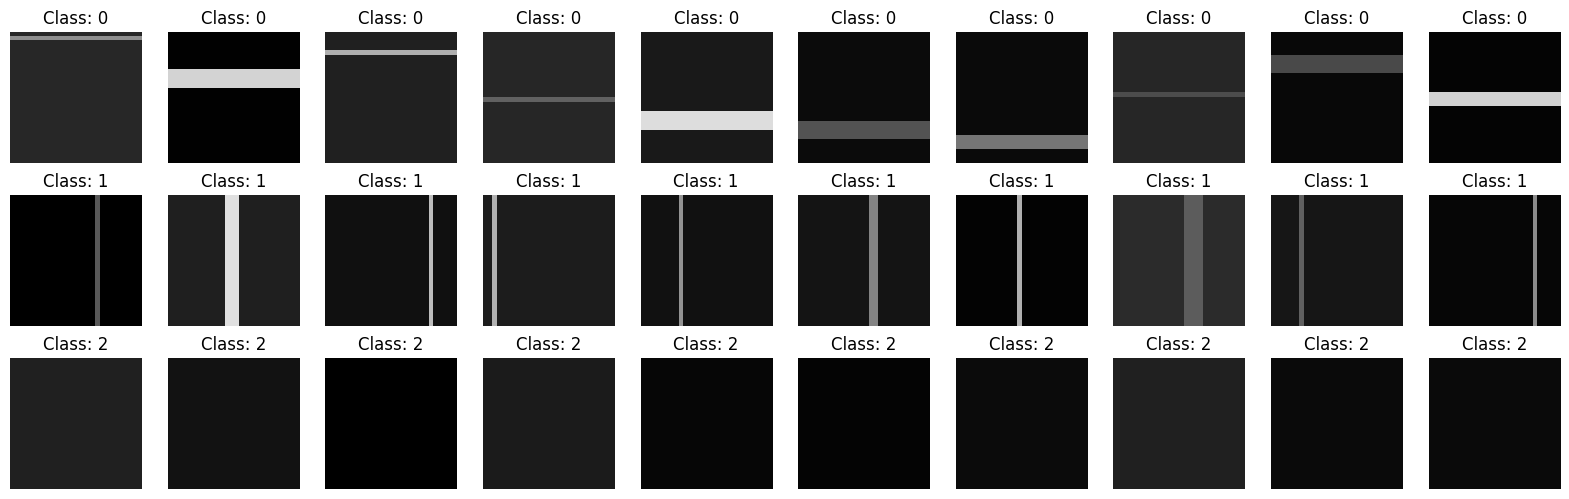

In [ ]:
seed = 10
set_seed(seed)

%matplotlib inline
plt.rcParams['figure.figsize'] = (10.0, 8.0) # set default size of plots
plt.rcParams['image.interpolation'] = 'nearest'
plt.rcParams['image.cmap'] = 'gray'

# for auto-reloading external modules
# see http://stackoverflow.com/questions/1907993/autoreload-of-modules-in-ipython
%load_ext autoreload
%autoreload 2
set_seed(seed)

visualize_data_config = dict(
    data_per_class=10,
    num_classes=3,
    class_type=["horizontal", "vertical", "none"],
)

visualize_dataset = EdgeDetectionDataset(visualize_data_config, mode='train', transform=None)
vis_dataset(visualize_dataset, num_classes=3, num_show_per_class=10)
plt.show()

In [ ]:
set_seed(seed)

small_dataset_config = None
small_dataset = None
transforms = T.Compose([T.ToTensor()])

small_dataset_config = {"data_per_class": 10}

small_dataset = EdgeDetectionDataset(
    small_dataset_config,
    mode="train",
    transform=transforms
)


In [ ]:
small_dataset_loader = None
from torch.utils.data import DataLoader
small_dataset_loader = DataLoader(small_dataset, batch_size=32, shuffle=True)


CNN Model has 606 parameters
MLP Model has 39793 parameters


100%|██████████| 500/500 [00:10<00:00, 48.30it/s]


CNN Acc: 100.0, MLP Acc: 100.0


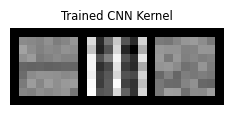

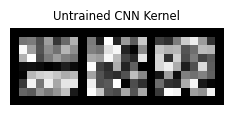

In [ ]:
set_seed(seed)

lr = 1e-2
num_epochs = 500
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

cnn_model = SimpleCNN(kernel_size=7)
cnn_model.to(device)
untrained_cnn_model = deepcopy(cnn_model)

mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
mlp_model.to(device)

mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

criterion = nn.CrossEntropyLoss()
print("CNN Model has {} parameters".format(count_parameters(cnn_model, only_trainable=True)))
print("MLP Model has {} parameters".format(count_parameters(mlp_model, only_trainable=True)))

for epoch in tqdm(range(num_epochs)):
    train_one_epoch(cnn_model, cnn_optimizer, criterion, small_dataset_loader, device, epoch, verbose=False)
    train_one_epoch(mlp_model, mlp_optimizer, criterion, small_dataset_loader, device, epoch, verbose=False)

_, cnn_acc, _ = evaluate(cnn_model, criterion, small_dataset_loader, device, verbose=False)
_, mlp_acc, _ = evaluate(mlp_model, criterion, small_dataset_loader, device, verbose=False)

print("CNN Acc: {}, MLP Acc: {}".format(cnn_acc, mlp_acc))
cnn_kernel = cnn_model.conv1.weight.data.clone().cpu()
untrained_kernel = untrained_cnn_model.conv1.weight.data.clone().cpu()

vis_kernel(cnn_kernel, ch=0, allkernels=False, title='Trained CNN Kernel')
vis_kernel(untrained_kernel, ch=0, allkernels=False, title='Untrained CNN Kernel')


PART 2:

In [ ]:
set_seed(seed)

train_loader_dict = dict()
num_images_list = [10, 30, 50, 100]
transforms = T.Compose([T.ToTensor()])
train_batch_size = 10
valid_batch_size = 256
def set_seed(seed):
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    random.seed(seed)
    torch.backends.cudnn.deterministic = True
    torch.backends.cudnn.benchmark = False

set_seed(seed)

train_loader_dict = dict()
num_images_list = [10, 30, 50, 100]

base_config = deepcopy(domain_config)

for num_images in num_images_list:
    config = deepcopy(base_config)
    config["data_per_class"] = num_images
    train_dataset = EdgeDetectionDataset(config, mode="train", transform=transforms)
    train_loader = DataLoader(train_dataset, batch_size=train_batch_size, shuffle=True)
    train_loader_dict[num_images] = train_loader

valid_config = deepcopy(base_config)
valid_config["data_per_class"] = 50
valid_dataset = EdgeDetectionDataset(valid_config, mode="valid", transform=transforms)
valid_loader = DataLoader(valid_dataset, batch_size=valid_batch_size, shuffle=False)


In [ ]:
lr = 1e-2
num_epochs = 30
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_acc_list = list()
mlp_acc_list = list()

cnn_kernel_dict = dict()
untrained_cnn_kernel_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=7)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
    mlp_model.to(device)

    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    for epoch in tqdm(range(num_epochs)):
        train_one_epoch(cnn_model, cnn_optimizer, criterion, train_loader, device, epoch, verbose=False)
        train_one_epoch(mlp_model, mlp_optimizer, criterion, train_loader, device, epoch, verbose=False)

    cnn_kernel_dict[num_image] = deepcopy(cnn_model.conv1.weight.cpu().detach())
    untrained_cnn_kernel_dict[num_image] = deepcopy(untrained_cnn_model.conv1.weight.cpu().detach())

    _, cnn_valid_acc, _ = evaluate(cnn_model, criterion, valid_loader, device, verbose=False)
    _, mlp_valid_acc, _ = evaluate(mlp_model, criterion, valid_loader, device, verbose=False)

    print("CNN Acc: {}, MLP Acc: {}".format(cnn_valid_acc, mlp_valid_acc))
    cnn_acc_list.append(cnn_valid_acc)
    mlp_acc_list.append(mlp_valid_acc)

Training with 10 images


100%|██████████| 30/30 [00:02<00:00, 12.65it/s]


CNN Acc: 47.333333333333336, MLP Acc: 48.0
Training with 30 images


100%|██████████| 30/30 [00:02<00:00, 12.70it/s]


CNN Acc: 86.66666666666667, MLP Acc: 74.0
Training with 50 images


100%|██████████| 30/30 [00:03<00:00,  7.59it/s]


CNN Acc: 94.66666666666667, MLP Acc: 92.0
Training with 100 images


100%|██████████| 30/30 [00:07<00:00,  3.77it/s]

CNN Acc: 98.66666666666667, MLP Acc: 92.0


<Figure size 1000x800 with 0 Axes>

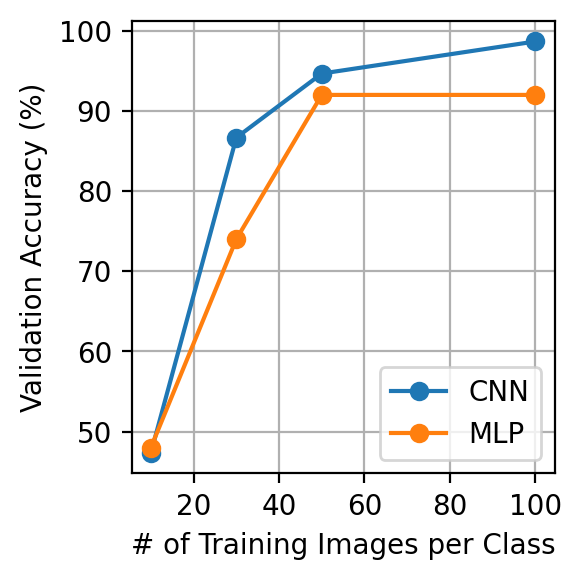

In [ ]:
## Plot the validation accuracy
plt.clf()
fig, ax = plt.subplots(1, 1, figsize=(3, 3), dpi=200)
ax.plot(num_images_list, cnn_acc_list, marker='o', label='CNN')
ax.plot(num_images_list, mlp_acc_list, marker='o', label='MLP')
ax.set_xlabel('# of Training Images per Class')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()

Training with 10 images: 100%|██████████| 30/30 [00:01<00:00, 17.42it/s]



Validation Accuracies with 10 images/class:
→ CNN w/ Sobel Init:  64.00%
→ CNN w/ Random Init: 30.00%
→ MLP:                41.33%


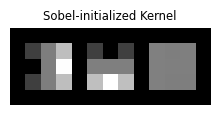

In [ ]:
def initialize_cnn_with_sobel(cnn_model):
    sobel_x = torch.tensor([
        [[[-1, 0, 1],
          [-2, 0, 2],
          [-1, 0, 1]]]
    ], dtype=torch.float32)

    sobel_y = torch.tensor([
        [[[-1, -2, -1],
          [ 0,  0,  0],
          [ 1,  2,  1]]]
    ], dtype=torch.float32)

    with torch.no_grad():
        cnn_model.conv1.weight.zero_()
        cnn_model.conv1.weight[0] = sobel_x
        cnn_model.conv1.weight[1] = sobel_y
        for i in range(2, cnn_model.conv1.weight.shape[0]):
            cnn_model.conv1.weight[i] = 0.01 * torch.randn_like(cnn_model.conv1.weight[i])
sobel_cnn_acc_list = []

num_images = 10
train_loader = train_loader_dict[num_images]

set_seed(seed)

# CNN with Sobel initialization
sobel_cnn_model = SimpleCNN(kernel_size=3)
initialize_cnn_with_sobel(sobel_cnn_model)
sobel_cnn_model.to(device)
sobel_cnn_optimizer = optim.SGD(sobel_cnn_model.parameters(), lr=lr, momentum=0.9)

# CNN with random initialization
rand_cnn_model = SimpleCNN(kernel_size=3)
rand_cnn_model.to(device)
rand_cnn_optimizer = optim.SGD(rand_cnn_model.parameters(), lr=lr, momentum=0.9)

# MLP
mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
mlp_model.to(device)
mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)

# Train
for epoch in tqdm(range(num_epochs), desc=f"Training with {num_images} images"):
    train_one_epoch(sobel_cnn_model, sobel_cnn_optimizer, criterion, train_loader, device, epoch, verbose=False)
    train_one_epoch(rand_cnn_model, rand_cnn_optimizer, criterion, train_loader, device, epoch, verbose=False)
    train_one_epoch(mlp_model, mlp_optimizer, criterion, train_loader, device, epoch, verbose=False)

# Evaluate all three
_, sobel_acc, _ = evaluate(sobel_cnn_model, criterion, valid_loader, device, verbose=False)
_, rand_acc, _ = evaluate(rand_cnn_model, criterion, valid_loader, device, verbose=False)
_, mlp_acc, _ = evaluate(mlp_model, criterion, valid_loader, device, verbose=False)

print("\nValidation Accuracies with 10 images/class:")
print(f"→ CNN w/ Sobel Init:  {sobel_acc:.2f}%")
print(f"→ CNN w/ Random Init: {rand_acc:.2f}%")
print(f"→ MLP:                {mlp_acc:.2f}%")
vis_kernel(sobel_cnn_model.conv1.weight.cpu().detach(), ch=0, allkernels=False, title='Sobel-initialized Kernel')
plt.show()


In [ ]:
lr = 1e-2
num_epochs = 30
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

edge_init_cnn_acc_list = list()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    cnn_model = SimpleCNN(kernel_size=7)
    init_conv_kernel_with_edge_detector(cnn_model)
    freeze_conv_layer(cnn_model)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    edge_init_cnn_valid_acc_list = []
    for epoch in tqdm(range(num_epochs)):
        cnn_train_loss, cnn_train_acc = train_one_epoch(cnn_model, cnn_optimizer, criterion, train_loader, device, epoch, verbose=False)

    _, cnn_valid_acc, _ = evaluate(cnn_model, criterion, valid_loader, device, verbose=False)
    print("CNN Acc: {}".format(cnn_valid_acc))
    edge_init_cnn_acc_list.append(cnn_valid_acc)


Training with 10 images


100%|██████████| 30/30 [00:00<00:00, 100.24it/s]


CNN Acc: 96.0
Training with 30 images


100%|██████████| 30/30 [00:00<00:00, 38.12it/s]


CNN Acc: 96.0
Training with 50 images


100%|██████████| 30/30 [00:01<00:00, 22.36it/s]


CNN Acc: 96.0
Training with 100 images


100%|██████████| 30/30 [00:02<00:00, 10.64it/s]

CNN Acc: 96.0


<Figure size 1000x800 with 0 Axes>

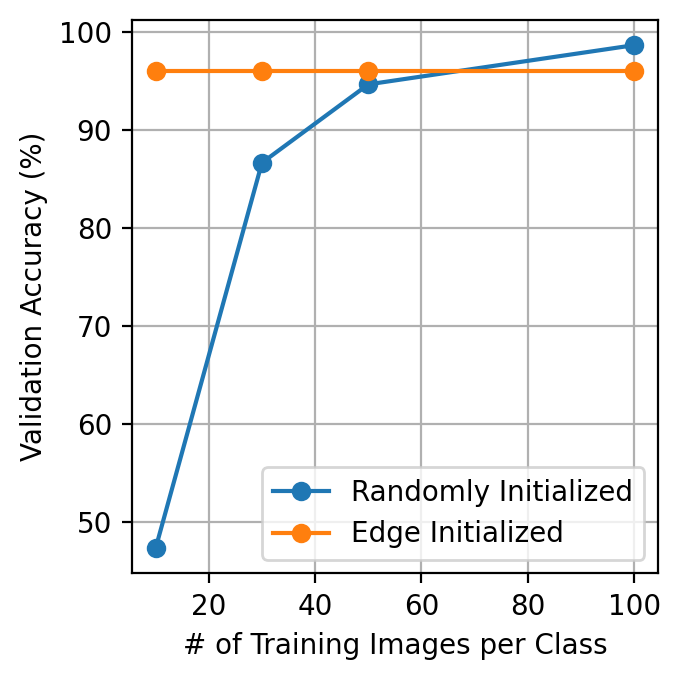

In [ ]:
## Plot the validation accuracy
plt.clf()
fig, ax = plt.subplots(1, 1, figsize=(3.5, 3.5), dpi=200)
plt.plot(num_images_list, cnn_acc_list, marker='o', label='Randomly Initialized')
plt.plot(num_images_list, edge_init_cnn_acc_list, marker='o', label='Edge Initialized')
ax.set_xlabel('# of Training Images per Class')
ax.set_ylabel('Validation Accuracy (%)')
ax.legend()
ax.grid()
plt.tight_layout()
plt.show()


PART 3

Training with 10 images


100%|██████████| 30/30 [00:01<00:00, 17.05it/s]


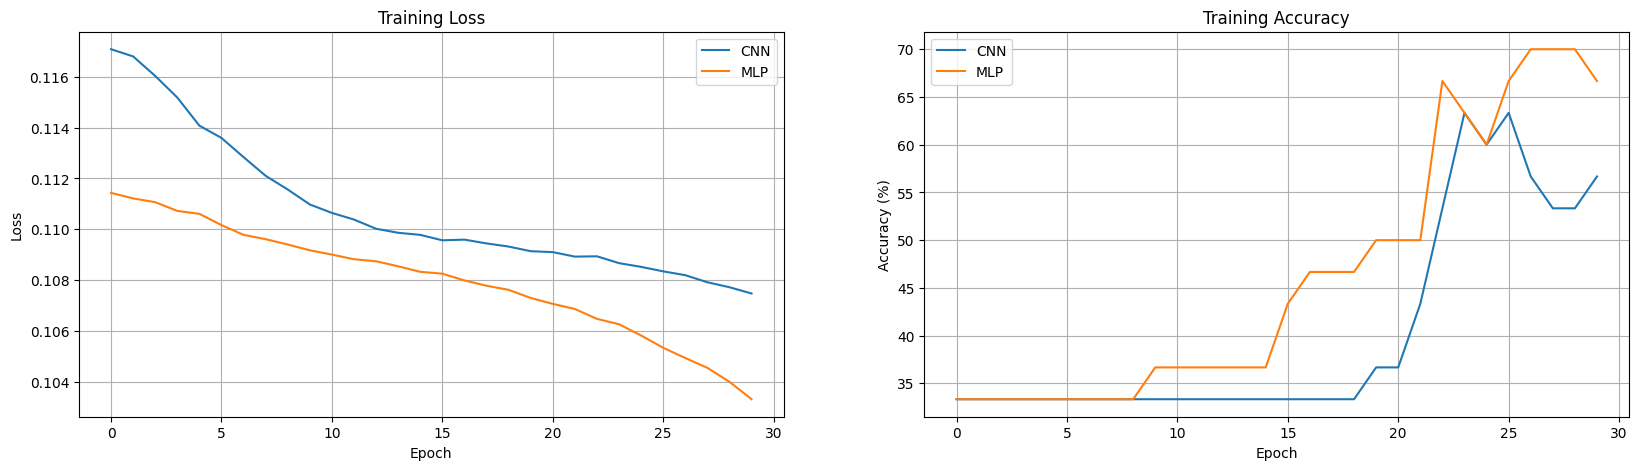

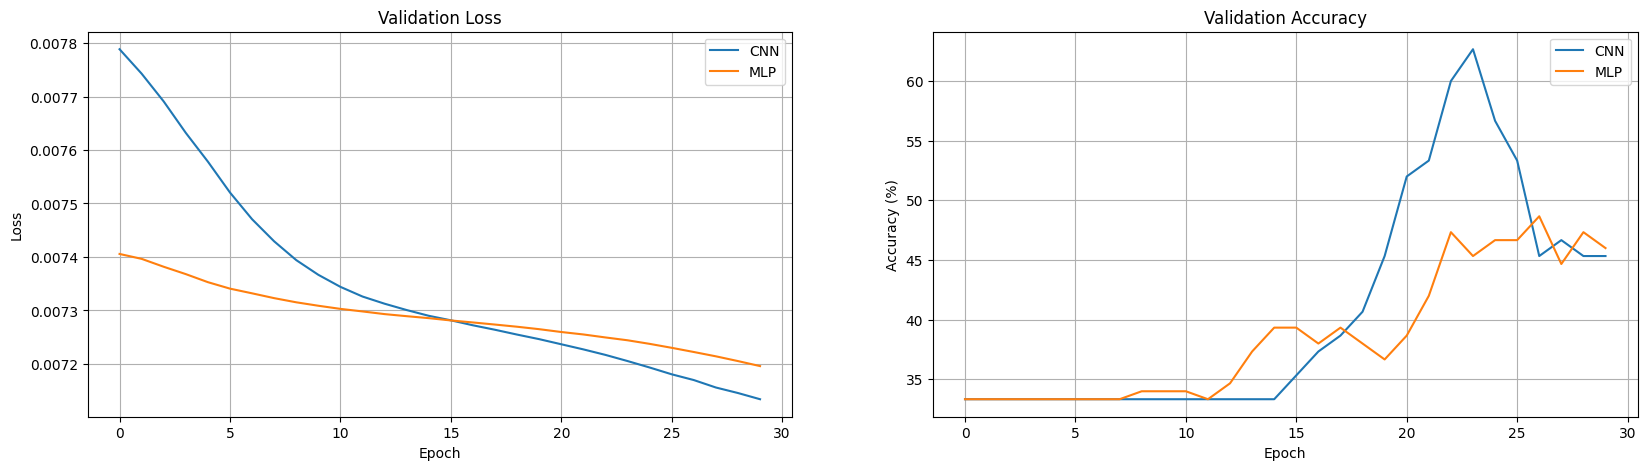

CNN Acc: 45.333333333333336, MLP Acc: 46.0
Training with 30 images


100%|██████████| 30/30 [00:03<00:00,  9.41it/s]


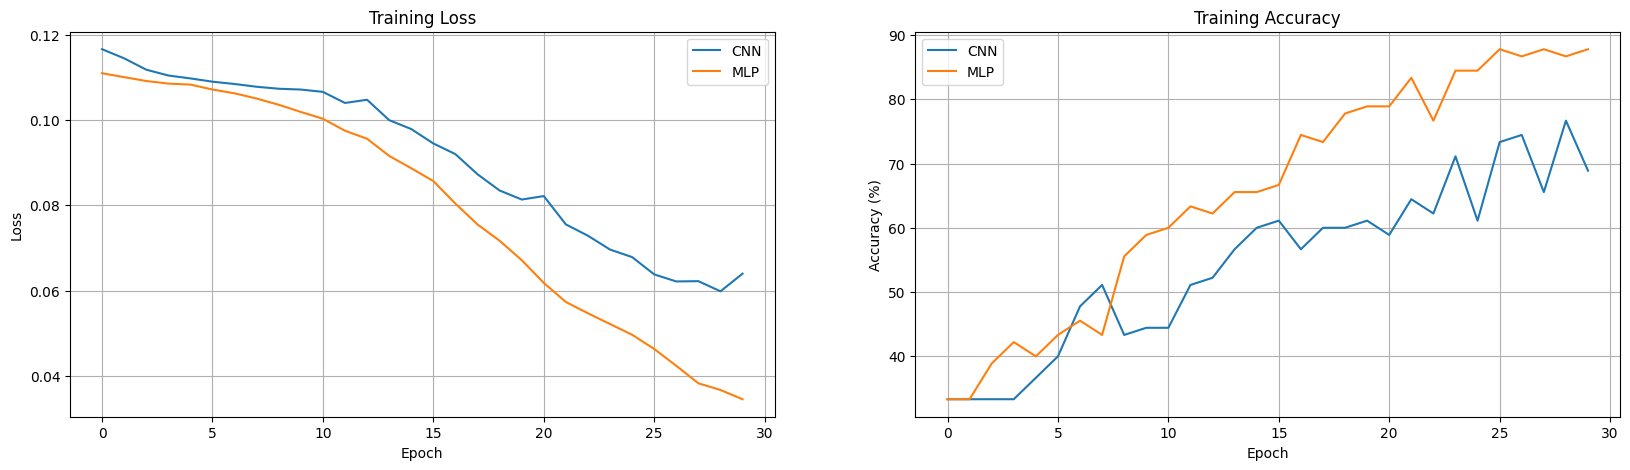

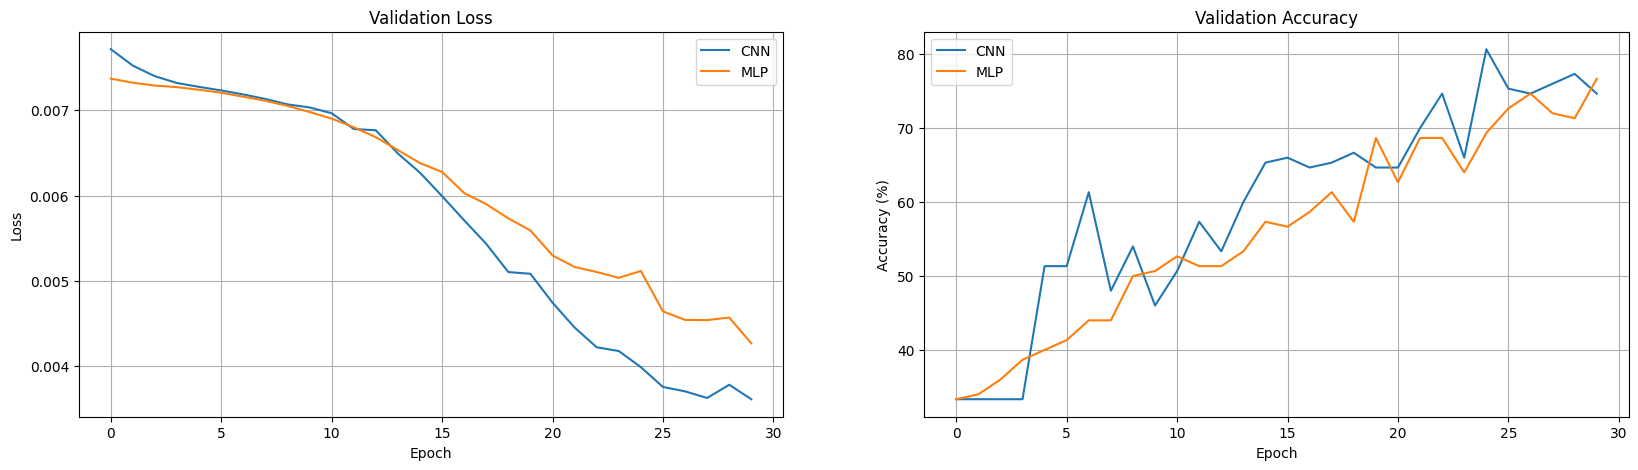

CNN Acc: 74.66666666666667, MLP Acc: 76.66666666666667
Training with 50 images


100%|██████████| 30/30 [00:03<00:00,  7.90it/s]


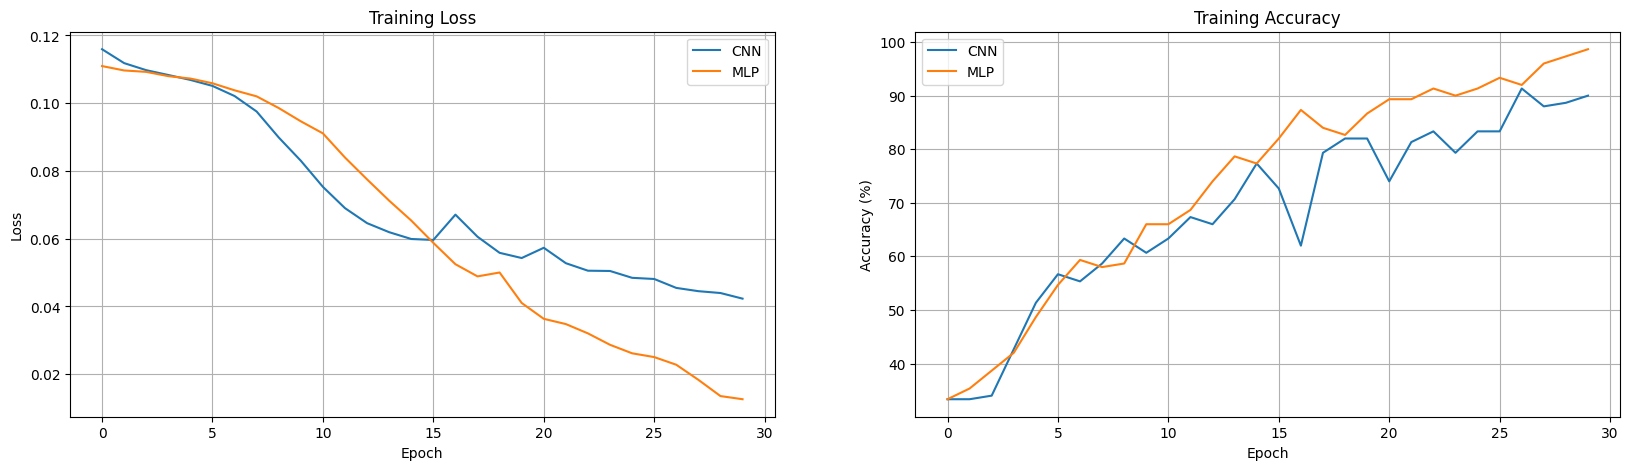

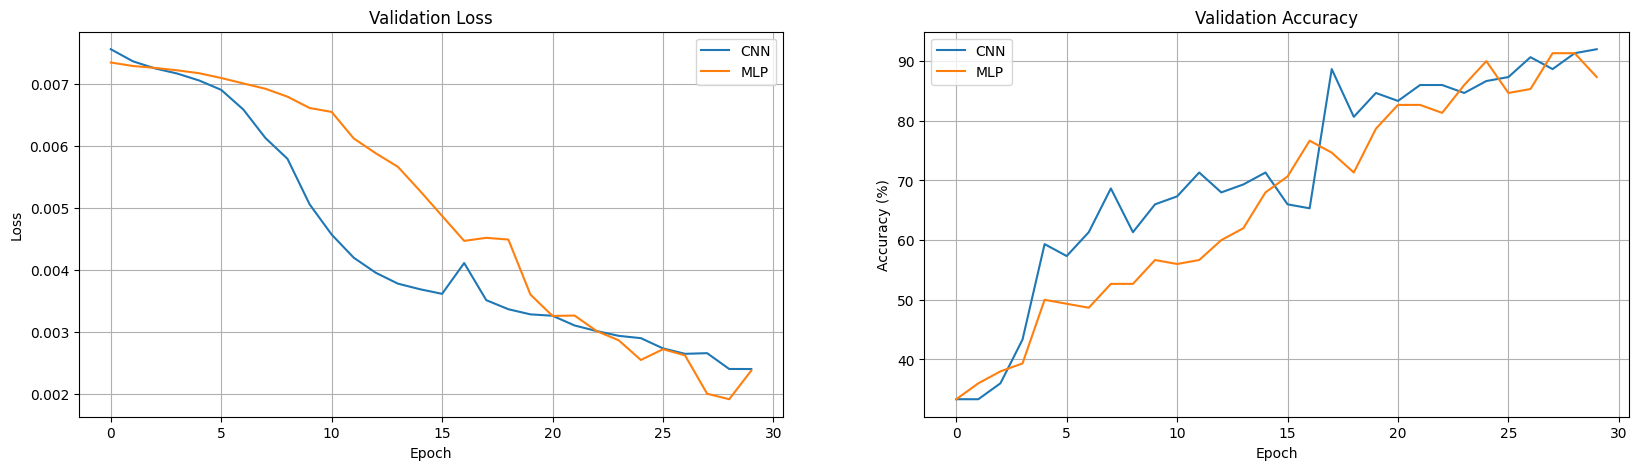

CNN Acc: 92.0, MLP Acc: 87.33333333333333
Training with 100 images


100%|██████████| 30/30 [00:06<00:00,  4.49it/s]


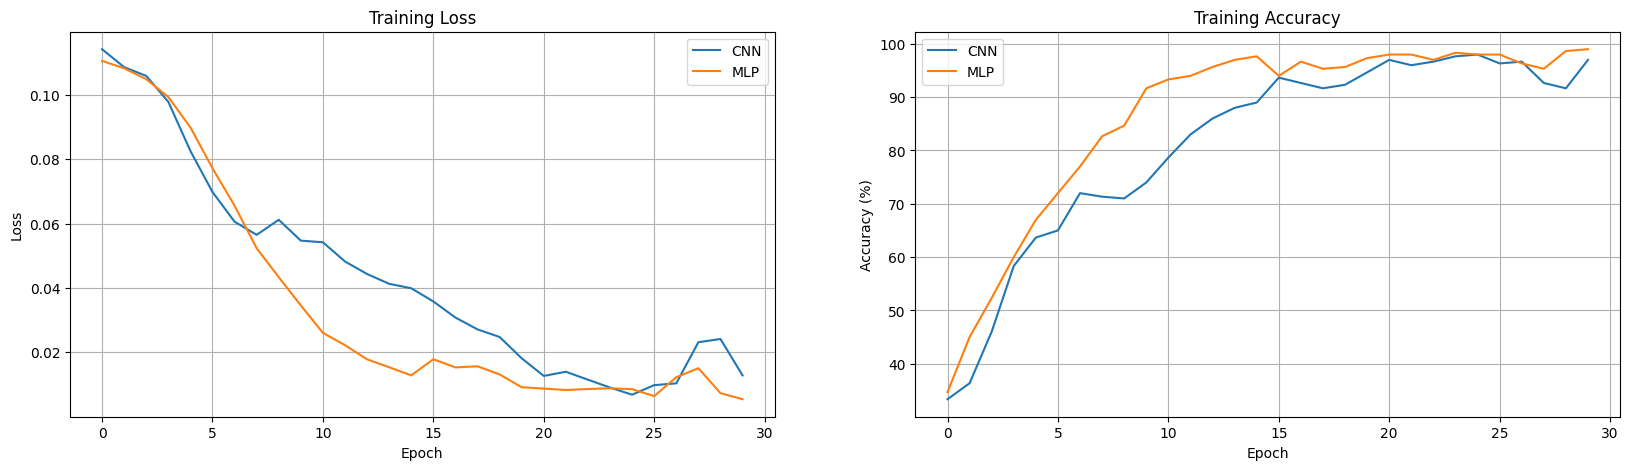

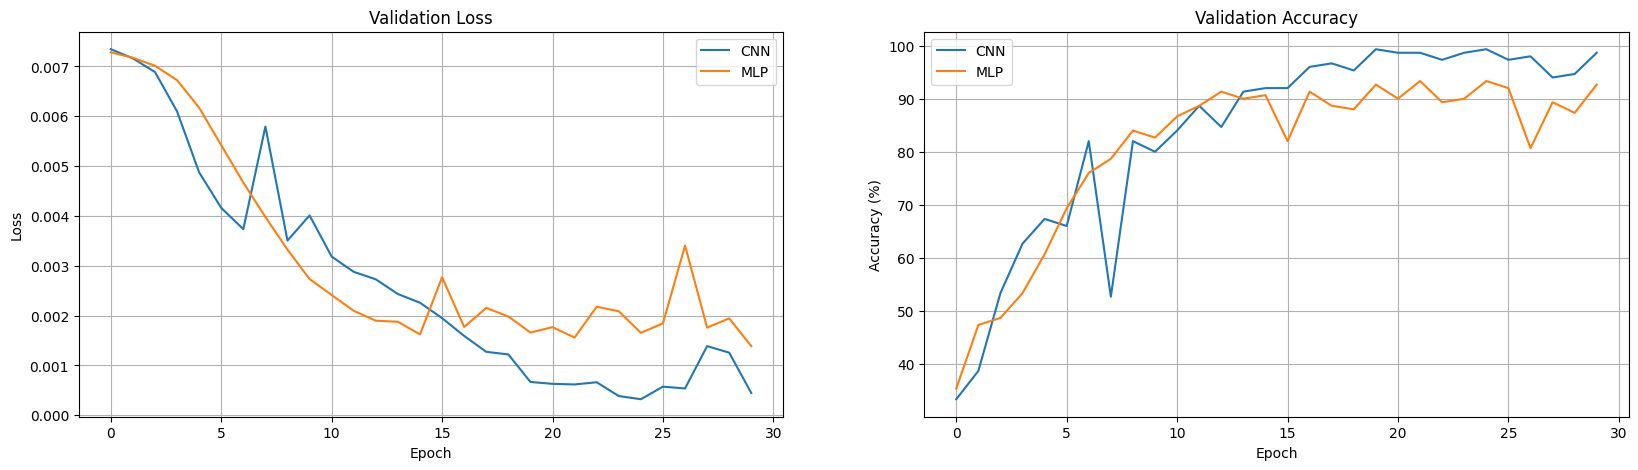

CNN Acc: 98.66666666666667, MLP Acc: 92.66666666666667


In [ ]:
def train_model(model, optimizer, num_epochs, train_loader, valid_loader):
    criterion=nn.CrossEntropyLoss()
    untrained_model = deepcopy(model)
    train_acc_list, valid_acc_list, train_loss_list, valid_loss_list = [], [], [] ,[]
    for epoch in tqdm(range(num_epochs)):
        train_loss, train_acc = train_one_epoch(model, optimizer, criterion, train_loader, device, epoch, verbose=False)
        valid_loss, valid_acc, confusion_matrix = evaluate(model, criterion, valid_loader, device, verbose=False)
        train_acc_list.append(train_acc)
        valid_acc_list.append(valid_acc)
        train_loss_list.append(train_loss)
        valid_loss_list.append(valid_loss)

    return {"final_valid_acc": valid_acc_list[-1], "train_acc": train_acc_list, "valid_acc": valid_acc_list,
            "train_loss": train_loss_list, "valid_loss": valid_loss_list,
            "confusion_matrix": confusion_matrix}


lr = 1e-2
num_epochs = 30
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_acc_list = list()
mlp_acc_list = list()

cnn_kernel_dict = dict()
untrained_cnn_kernel_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=7)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
    mlp_model.to(device)

    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    mlp_results = train_model(mlp_model, mlp_optimizer, num_epochs, train_loader, valid_loader)
    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], mlp_results["train_loss"], mlp_results["train_acc"])
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], mlp_results["valid_loss"], mlp_results["valid_acc"])

    print("CNN Acc: {}, MLP Acc: {}".format(cnn_results["final_valid_acc"], mlp_results["final_valid_acc"]))

In [ ]:
lr = 1e-2
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

# Sweep more sizes to get a better answer
num_images_list = [10, 30, 50, 70, 100, 150, 200]
cnn_acc_list = []
mlp_acc_list = []

for num_image in num_images_list:
    print(f"\nTraining with {num_image} images per class")

    domain_config["data_per_class"] = num_image
    train_dataset = EdgeDetectionDataset(domain_config, mode="train", transform=transforms)
    train_loader = DataLoader(train_dataset, batch_size=10, shuffle=True)

    set_seed(seed)

    cnn_model = SimpleCNN(kernel_size=7).to(device)
    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10]).to(device)

    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)
    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)

    num_epochs = 100  # Train longer to ensure convergence
    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)
    mlp_results = train_model(mlp_model, mlp_optimizer, num_epochs, train_loader, valid_loader)

    print(f"Final CNN Accuracy: {cnn_results['final_valid_acc']:.2f}%")
    print(f"Final MLP Accuracy: {mlp_results['final_valid_acc']:.2f}%")

    cnn_acc_list.append(cnn_results['final_valid_acc'])
    mlp_acc_list.append(mlp_results['final_valid_acc'])



Training with 10 images per class


100%|██████████| 100/100 [00:02<00:00, 37.82it/s]


Final CNN Accuracy: 88.00%
Final MLP Accuracy: 57.33%

Training with 30 images per class


100%|██████████| 100/100 [00:04<00:00, 24.63it/s]


Final CNN Accuracy: 96.00%
Final MLP Accuracy: 77.33%

Training with 50 images per class


...

Final CNN Accuracy: 99.33%
Final MLP Accuracy: 98.00%

Training with 150 images per class


100%|██████████| 100/100 [00:22<00:00,  4.39it/s]


Final CNN Accuracy: 99.33%
Final MLP Accuracy: 96.67%

Training with 200 images per class


  0%|          | 0/100 [00:00<?, ?it/s]Exception ignored in: <generator object tqdm.__iter__ at 0x7e10a19ce770>
Traceback (most recent call last):
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1196, in __iter__
    self.close()
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1302, in close
    self.display(pos=0)
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 1495, in display
    self.sp(self.__str__() if msg is None else msg)
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 459, in print_status
    fp_write('\r' + s + (' ' * max(last_len[0] - len_s, 0)))
  File "/usr/local/lib/python3.11/dist-packages/tqdm/std.py", line 453, in fp_write
    fp_flush()
  File "/usr/local/lib/python3.11/dist-packages/tqdm/utils.py", line 196, in inner
    return func(*args, **kwargs)
           ^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/python3.11/dist-packages/ipykernel/iostream.py", line 488, in flush
    if not evt.wait(s

KeyboardInterrupt: 

PART 4

In [ ]:
set_seed(seed)
train_loader_dict = dict()
num_train_images_list = [10, 30, 50, 100]
possible_edge_location_ratio = 0.5
valid_loader = None

transforms = T.Compose([T.ToTensor()])
batch_size = 10

for num_image in num_train_images_list:
    train_dataset_config = dict(
        data_per_class=num_image,
        possible_edge_location_ratio=possible_edge_location_ratio,
    )
    train_dataset = EdgeDetectionDataset(train_dataset_config, 'train', transform=transforms)
    train_loader_dict[num_image] = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

valid_dataset_config = dict(
    data_per_class=50,
    possible_edge_location_ratio=possible_edge_location_ratio,
)
valid_dataset = EdgeDetectionDataset(valid_dataset_config, 'valid', transform=transforms)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


Training with 10 images


100%|██████████| 300/300 [00:20<00:00, 14.62it/s]


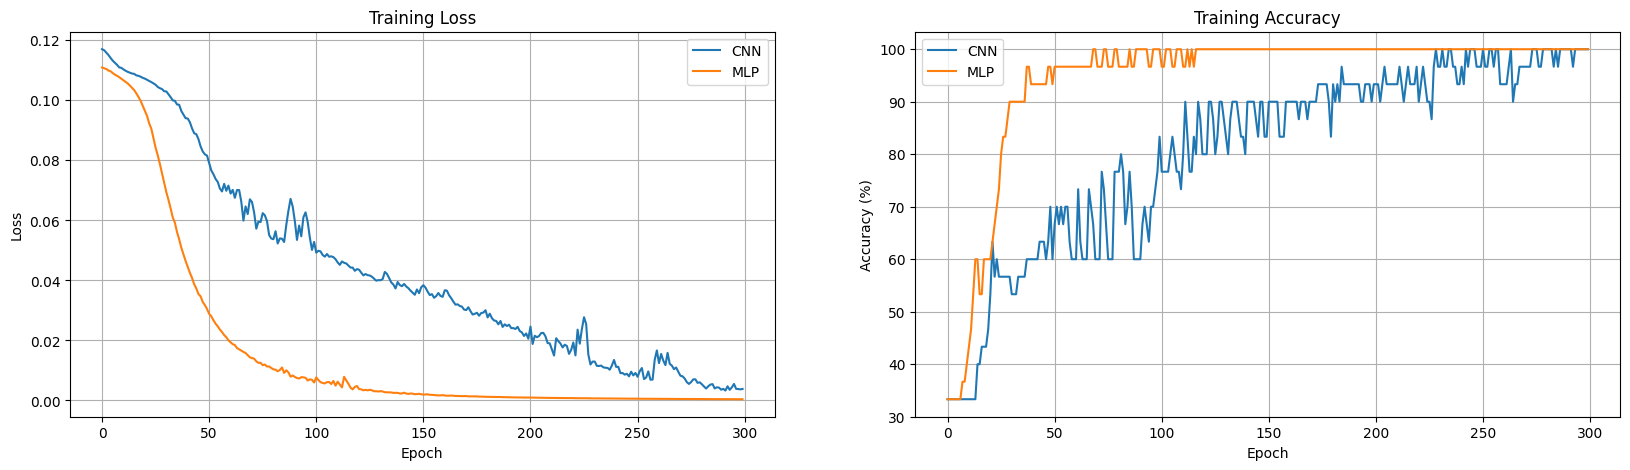

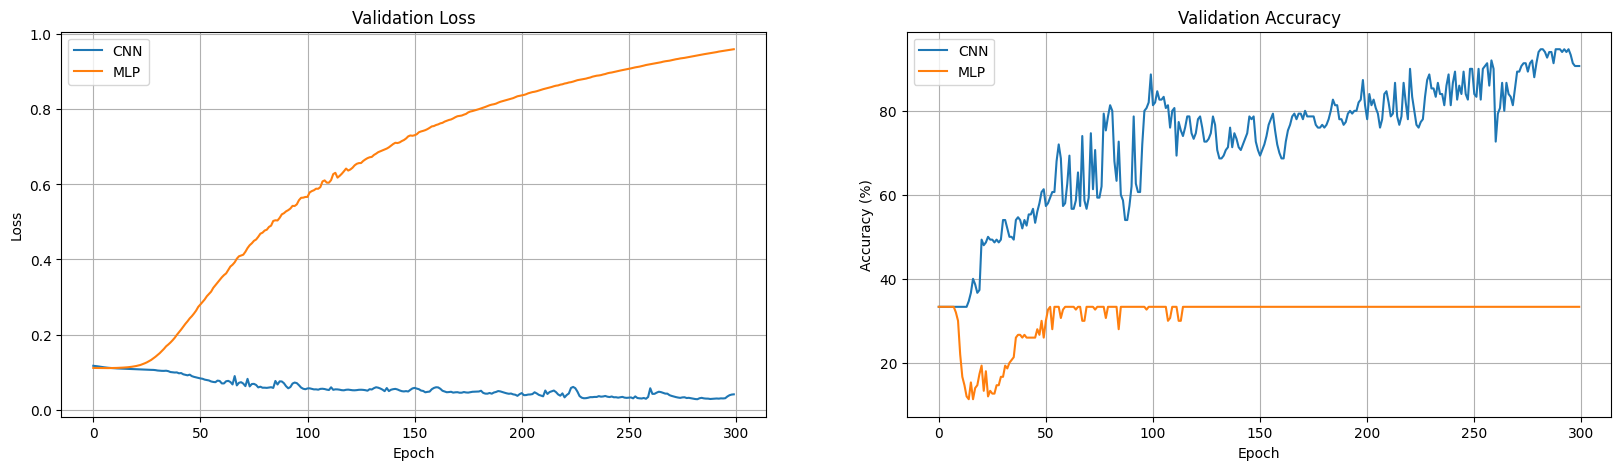

CNN Acc: 90.66666666666667, MLP Acc: 33.333333333333336
Training with 30 images


100%|██████████| 300/300 [00:32<00:00,  9.37it/s]


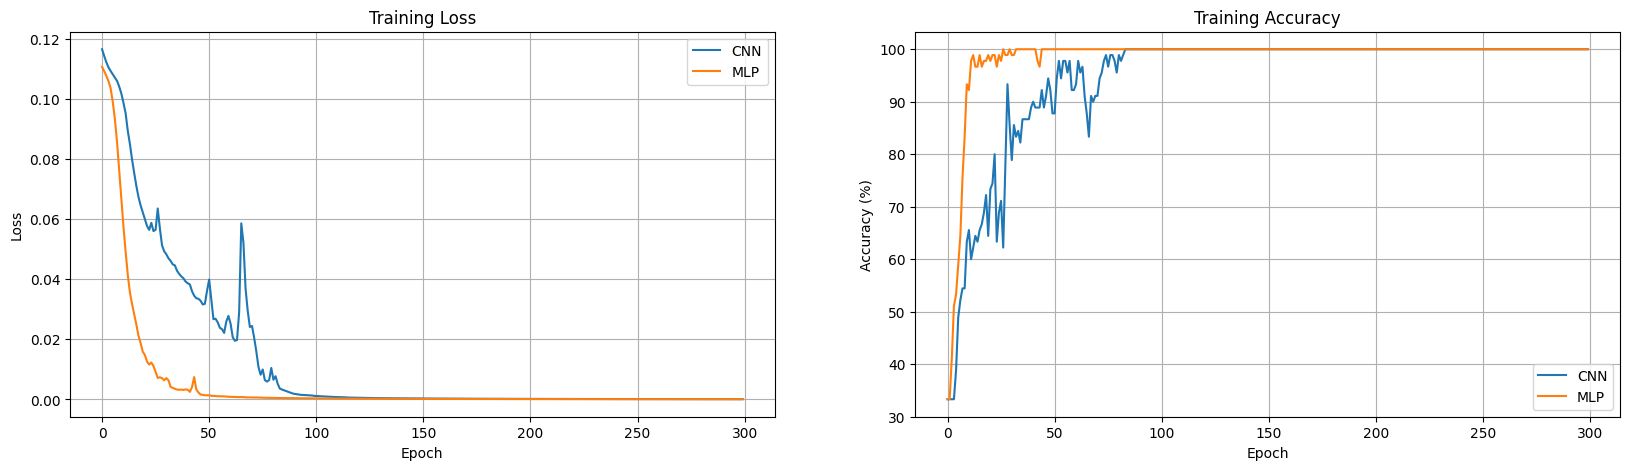

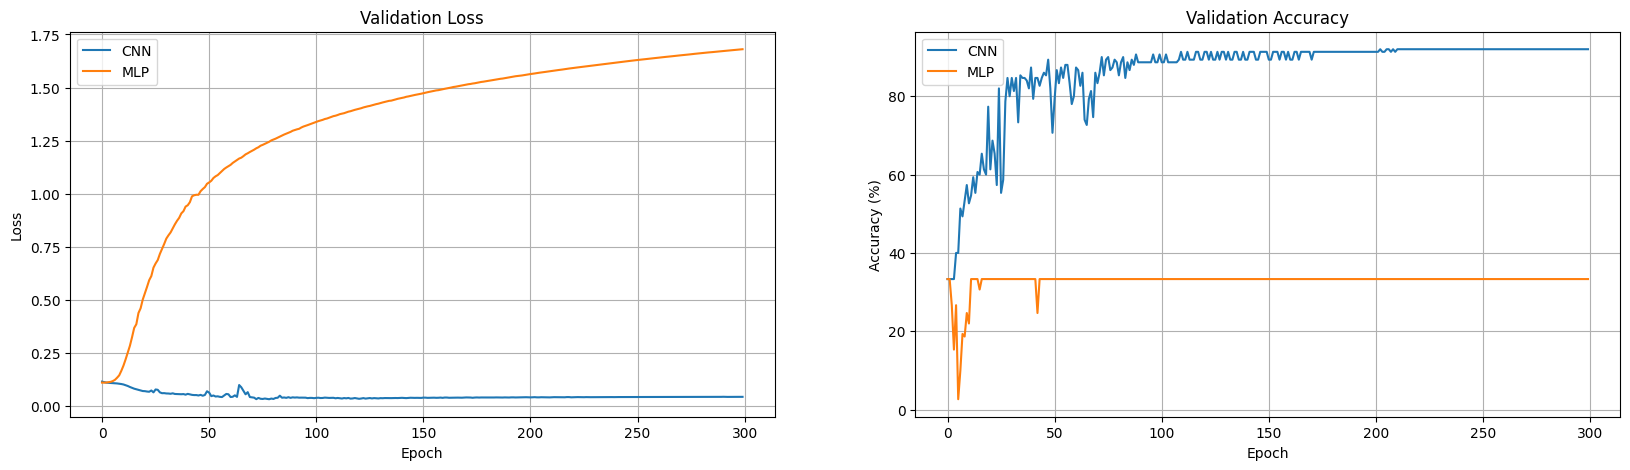

CNN Acc: 92.0, MLP Acc: 33.333333333333336
Training with 50 images


100%|██████████| 300/300 [00:43<00:00,  6.91it/s]


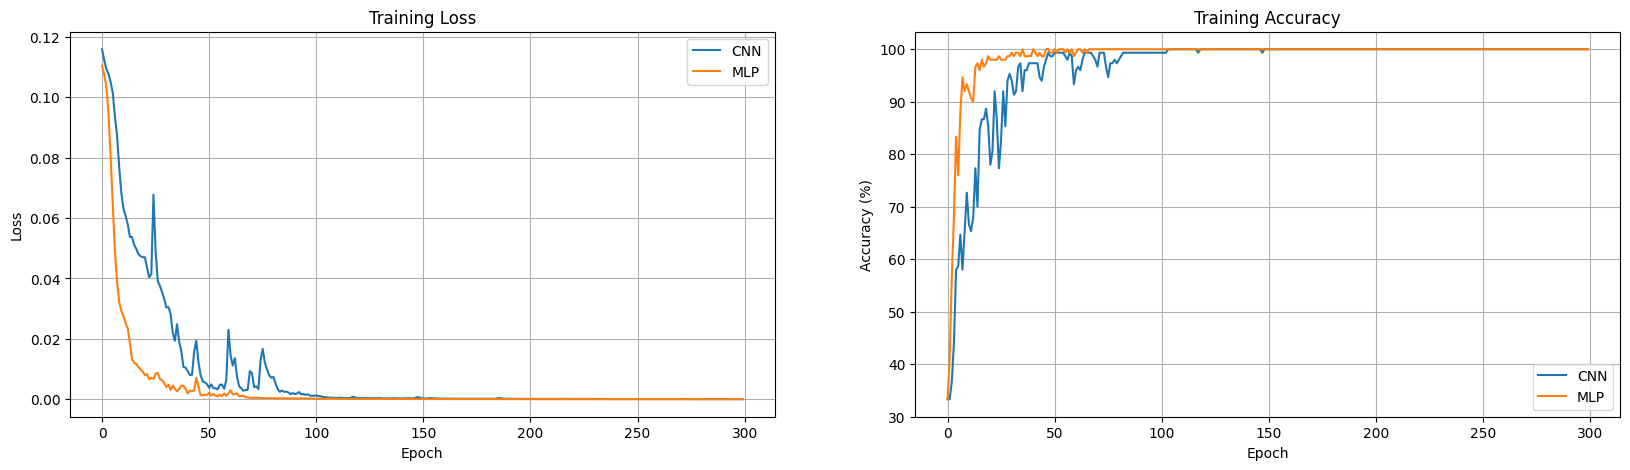

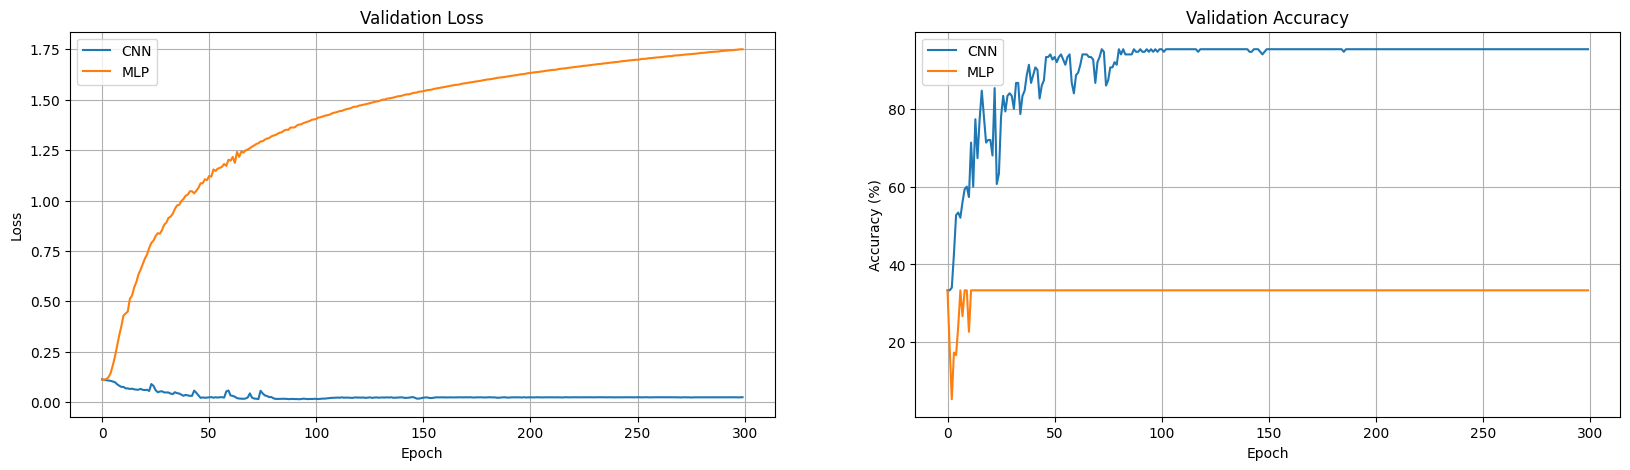

CNN Acc: 95.33333333333333, MLP Acc: 33.333333333333336
Training with 100 images


100%|██████████| 300/300 [01:13<00:00,  4.09it/s]


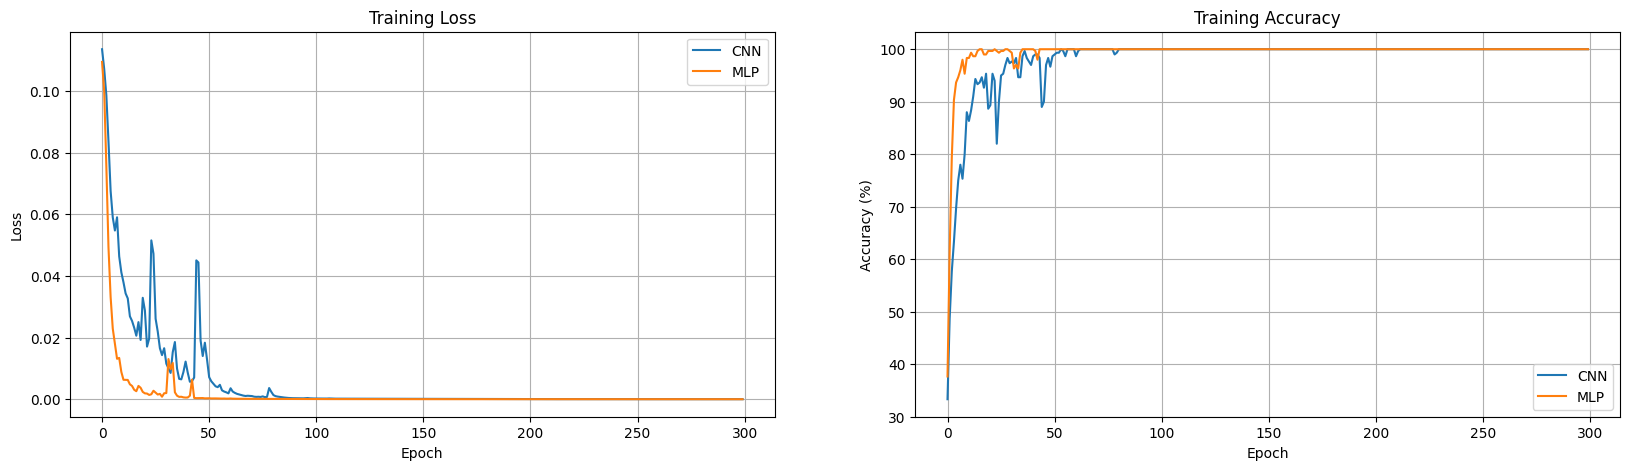

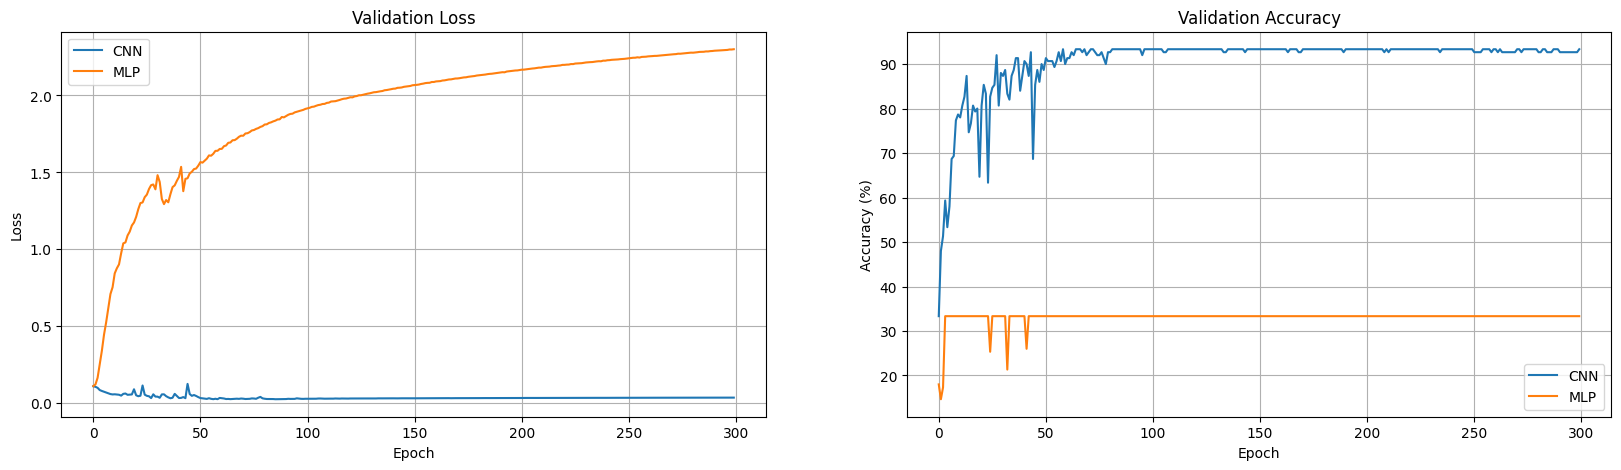

CNN Acc: 93.33333333333333, MLP Acc: 33.333333333333336


In [ ]:
lr = 1e-2
num_epochs = 300
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_acc_list = list()
mlp_acc_list = list()

cnn_kernel_dict = dict()
untrained_cnn_kernel_dict = dict()

cnn_confusion_matrix_dict = dict()
mlp_confusion_matrix_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=7)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
    mlp_model.to(device)

    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    mlp_results = train_model(mlp_model, mlp_optimizer, num_epochs, train_loader, valid_loader)
    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], mlp_results["train_loss"], mlp_results["train_acc"])
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], mlp_results["valid_loss"], mlp_results["valid_acc"])

    cnn_kernel_dict[num_image] = deepcopy(cnn_model.conv1.weight.detach().cpu())
    untrained_cnn_kernel_dict[num_image] = deepcopy(untrained_cnn_model.conv1.weight.detach().cpu())

    cnn_confusion_matrix_dict[num_image] = cnn_results["confusion_matrix"]
    mlp_confusion_matrix_dict[num_image] = mlp_results["confusion_matrix"]

    print("CNN Acc: {}, MLP Acc: {}".format(cnn_results["final_valid_acc"], mlp_results["final_valid_acc"]))


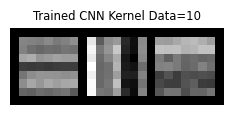

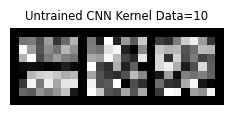

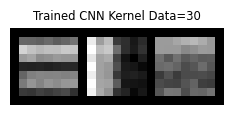

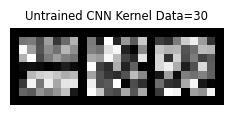

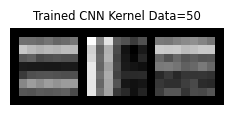

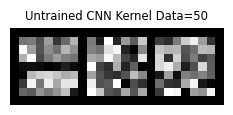

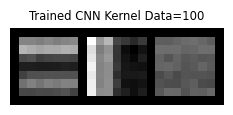

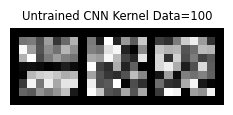

In [ ]:
for num_image, cnn_kernel in cnn_kernel_dict.items():
    untrained_kernel = untrained_cnn_kernel_dict[num_image]
    vis_kernel(cnn_kernel, ch=0, allkernels=False, title='Trained CNN Kernel Data={}'.format(num_image))
    vis_kernel(untrained_kernel, ch=0, allkernels=False, title='Untrained CNN Kernel Data={}'.format(num_image))
plt.show()

/tmp/ipython-input-2-243127193.py:790: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + class_names, rotation=90)
/tmp/ipython-input-2-243127193.py:791: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + class_names)
/tmp/ipython-input-2-243127193.py:790: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([""] + class_names, rotation=90)
/tmp/ipython-input-2-243127193.py:791: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_yticklabels([""] + class_names)
/tmp/ipython-input-2-243127193.py:790: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() 

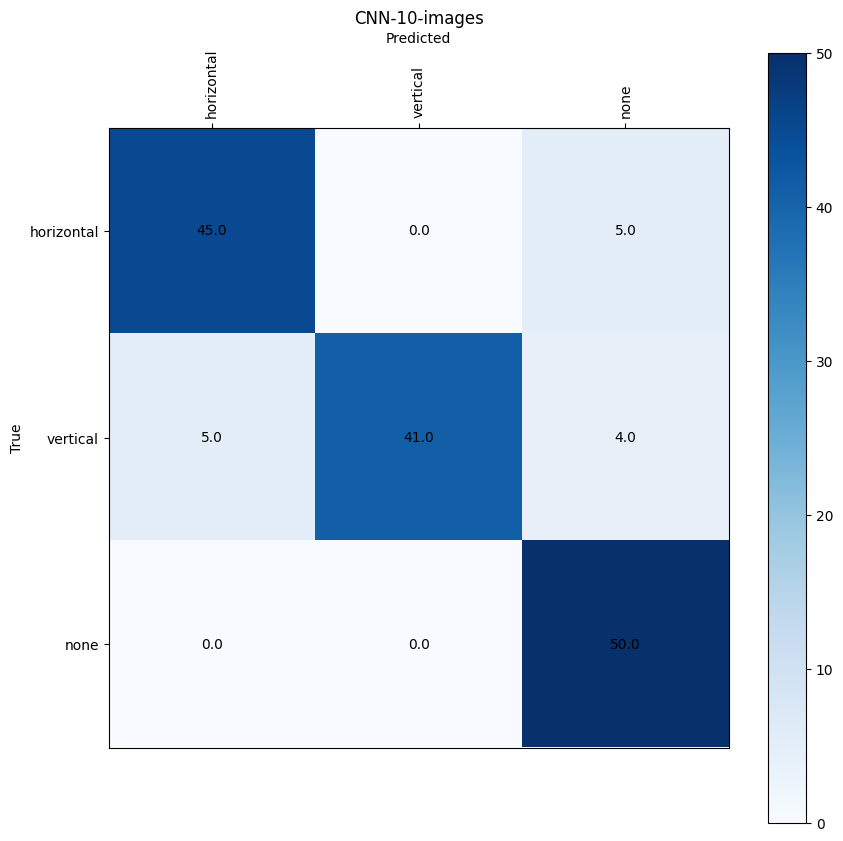

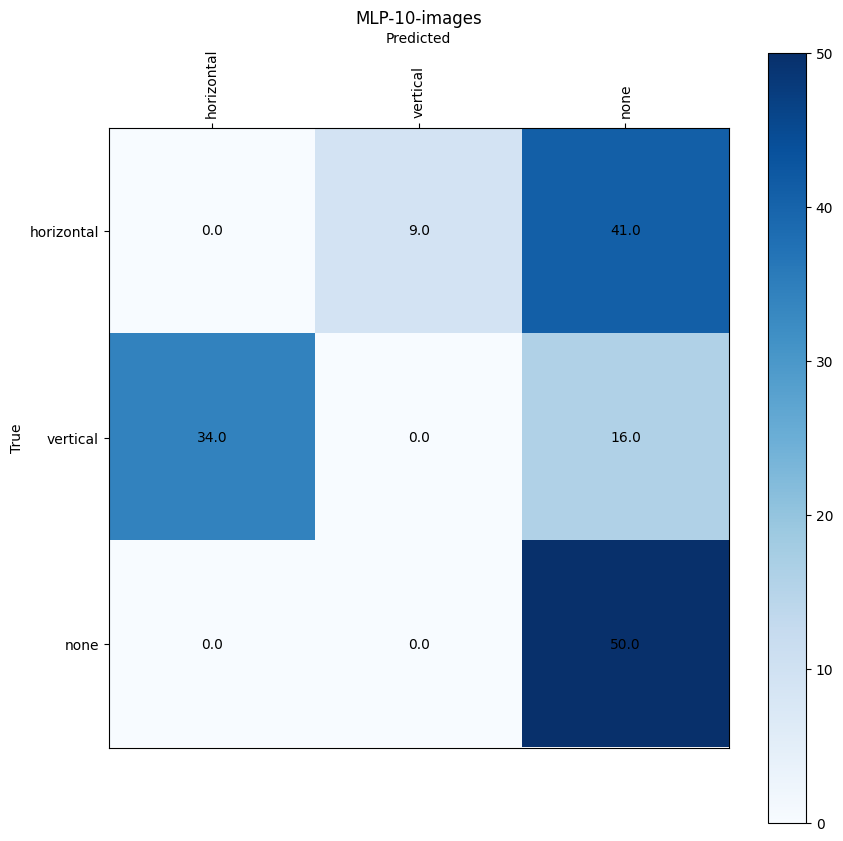

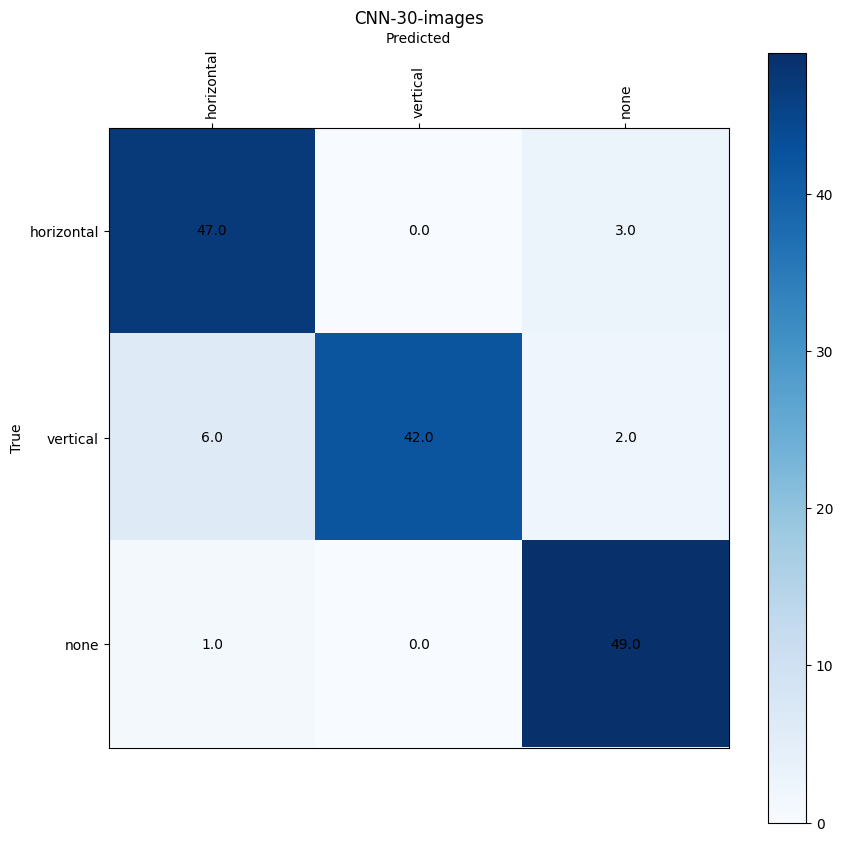

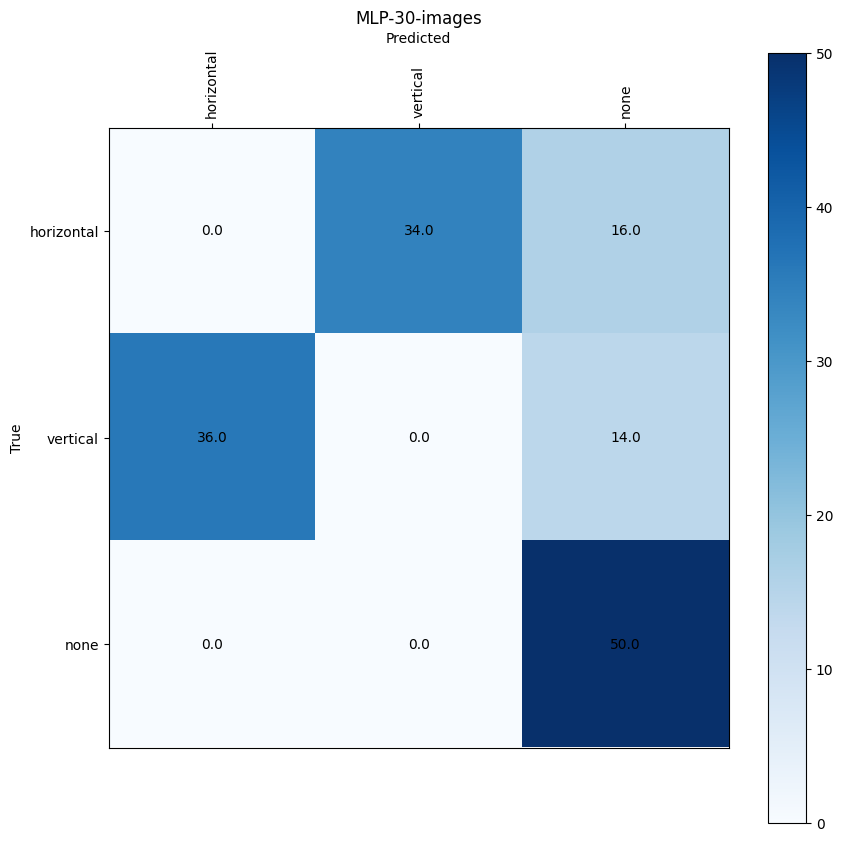

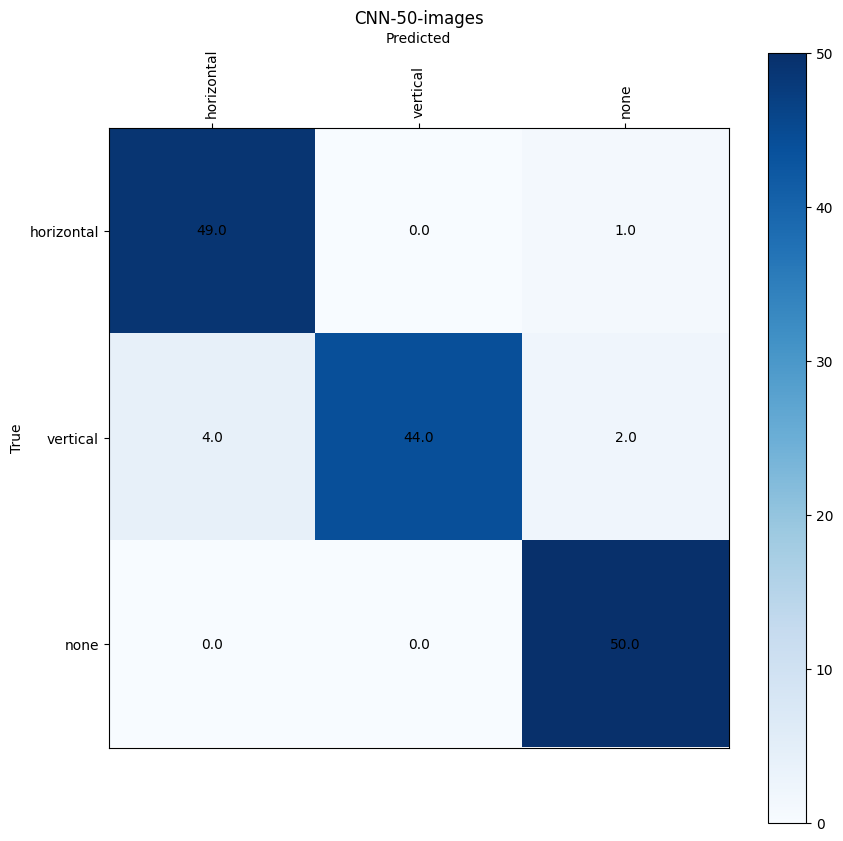

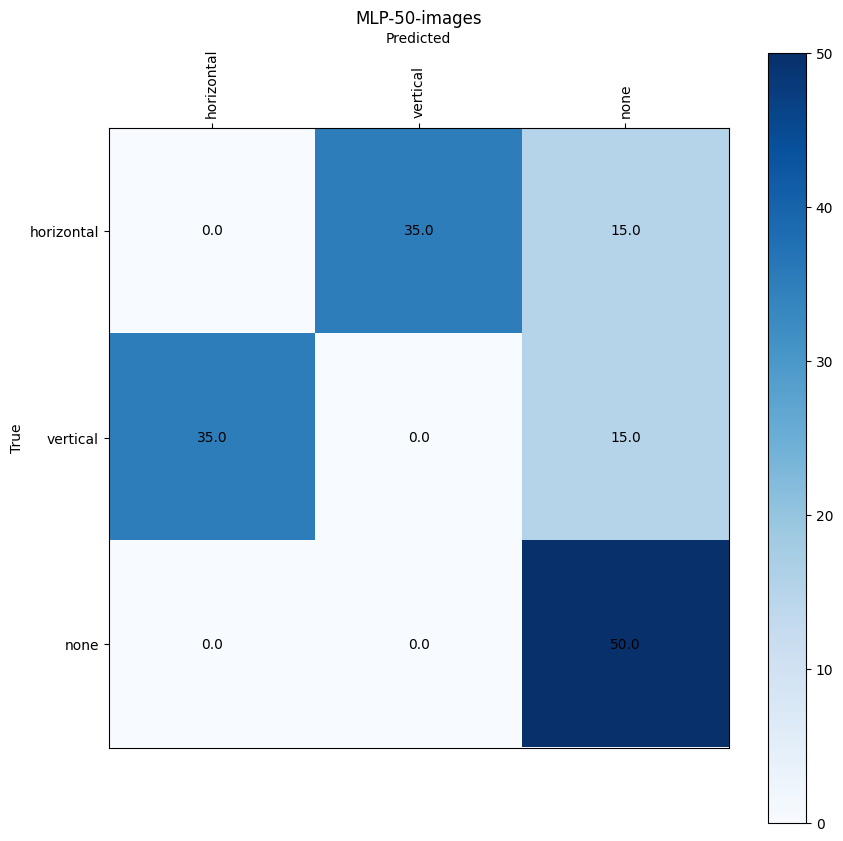

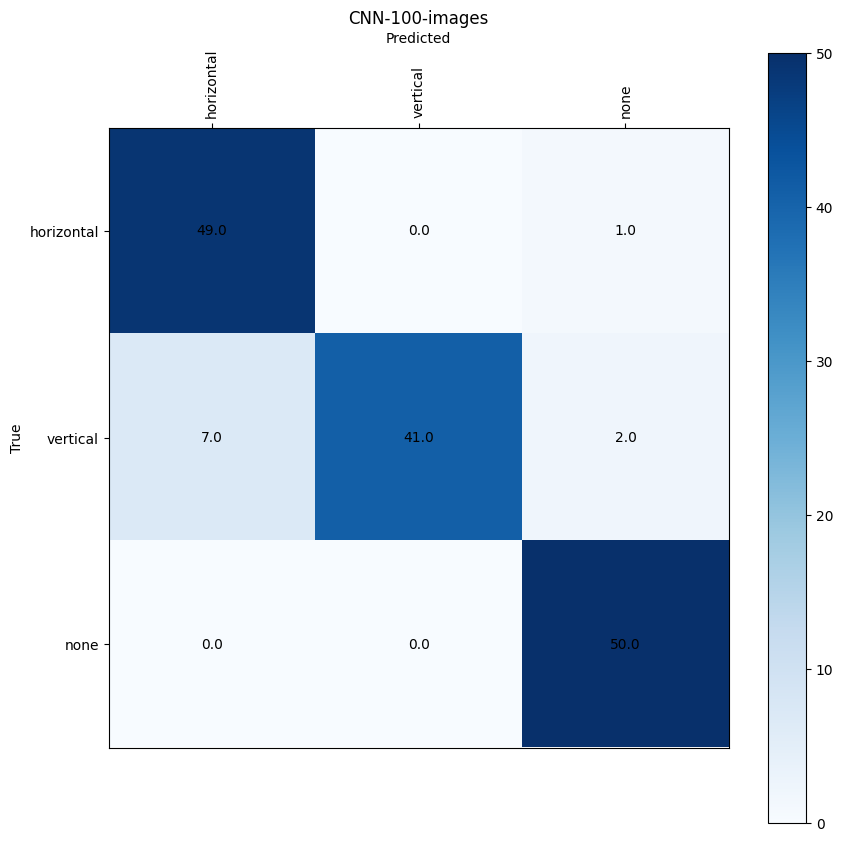

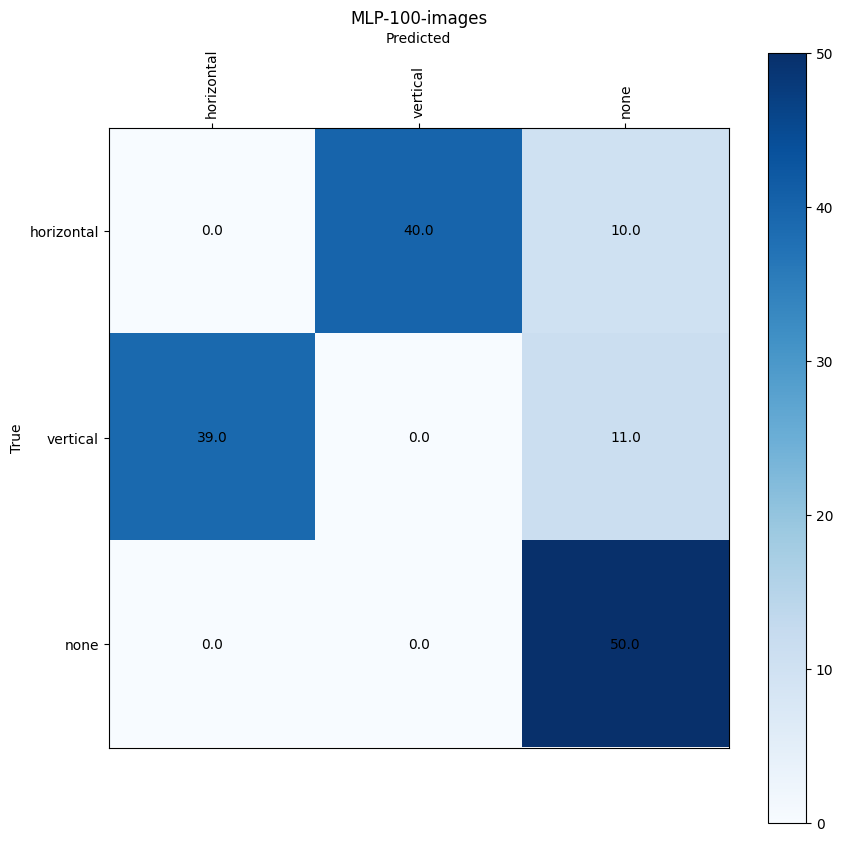

In [ ]:
## Plot the confusion matrix
for num_image, cnn_confusion_matrix in cnn_confusion_matrix_dict.items():
    mlp_confusion_matrix = mlp_confusion_matrix_dict[num_image]
    vis_confusion_matrix(cnn_confusion_matrix, ['horizontal', 'vertical', 'none'], 'CNN-{}-images'.format(num_image))
    vis_confusion_matrix(mlp_confusion_matrix, ['horizontal', 'vertical', 'none'], 'MLP-{}-images'.format(num_image))
plt.show()

Training with 10 images


100%|██████████| 300/300 [00:17<00:00, 17.43it/s]


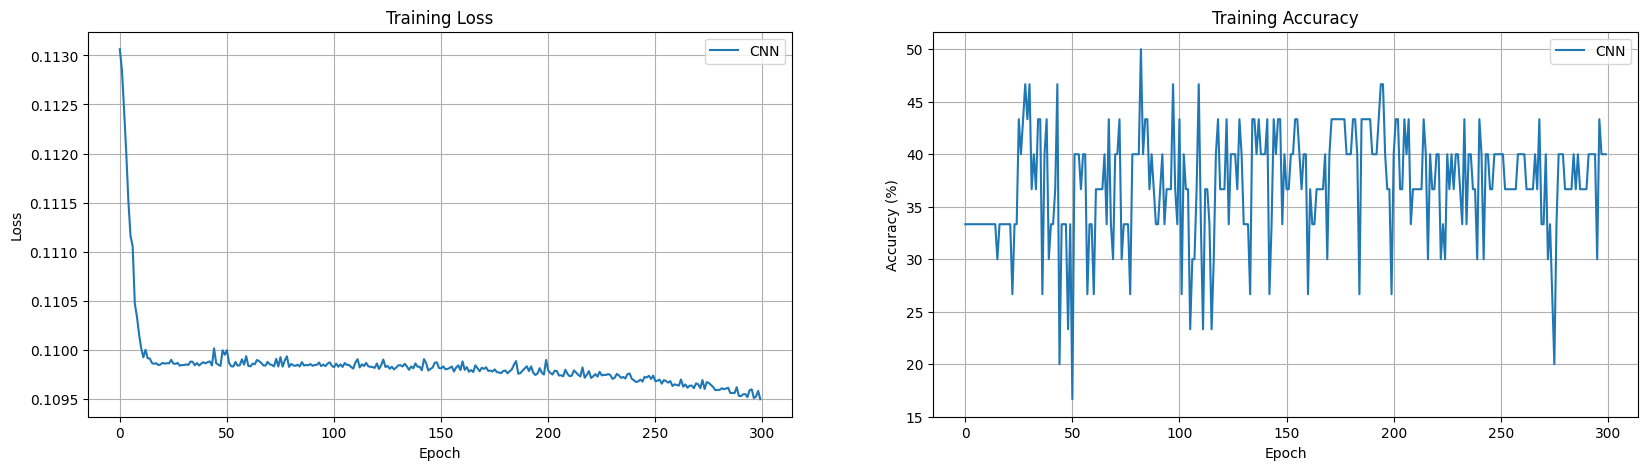

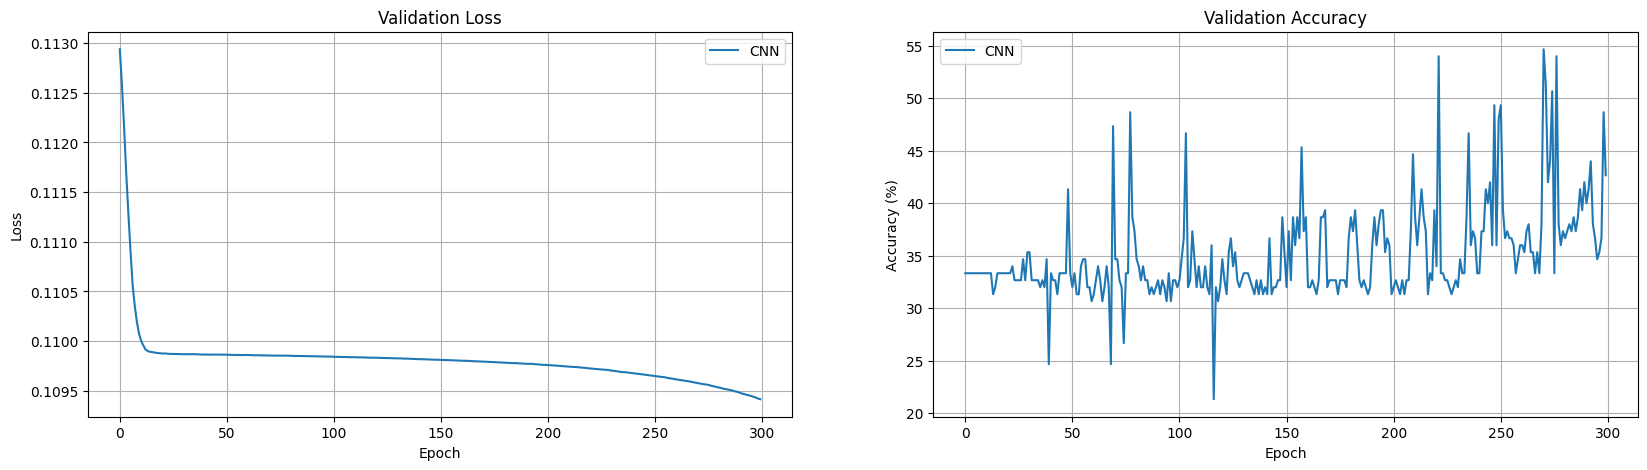

CNN Acc: 42.6667
Training with 30 images


100%|██████████| 300/300 [00:25<00:00, 11.83it/s]


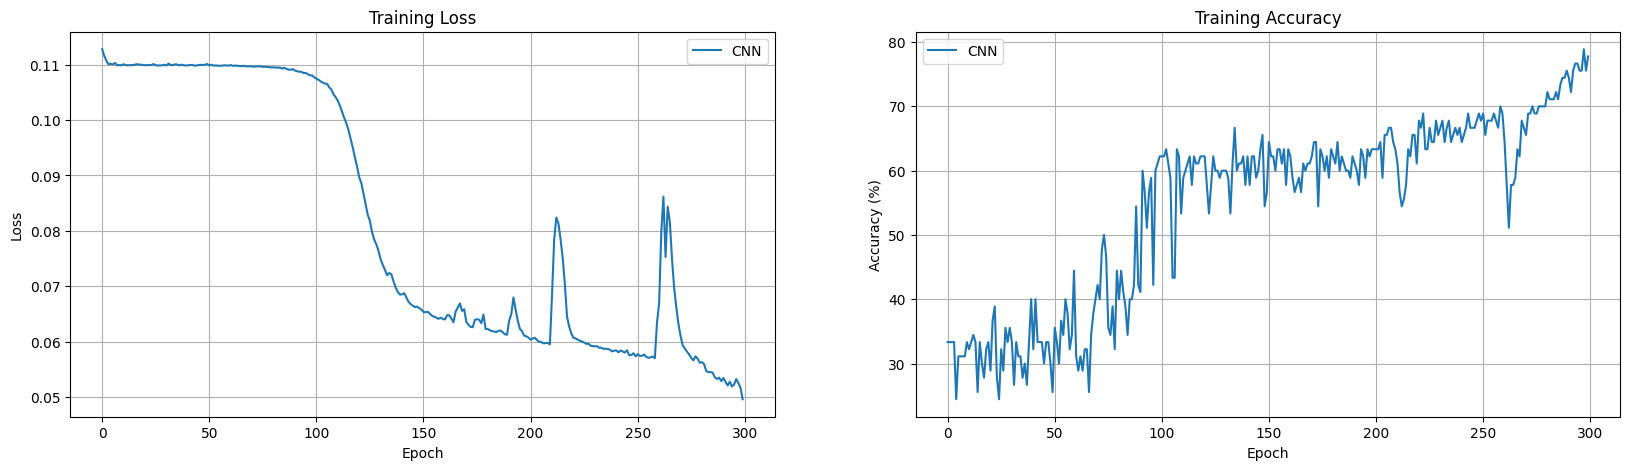

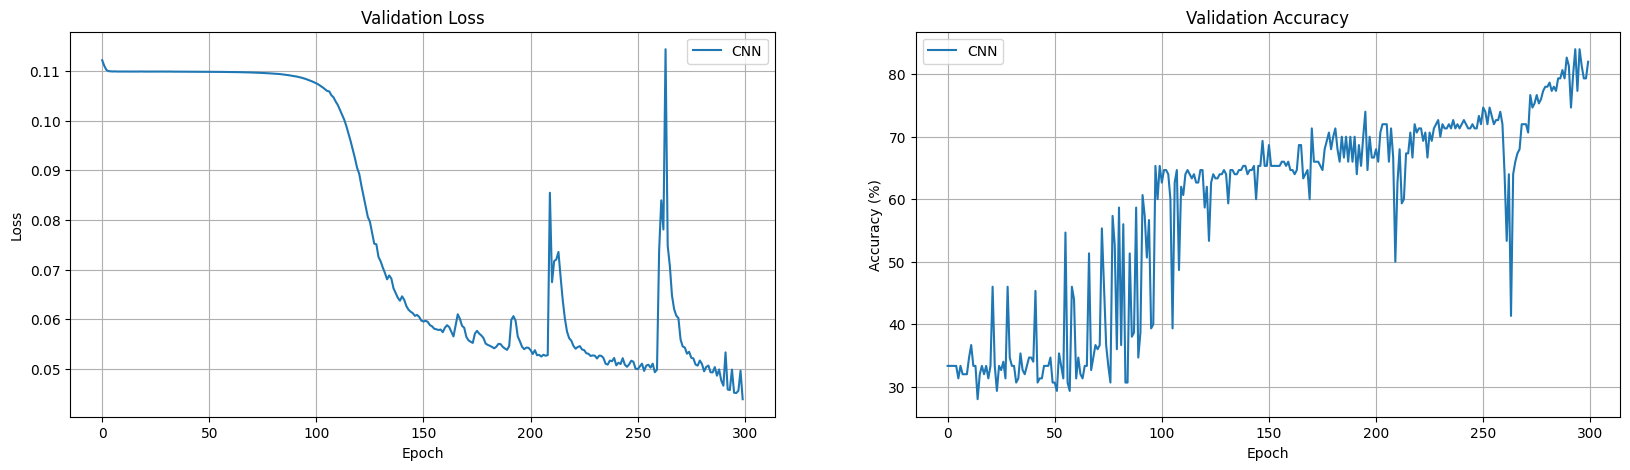

CNN Acc: 82.0000
Training with 50 images


100%|██████████| 300/300 [00:35<00:00,  8.39it/s]


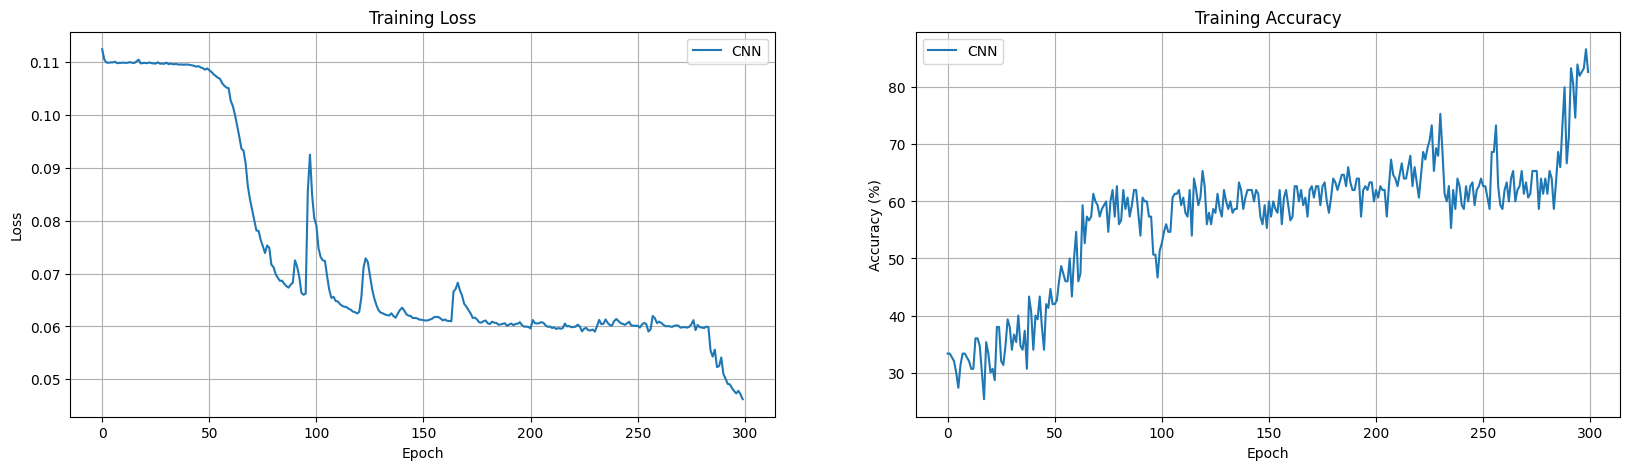

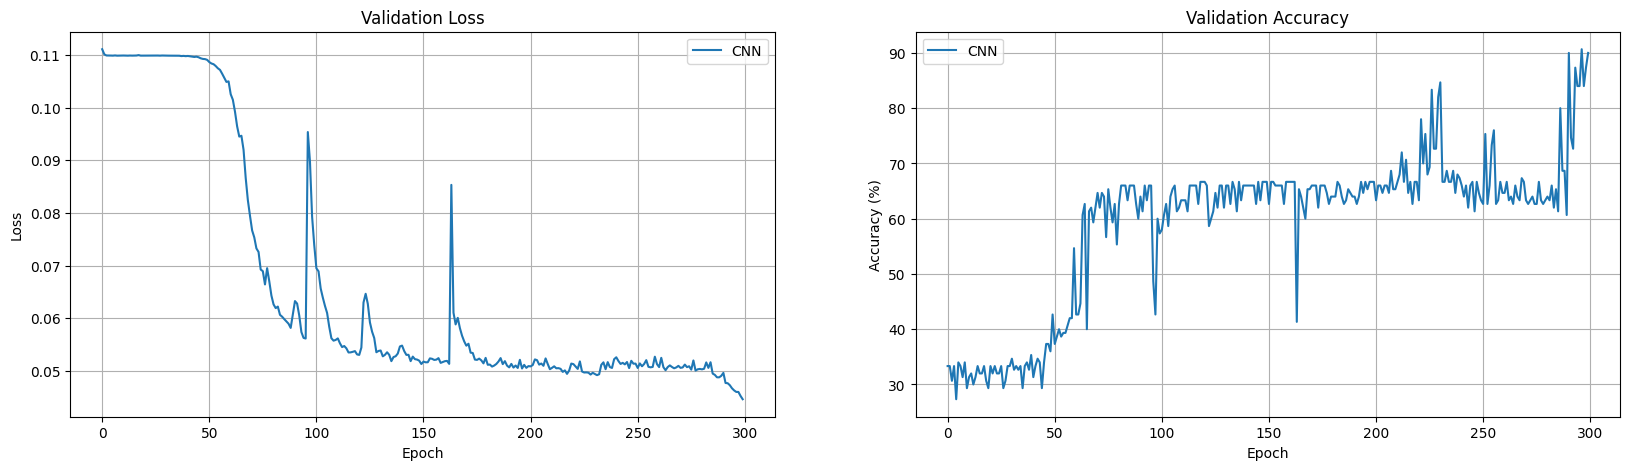

CNN Acc: 90.0000
Training with 100 images


100%|██████████| 300/300 [00:53<00:00,  5.57it/s]


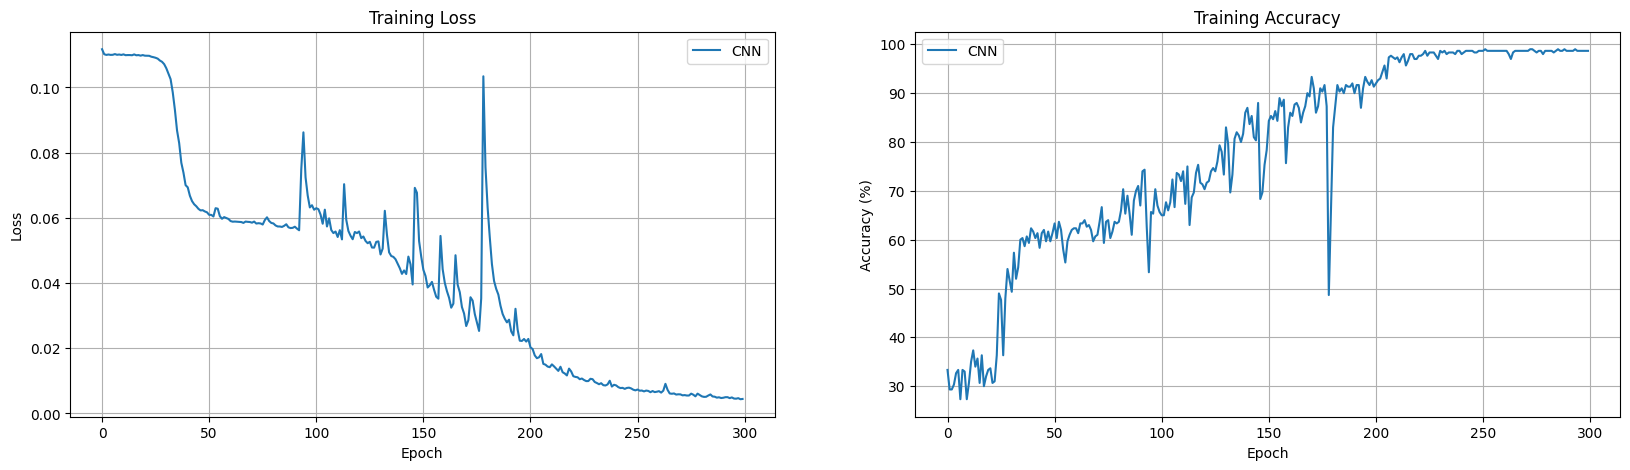

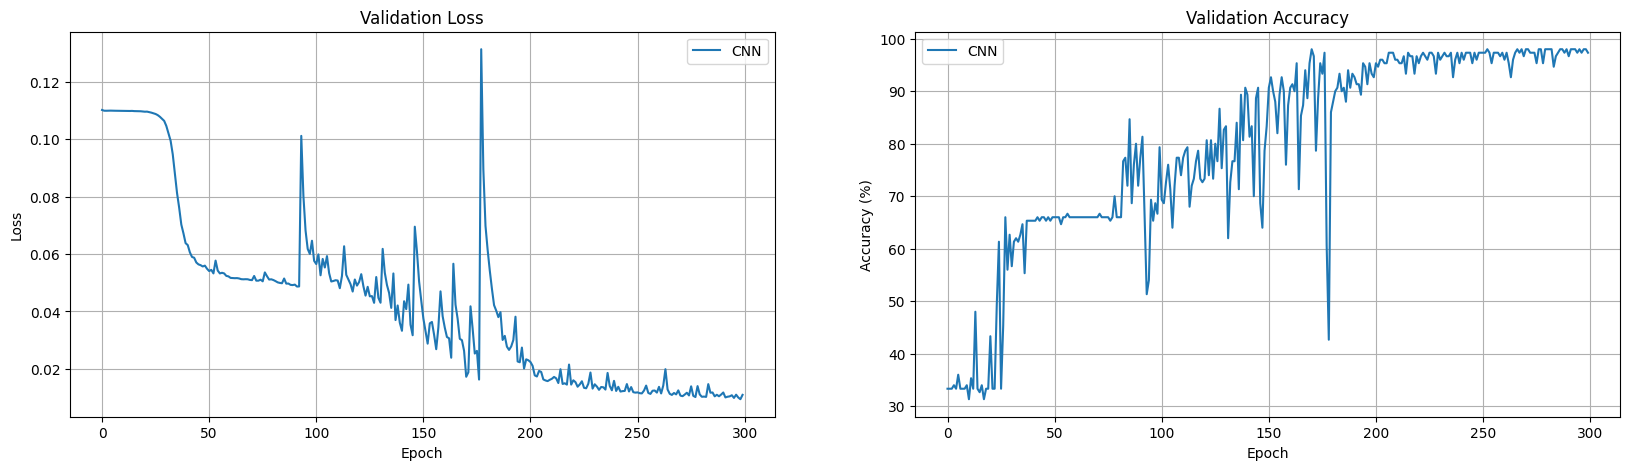

CNN Acc: 97.3333
Training with 10 images


100%|██████████| 300/300 [00:16<00:00, 18.29it/s]


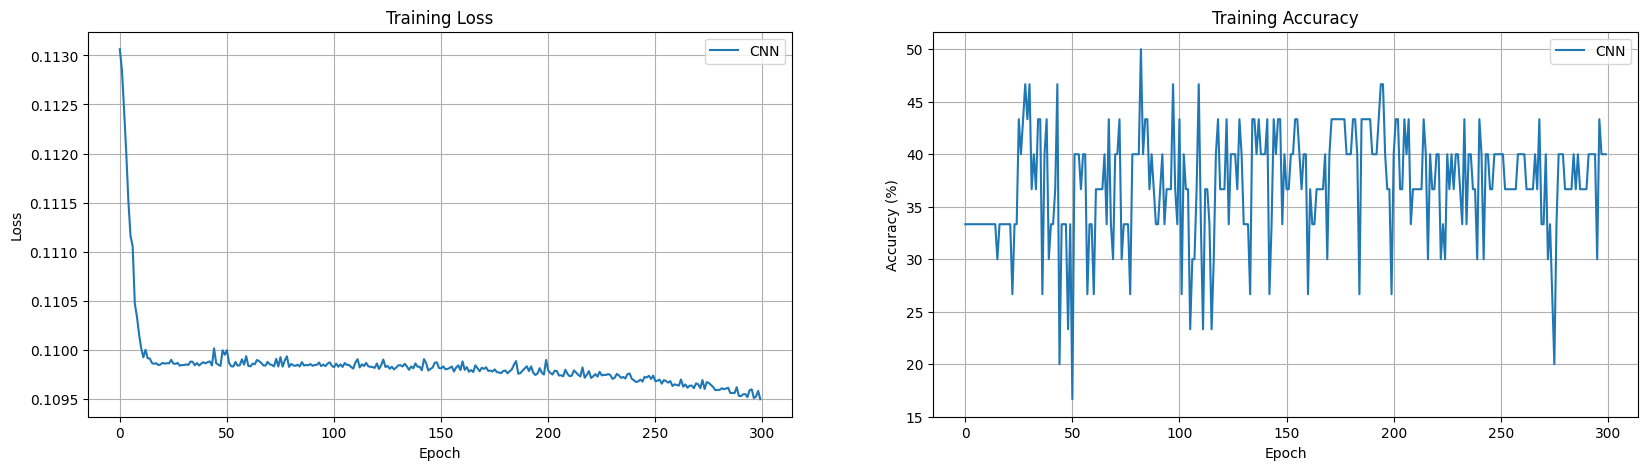

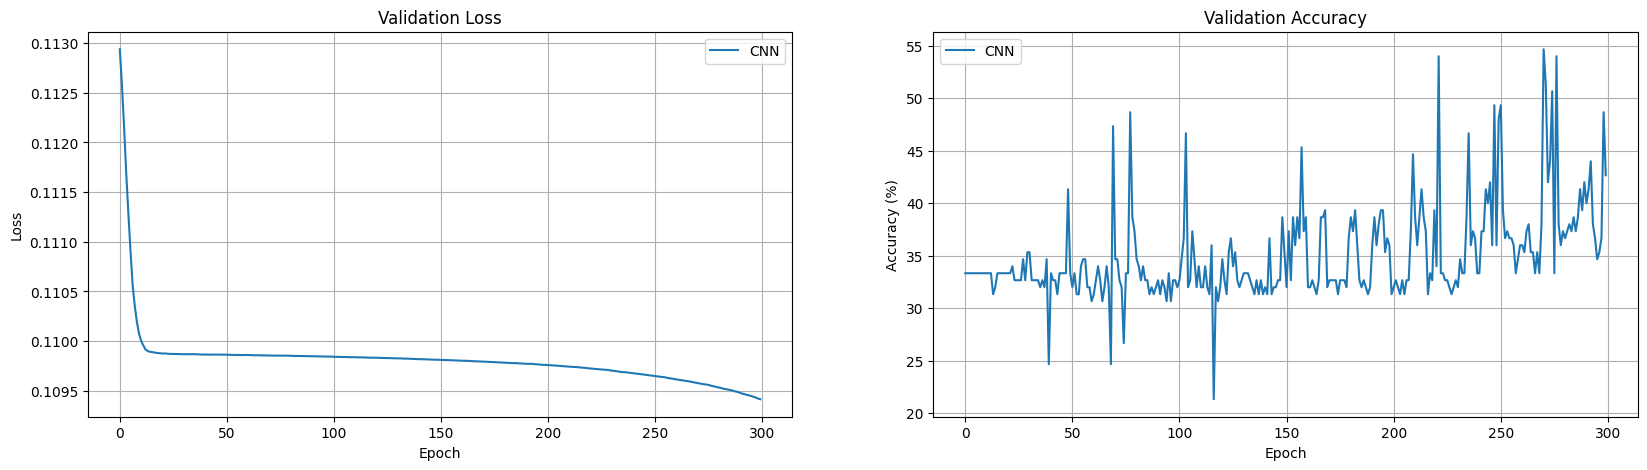

CNN Acc: 42.666666666666664
Training with 30 images


100%|██████████| 300/300 [00:25<00:00, 11.87it/s]


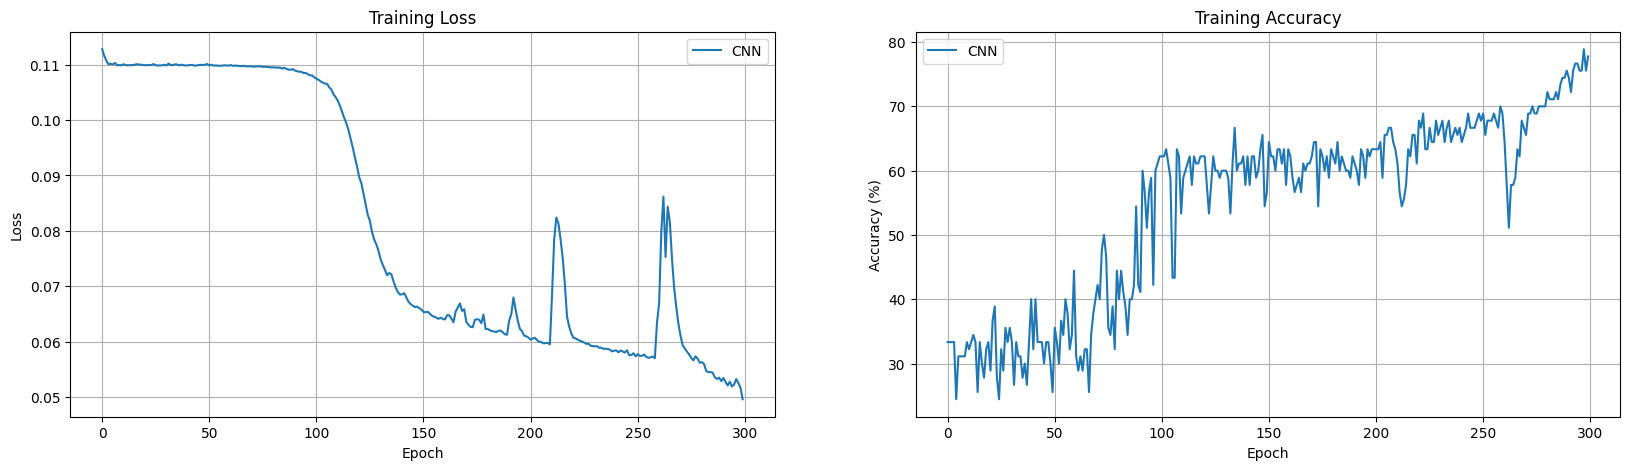

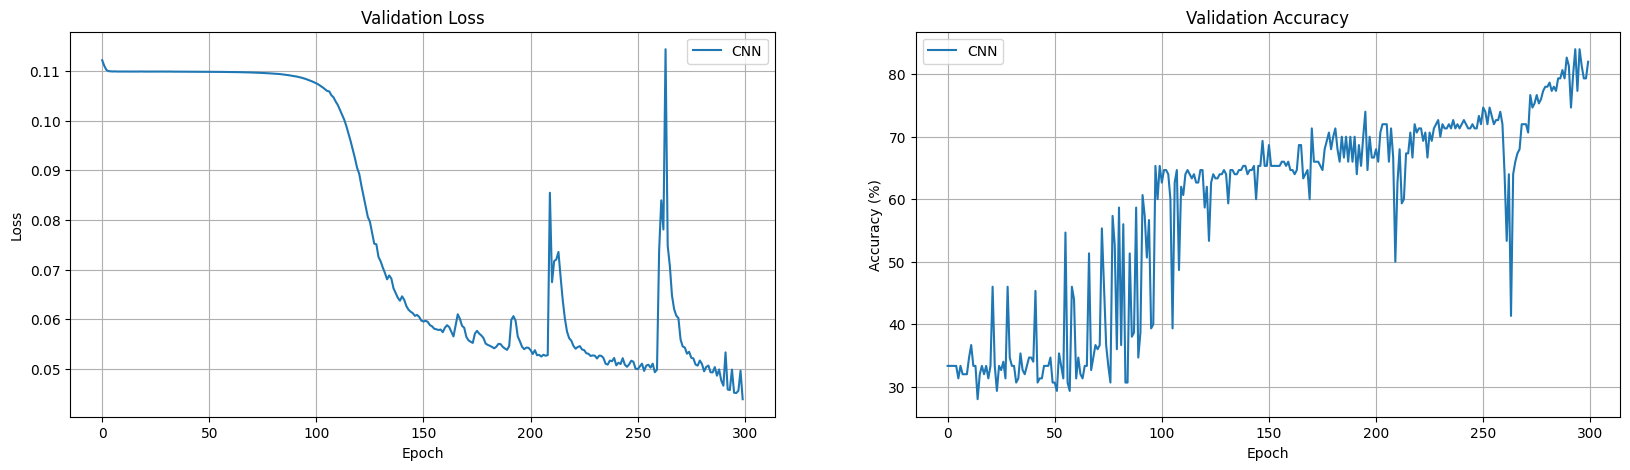

CNN Acc: 82.0
Training with 50 images


100%|██████████| 300/300 [00:34<00:00,  8.58it/s]


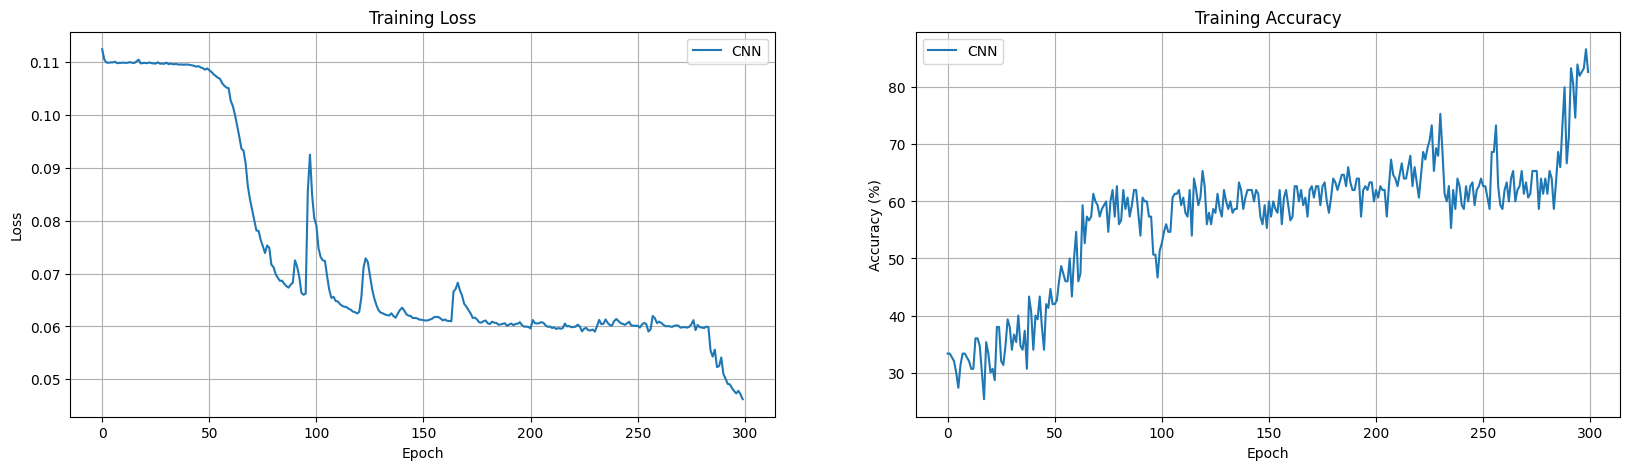

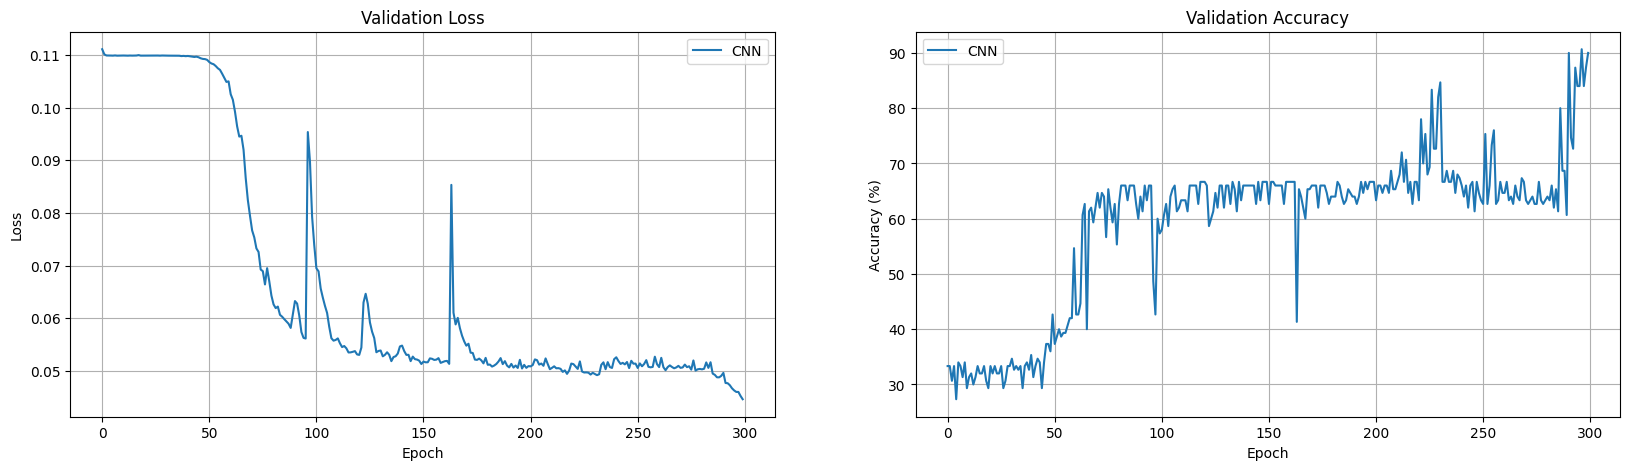

CNN Acc: 90.0
Training with 100 images


100%|██████████| 300/300 [00:54<00:00,  5.46it/s]


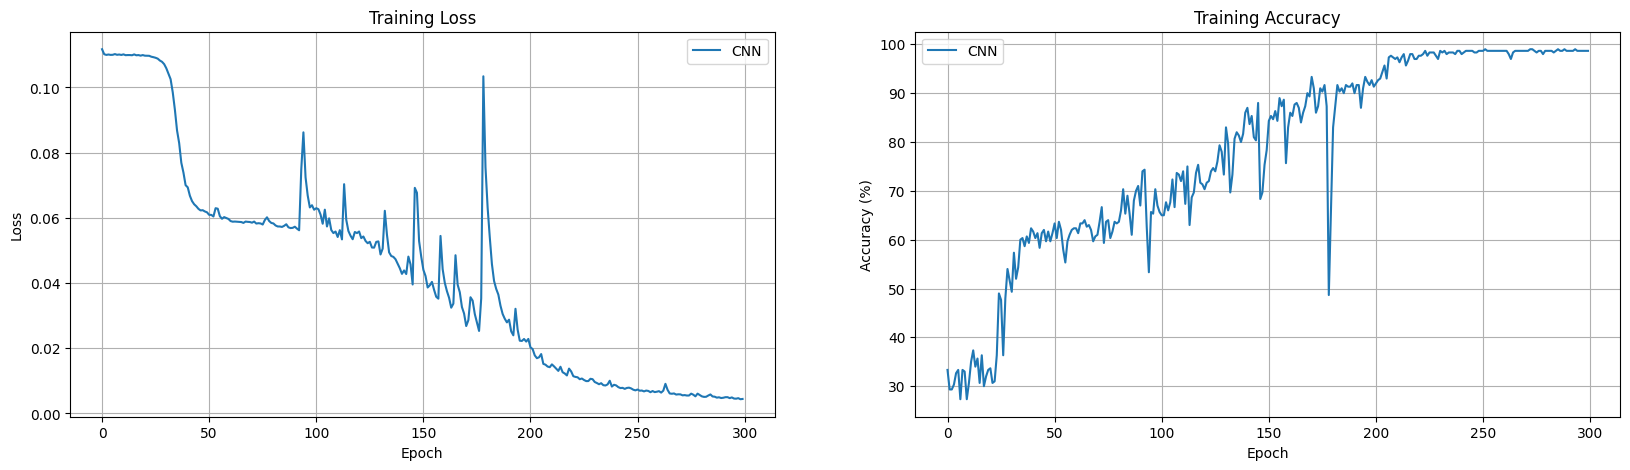

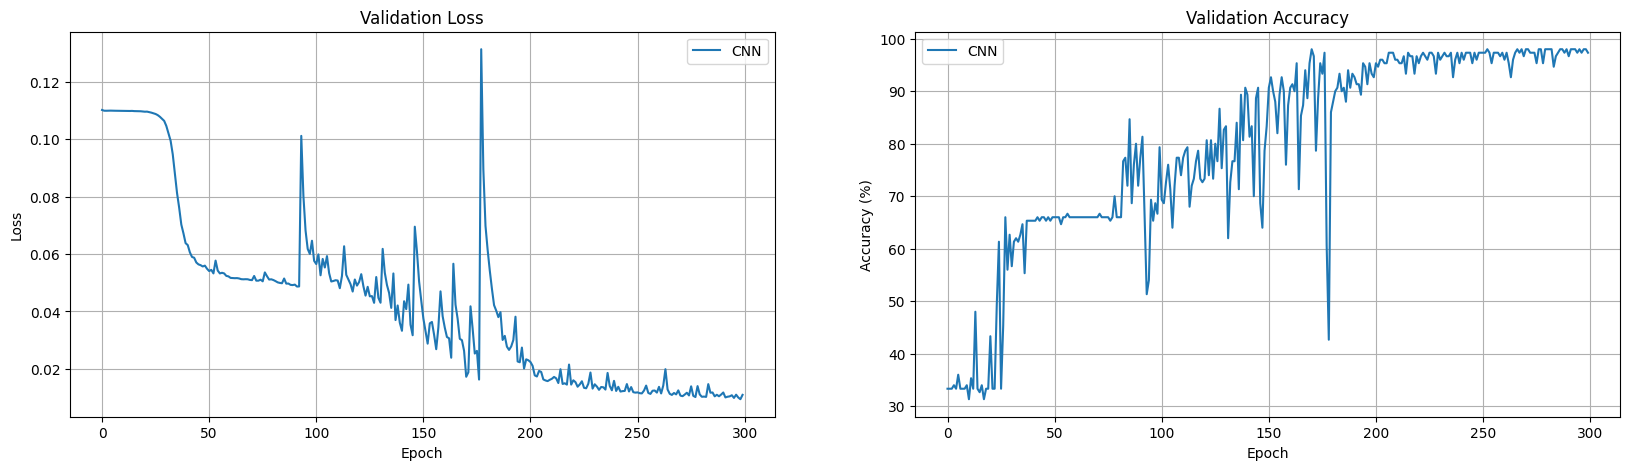

CNN Acc: 97.33333333333333


In [ ]:
num_epochs = 300
lr = 0.01
kernel_size = 3

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_valid_acc_list = []
cnn_kernel_dict = dict()
cnn_confusion_matrix_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=kernel_size)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], None, None)
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], None, None)

    print("CNN Acc: {:.4f}".format(cnn_results["final_valid_acc"]))

    cnn_valid_acc_list.append(cnn_results["final_valid_acc"])
    cnn_kernel_dict[num_image] = deepcopy(cnn_model.conv1.weight.detach().cpu())
    cnn_confusion_matrix_dict[num_image] = cnn_results["confusion_matrix"]
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_valid_acc_list = list()

cnn_kernel_dict = dict()

cnn_confusion_matrix_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=kernel_size)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], None, None)
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], None, None)

    print("CNN Acc: {}".format(cnn_results["final_valid_acc"]))

PART 5

In [ ]:
set_seed(seed)
visual_domain_config = None
use_permutation = True

permutater = np.arange(28 * 28,  dtype=np.int32)
np.random.shuffle(permutater)
unpermutater = np.argsort(permutater)

visual_dataset = None

transforms = T.Compose([T.ToTensor()])

visual_domain_config = dict(
    data_per_class=10,
    use_permutation=True,
    permutater=permutater,
    unpermutater=unpermutater,
)
visual_dataset = EdgeDetectionDataset(visual_domain_config, mode='train', transform=transforms)

Dataset Image before permutation
Dataset Image after permutation


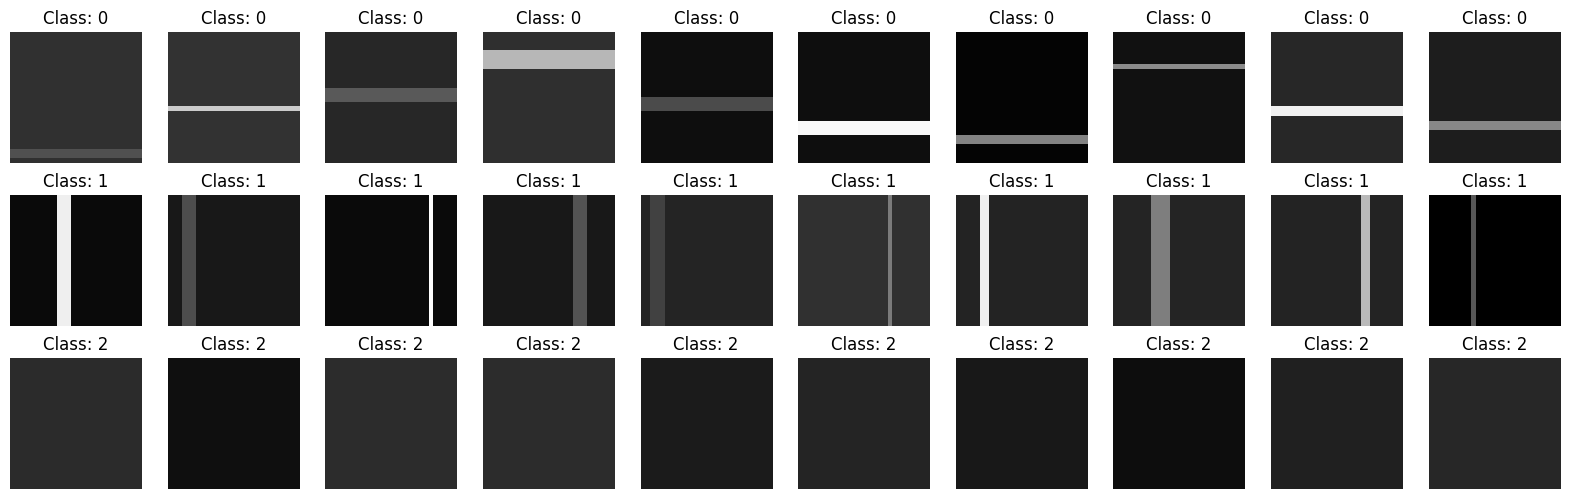

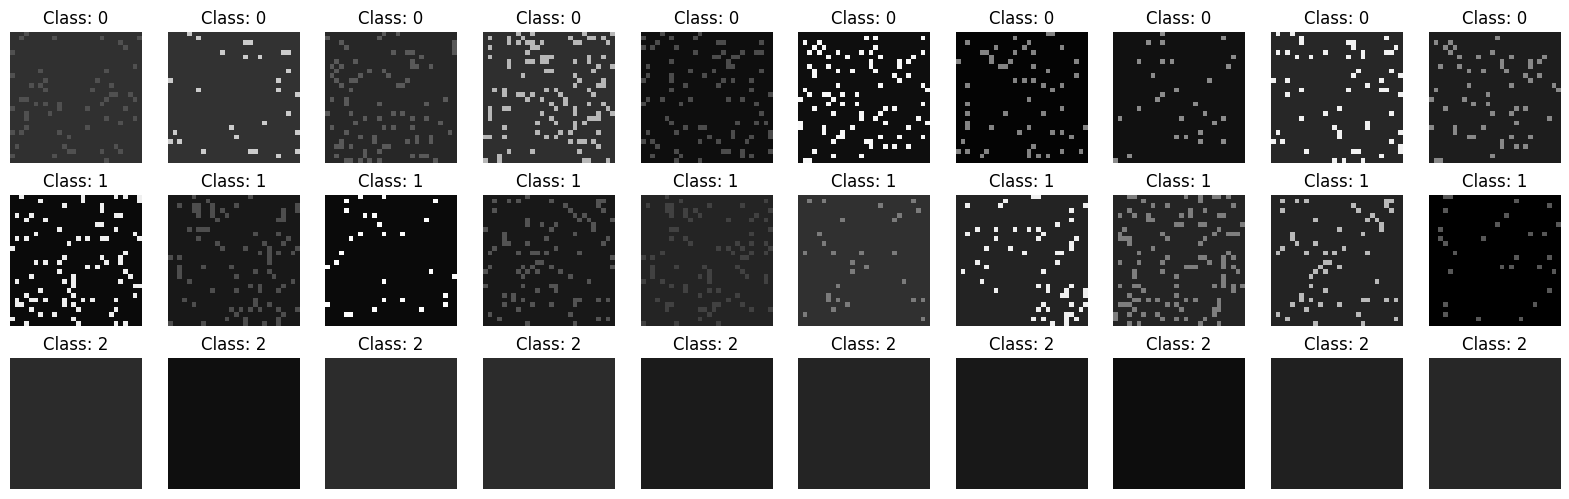

In [ ]:
## Visualize the images
unpermutator = visual_dataset.get_unpermutater()
print('Dataset Image before permutation')
vis_unpermuted_dataset(visual_dataset, num_classes=3, num_show_per_class=10, unpermutator=unpermutator)

print('Dataset Image after permutation')
vis_dataset(visual_dataset, num_classes=3, num_show_per_class=10)

plt.show()

In [ ]:
set_seed(seed)

train_loader_dict = dict()
num_train_images_list = [10, 30, 50, 100]
use_permutation = True
valid_loader = None

permutater = np.arange(28 * 28,  dtype=np.int32)
np.random.shuffle(permutater)
unpermutater = np.argsort(permutater)

transforms = T.Compose([T.ToTensor()])

batch_size = 10

for num_image in num_train_images_list:
    train_dataset_config = dict(
        data_per_class=num_image,
        use_permutation=True,
        permutater=permutater,
        unpermutater=unpermutater,
    )
    train_dataset = EdgeDetectionDataset(train_dataset_config, 'train', transform=transforms)
    train_loader_dict[num_image] = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

valid_dataset_config = dict(
    data_per_class=50,
    use_permutation=True,
    permutater=permutater,
    unpermutater=unpermutater,
)
valid_dataset = EdgeDetectionDataset(valid_dataset_config, 'valid', transform=transforms)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=False)


Training with 10 images


100%|██████████| 300/300 [00:20<00:00, 14.81it/s]


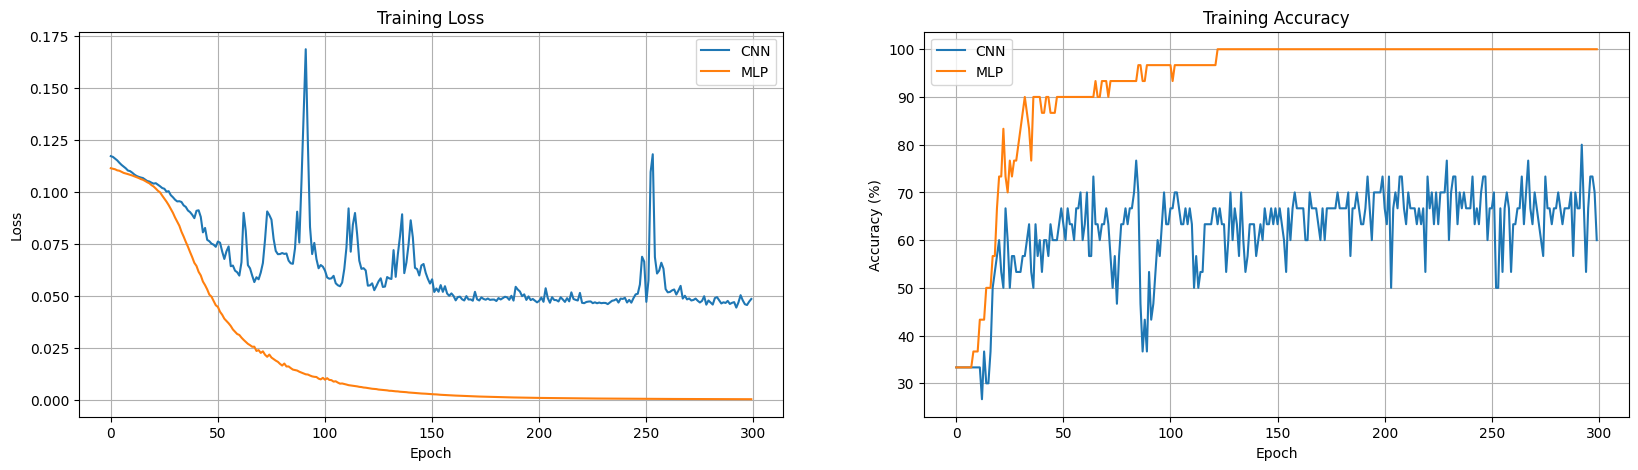

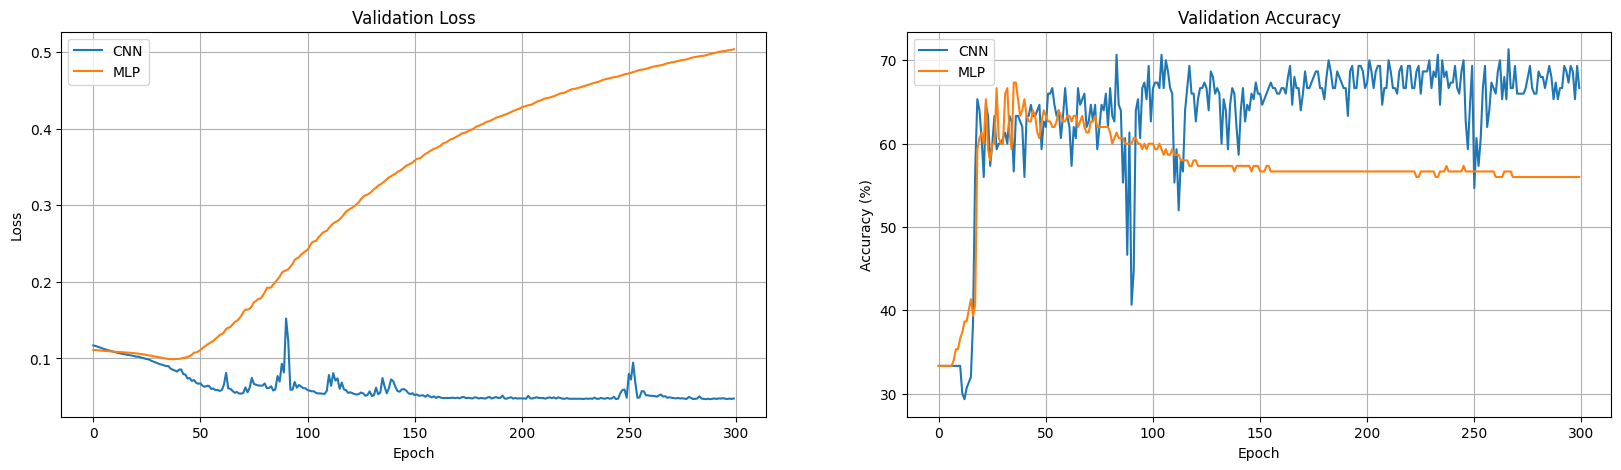

CNN Acc: 66.66666666666667, MLP Acc: 56.0
Training with 30 images


100%|██████████| 300/300 [00:30<00:00,  9.89it/s]


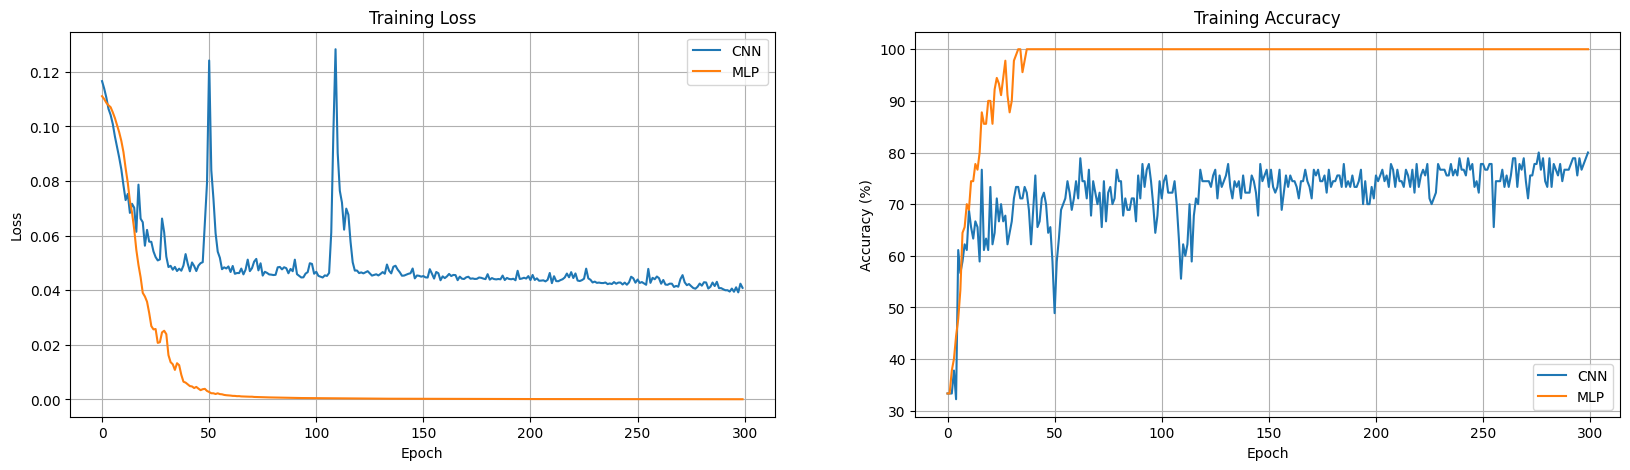

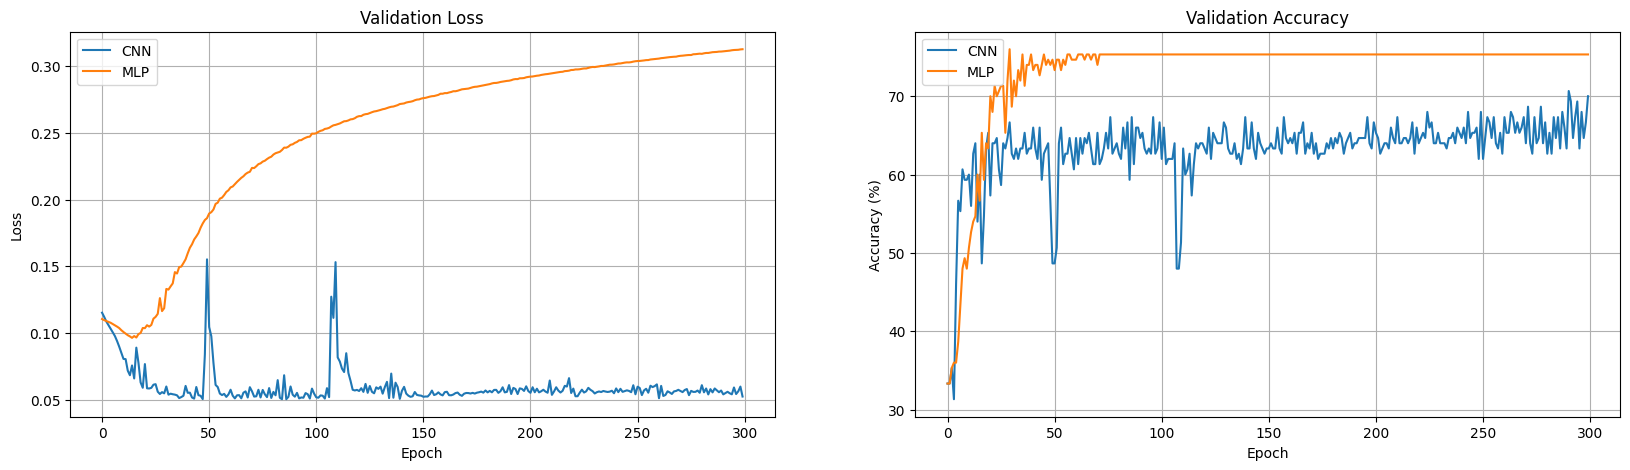

CNN Acc: 70.0, MLP Acc: 75.33333333333333
Training with 50 images


100%|██████████| 300/300 [00:42<00:00,  6.99it/s]


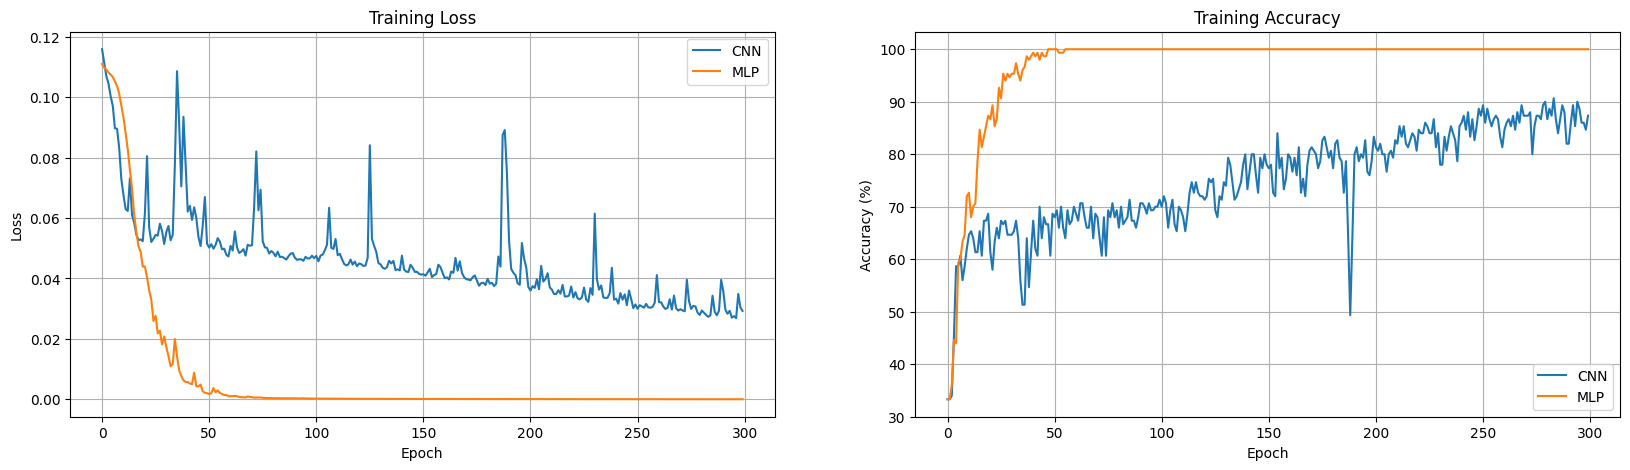

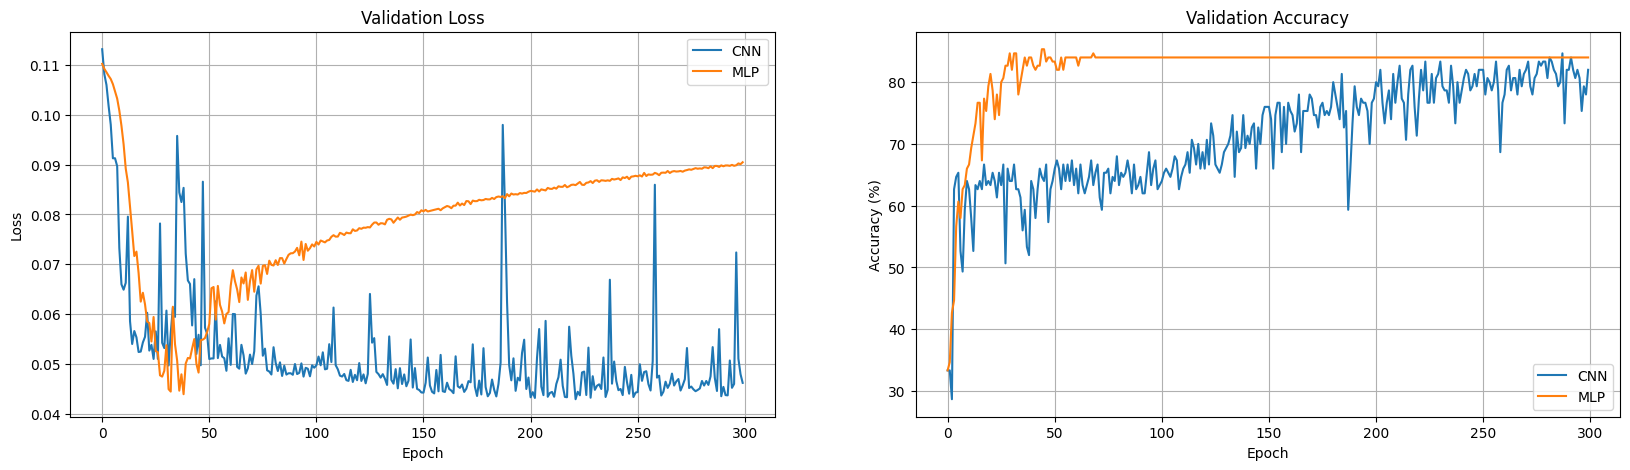

CNN Acc: 82.0, MLP Acc: 84.0
Training with 100 images


100%|██████████| 300/300 [01:09<00:00,  4.29it/s]


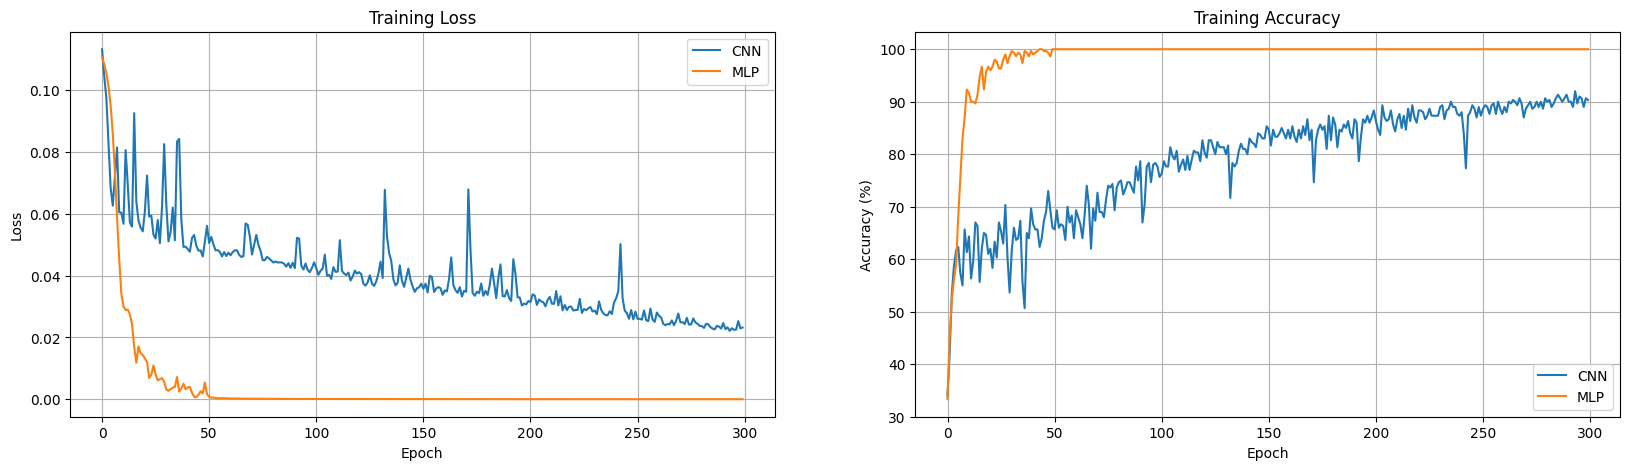

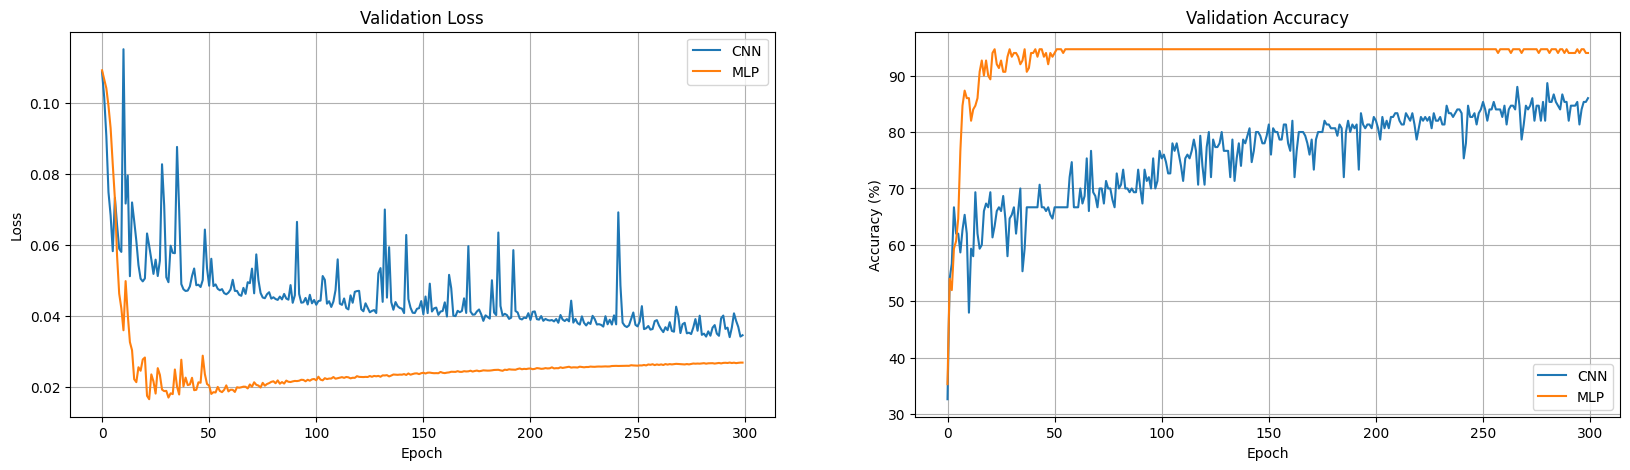

CNN Acc: 86.0, MLP Acc: 94.0


In [ ]:
lr = 1e-2
num_epochs = 300
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_kernel_dict = dict()
untrained_cnn_kernel_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=7)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10])
    mlp_model.to(device)

    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    mlp_results = train_model(mlp_model, mlp_optimizer, num_epochs, train_loader, valid_loader)
    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], mlp_results["train_loss"], mlp_results["train_acc"])
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], mlp_results["valid_loss"], mlp_results["valid_acc"])

    cnn_kernel_dict[num_image] = cnn_model.conv1.weight.detach().cpu()
    untrained_cnn_kernel_dict[num_image] = untrained_cnn_model.conv1.weight.detach().cpu()

    print("CNN Acc: {}, MLP Acc: {}".format(cnn_results["final_valid_acc"], mlp_results["final_valid_acc"]))

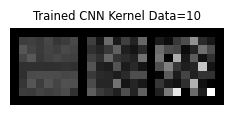

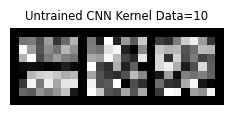

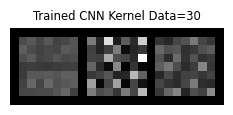

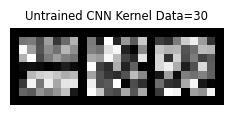

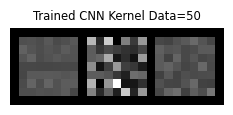

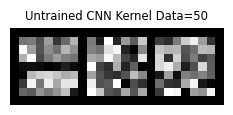

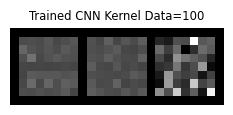

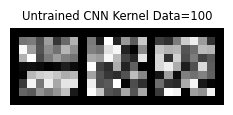

In [ ]:
for num_image, cnn_kernel in cnn_kernel_dict.items():
    untrained_kernel = untrained_cnn_kernel_dict[num_image]
    vis_kernel(cnn_kernel, ch=0, allkernels=False, title='Trained CNN Kernel Data={}'.format(num_image))
    vis_kernel(untrained_kernel, ch=0, allkernels=False, title='Untrained CNN Kernel Data={}'.format(num_image))
plt.show()

PART 6

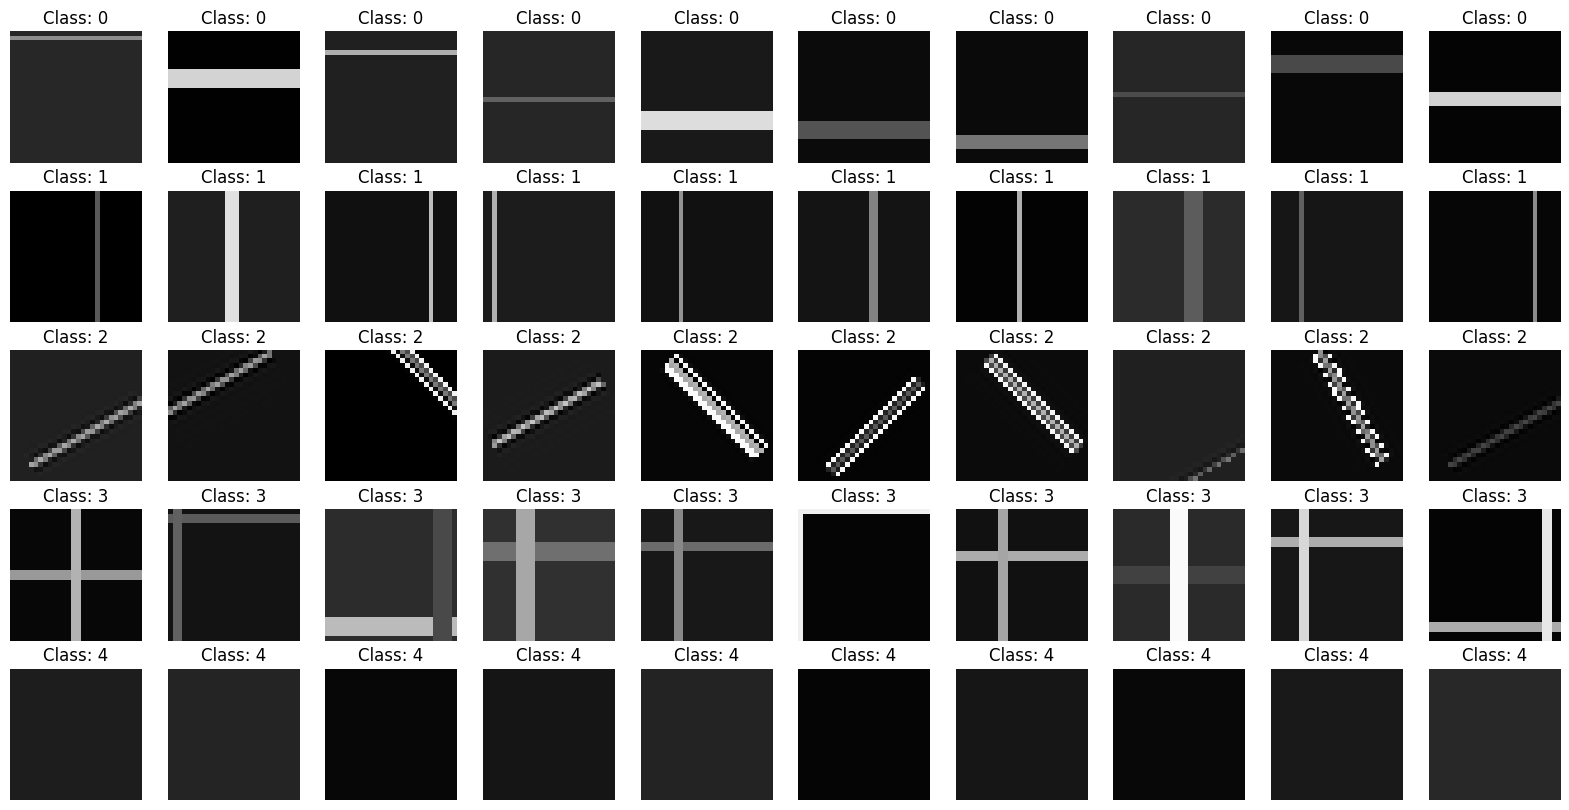

In [ ]:
set_seed(seed)
visual_domain_config = None

visual_dataset = None

transforms = T.Compose([T.ToTensor()])
visual_domain_config = dict(
    data_per_class=10,
    class_type=['horizontal', 'vertical', 'diagonal', 'both', 'none'],
    num_classes=5,
)

visual_dataset = EdgeDetectionDataset(visual_domain_config, 'train', transform=transforms)
vis_dataset(visual_dataset, 5, 10)
plt.show()

In [ ]:
set_seed(seed)

train_dataset_config = None
train_loader_dict = dict()
num_train_images_list = [10, 30, 50, 100]
valid_loader = None

transforms = T.Compose([T.ToTensor()])
batch_size = 10
class_type = ['horizontal', 'vertical', 'diagonal', 'both', 'none']
train_dataset_config = dict(
    class_type=class_type,
    num_classes=len(class_type),
)
for num_train_images in num_train_images_list:
    train_dataset_config['data_per_class'] = num_train_images
    train_dataset = EdgeDetectionDataset(train_dataset_config, 'train', transform=transforms)
    train_loader_dict[num_train_images] = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)


valid_dataset_config = dict(
    data_per_class=50,
    class_type=['horizontal', 'vertical', 'diagonal', 'both', 'none'],
    num_classes=len(class_type),
)
valid_dataset = EdgeDetectionDataset(valid_dataset_config, 'valid', transform=transforms)
valid_loader = DataLoader(valid_dataset, batch_size=batch_size, shuffle=True)

Training with 10 images


100%|██████████| 200/200 [00:26<00:00,  7.58it/s]


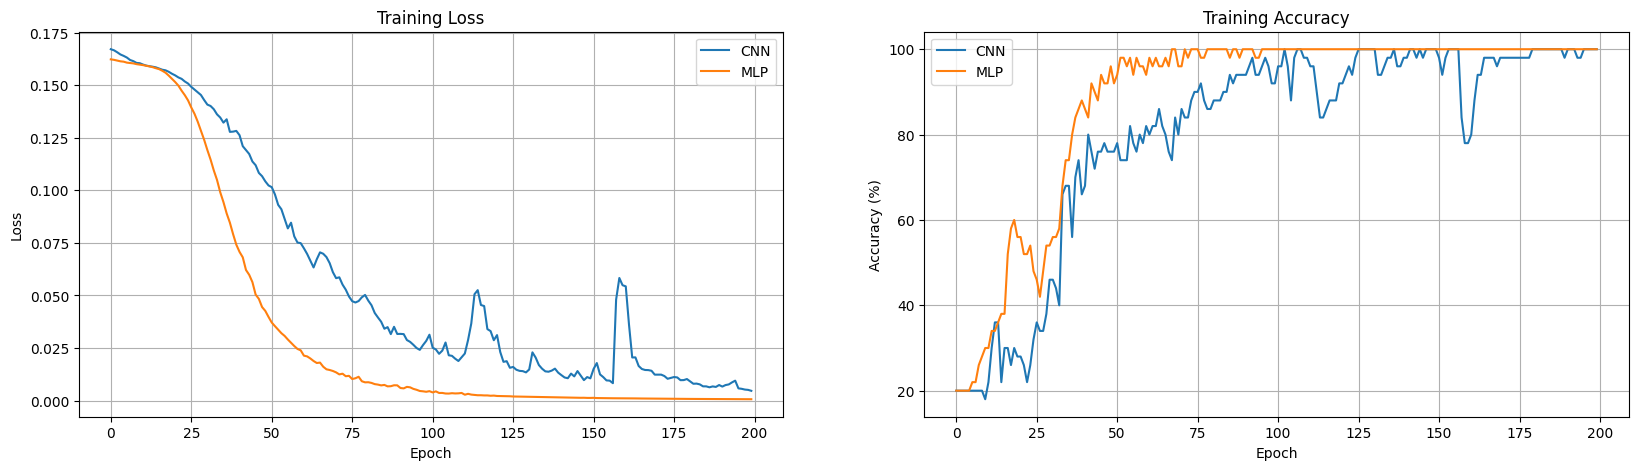

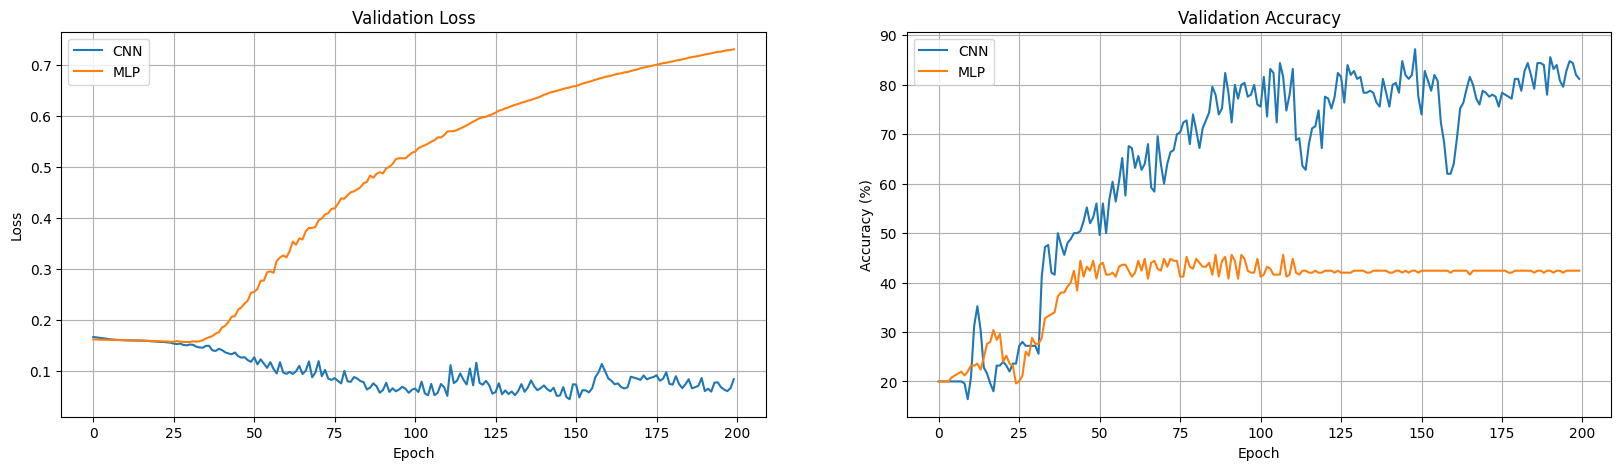

CNN Acc: 81.2, MLP Acc: 42.4
Training with 30 images


100%|██████████| 200/200 [00:35<00:00,  5.63it/s]


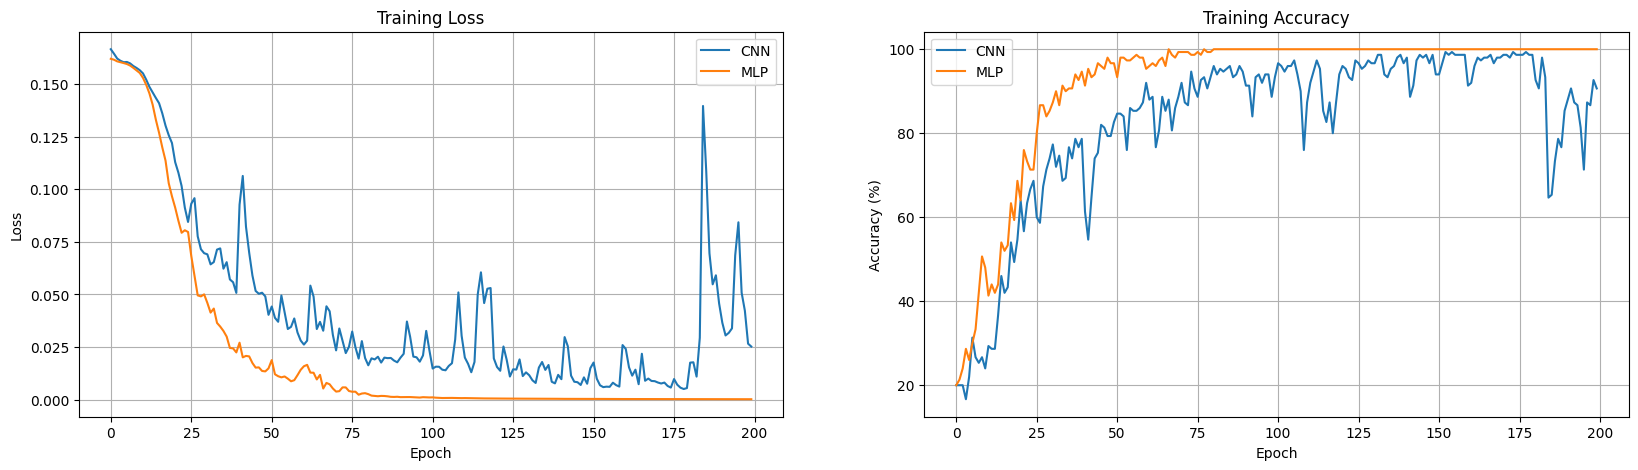

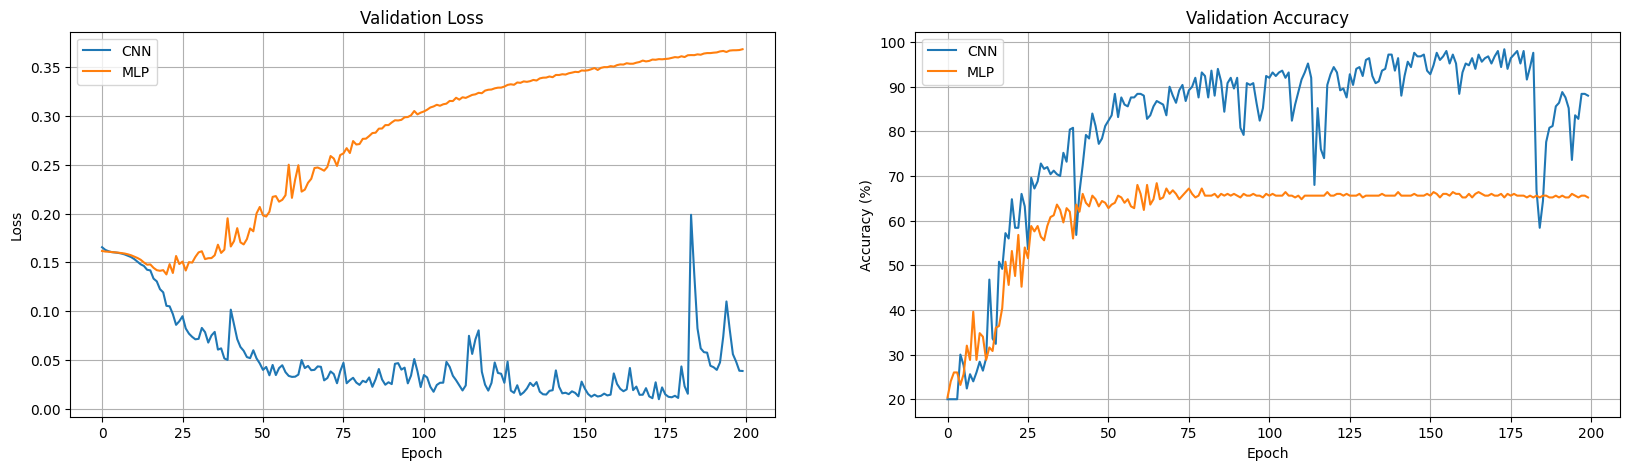

CNN Acc: 88.0, MLP Acc: 65.2
Training with 50 images


100%|██████████| 200/200 [00:47<00:00,  4.23it/s]


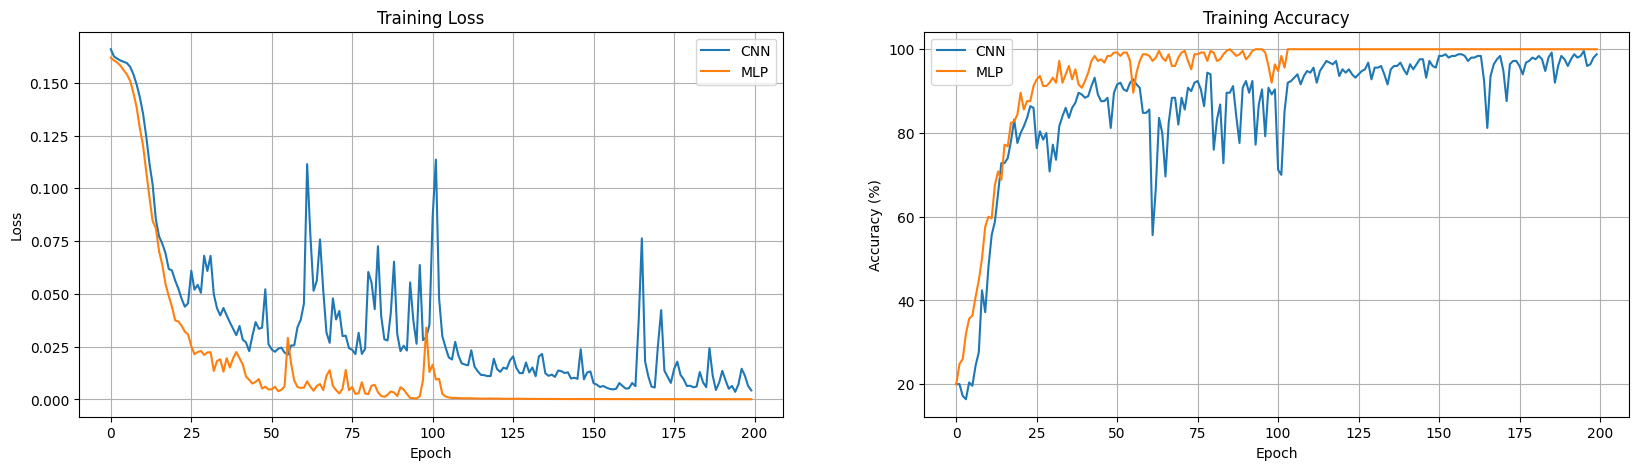

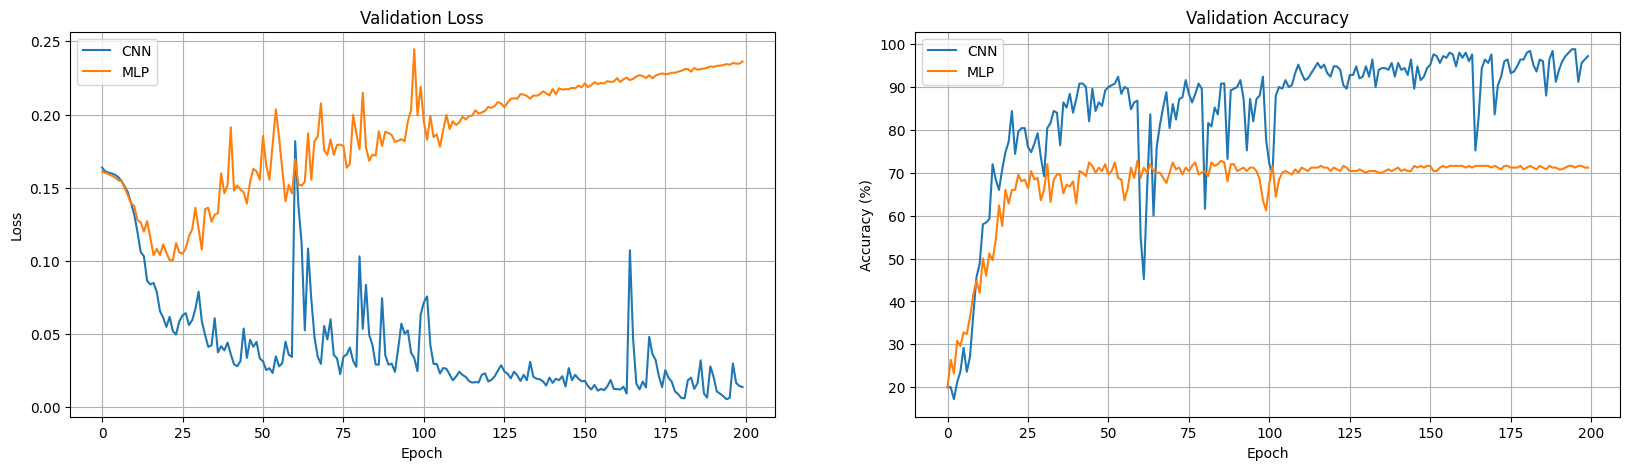

CNN Acc: 97.2, MLP Acc: 71.2
Training with 100 images


100%|██████████| 200/200 [01:17<00:00,  2.58it/s]


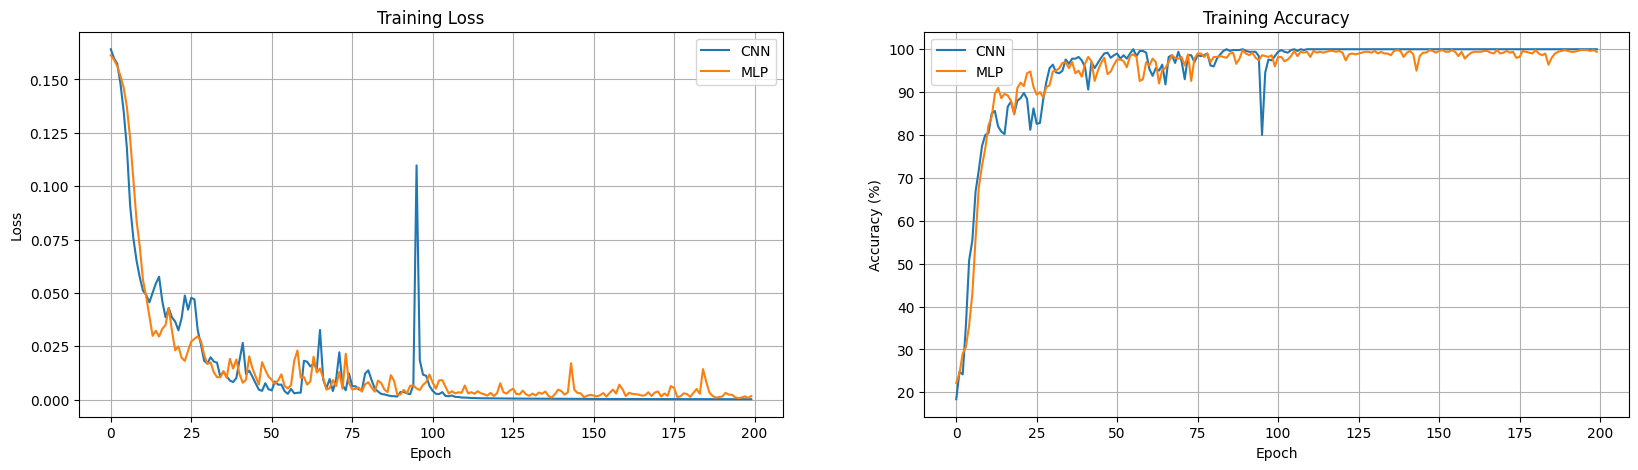

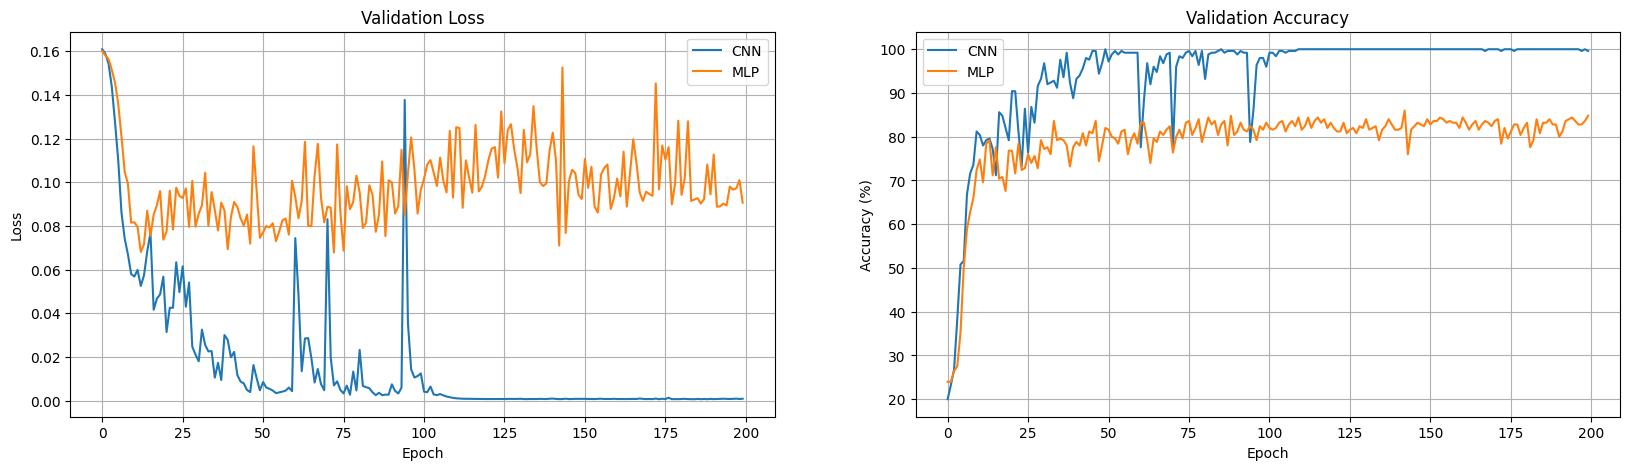

CNN Acc: 99.6, MLP Acc: 84.8


In [ ]:
lr = 1e-2
num_epochs = 200
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnn_kernel_dict = dict()
untrained_cnn_kernel_dict = dict()

cnn_confusion_matrix_dict = dict()
mlp_confusion_matrix_dict = dict()

cnn_result_dict = dict()
for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)
    cnn_model = SimpleCNN(kernel_size=7, num_classes=5)
    untrained_cnn_model = deepcopy(cnn_model)
    cnn_model.to(device)

    mlp_model = ThreeLayerMLP(hidden_dims=[50, 10], num_classes=5)
    mlp_model.to(device)

    mlp_optimizer = optim.SGD(mlp_model.parameters(), lr=lr, momentum=0.9)
    cnn_optimizer = optim.SGD(cnn_model.parameters(), lr=lr, momentum=0.9)

    mlp_results = train_model(mlp_model, mlp_optimizer, num_epochs, train_loader, valid_loader)
    cnn_results = train_model(cnn_model, cnn_optimizer, num_epochs, train_loader, valid_loader)

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], mlp_results["train_loss"], mlp_results["train_acc"])
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], mlp_results["valid_loss"], mlp_results["valid_acc"])

    cnn_kernel_dict[num_image] = cnn_model.conv1.weight.detach().cpu()
    untrained_cnn_kernel_dict[num_image] = untrained_cnn_model.conv1.weight.detach().cpu()

    cnn_result_dict[num_image] = cnn_results
    print("CNN Acc: {}, MLP Acc: {}".format(cnn_results["final_valid_acc"], mlp_results["final_valid_acc"]))

Training with 10 images


100%|██████████| 200/200 [00:20<00:00,  9.81it/s]


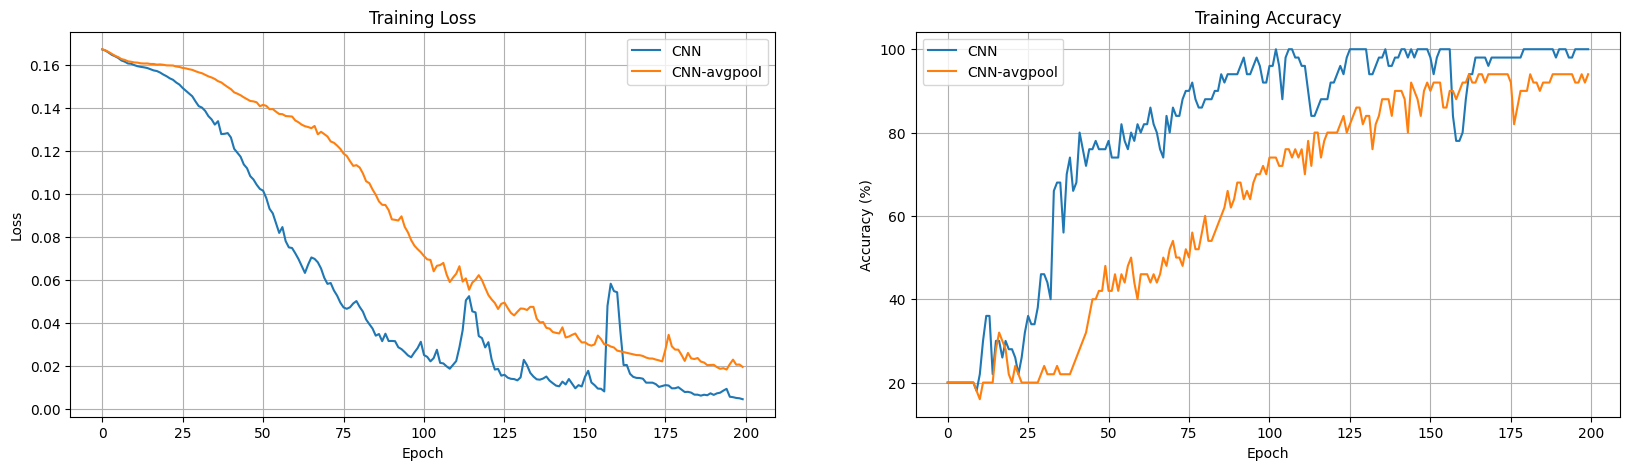

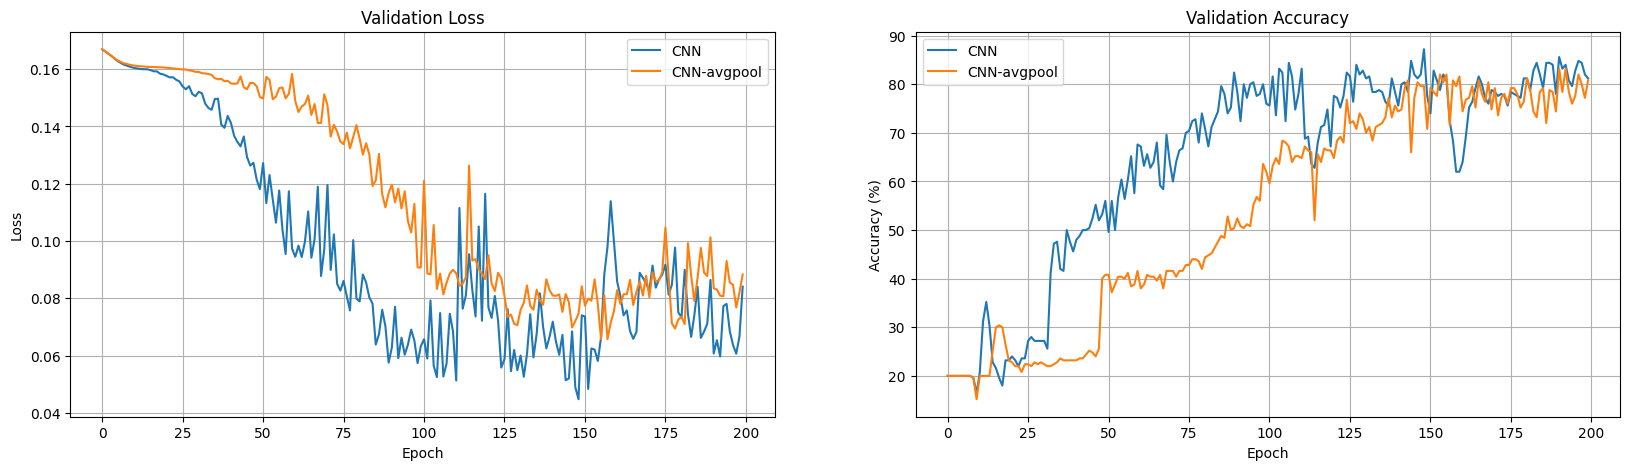

CNN-maxpool Acc: 81.2, CNN-avgpool Acc: 80.8
Training with 30 images


100%|██████████| 200/200 [00:35<00:00,  5.68it/s]


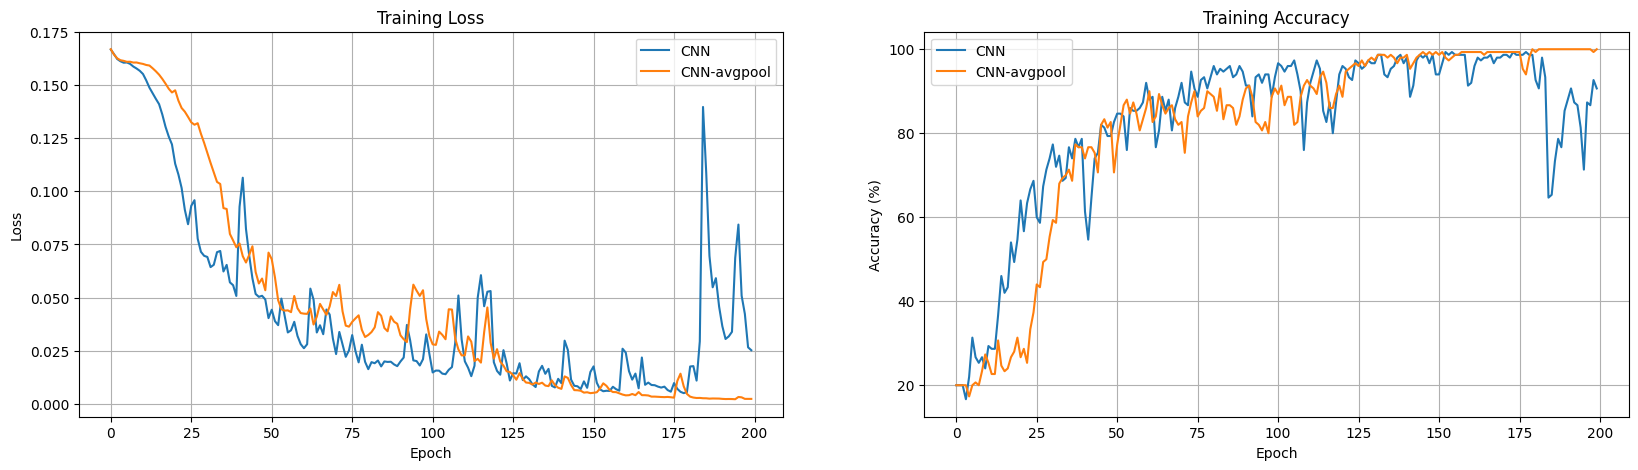

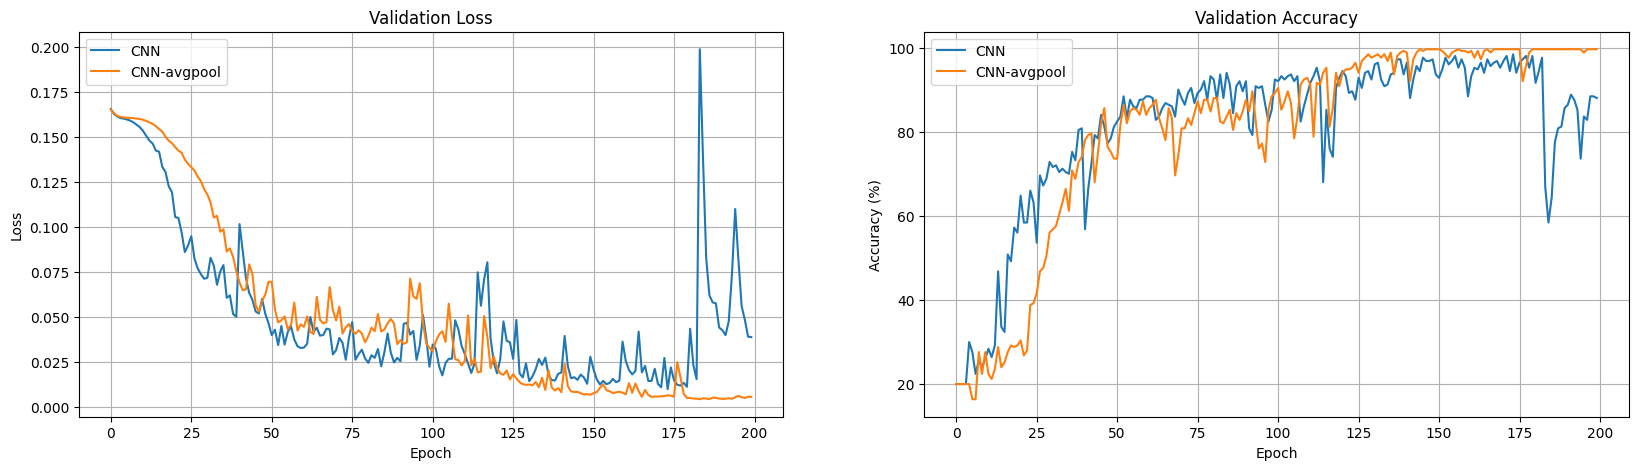

CNN-maxpool Acc: 88.0, CNN-avgpool Acc: 99.6
Training with 50 images


100%|██████████| 200/200 [00:51<00:00,  3.90it/s]


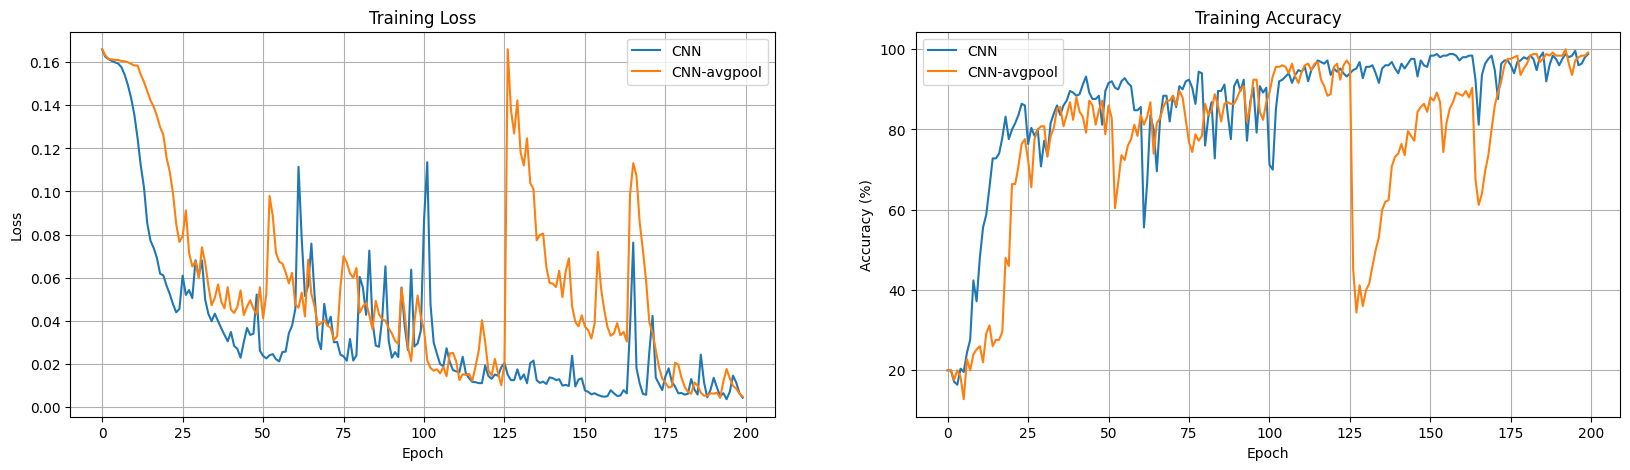

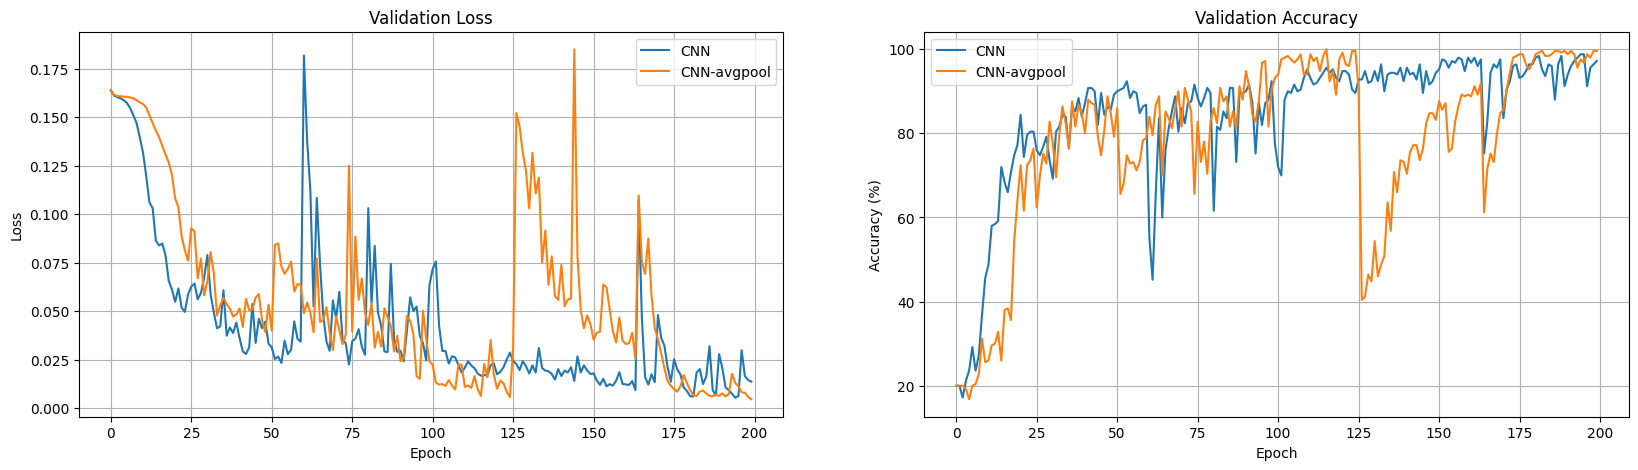

CNN-maxpool Acc: 97.2, CNN-avgpool Acc: 99.6
Training with 100 images


100%|██████████| 200/200 [01:30<00:00,  2.20it/s]


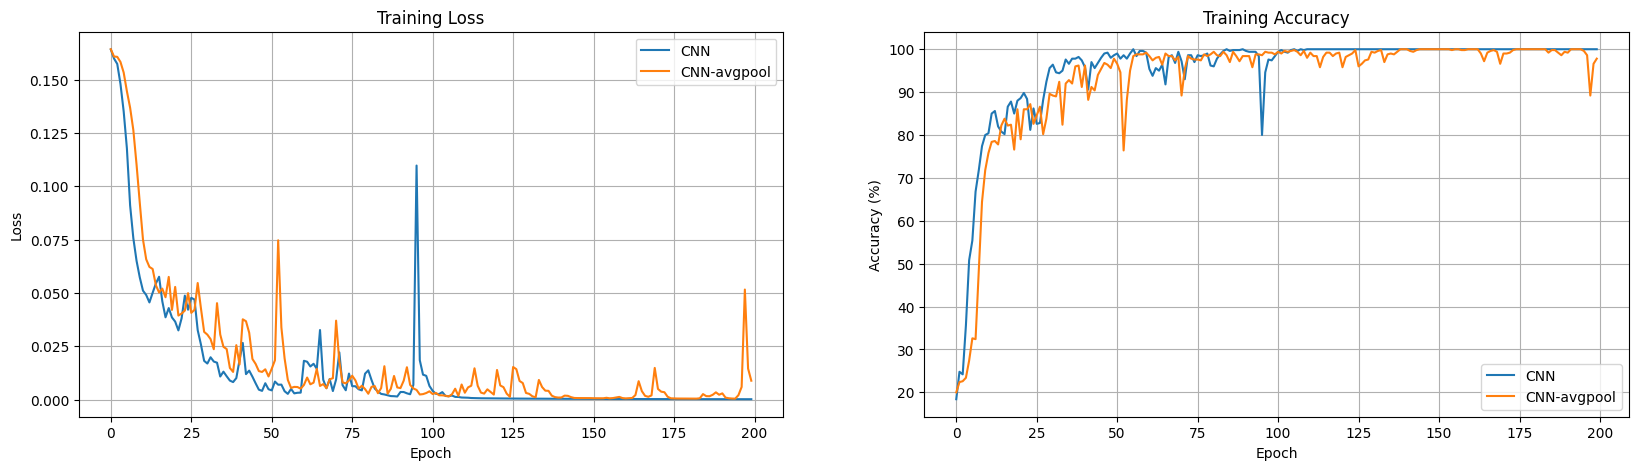

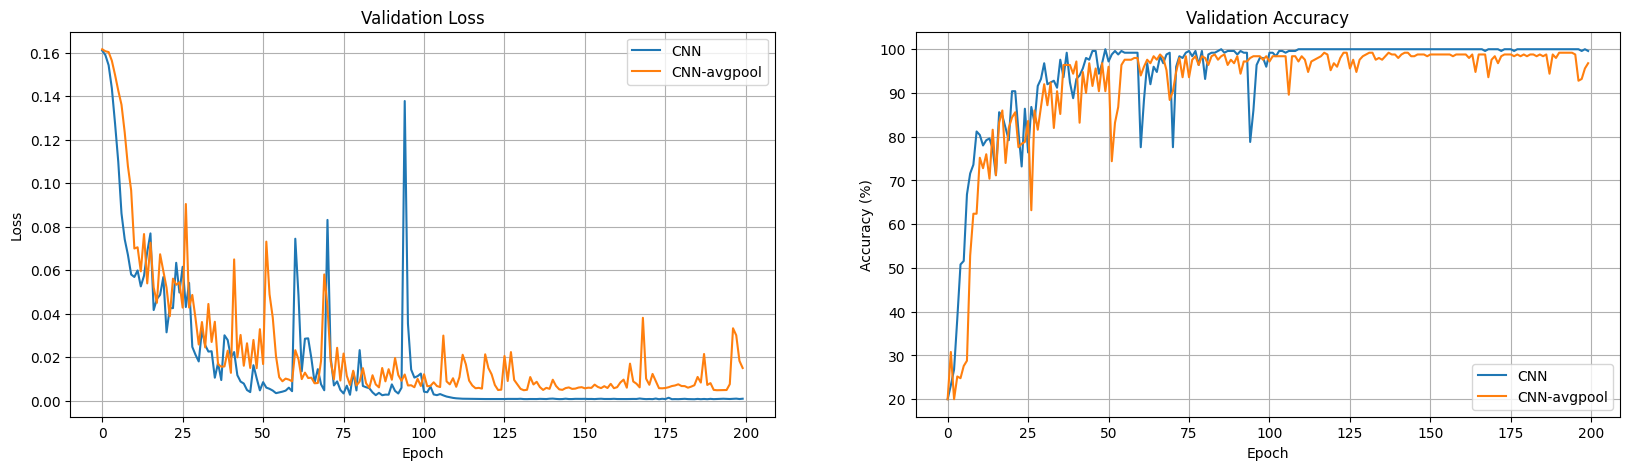

CNN-maxpool Acc: 99.6, CNN-avgpool Acc: 96.8


In [ ]:
lr = 1e-2
num_epochs = 200
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

cnnavg_kernel_dict = dict()

for num_image, train_loader in train_loader_dict.items():
    print("Training with {} images".format(num_image))
    set_seed(seed)

    cnnavg_model = SimpleCNN_avgpool(kernel_size=7, num_classes=5)
    cnnavg_model.to(device)

    cnnavg_optimizer = optim.SGD(cnnavg_model.parameters(), lr=lr, momentum=0.9)

    cnnavg_results = train_model(cnnavg_model, cnnavg_optimizer, num_epochs, train_loader, valid_loader)
    cnn_results = cnn_result_dict[num_image]

    vis_training_curve(cnn_results["train_loss"], cnn_results["train_acc"], cnnavg_results["train_loss"], cnnavg_results["train_acc"], label="CNN-avgpool")
    vis_validation_curve(cnn_results["valid_loss"], cnn_results["valid_acc"], cnnavg_results["valid_loss"], cnnavg_results["valid_acc"], label="CNN-avgpool")

    cnnavg_kernel_dict[num_image] = cnnavg_model.conv1.weight.detach().cpu()

    print("CNN-maxpool Acc: {}, CNN-avgpool Acc: {}".format(cnn_results["final_valid_acc"], cnnavg_results["final_valid_acc"]))

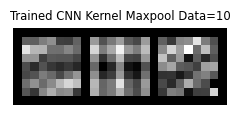

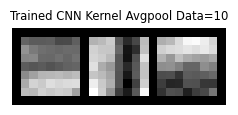

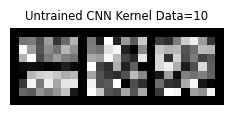

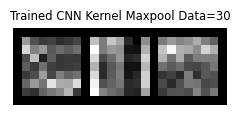

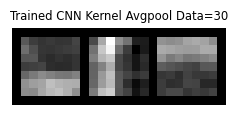

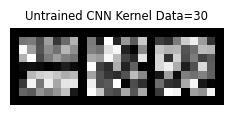

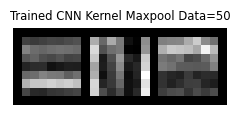

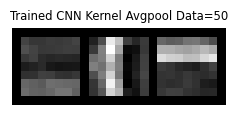

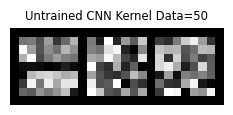

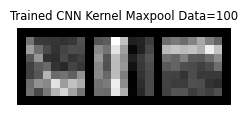

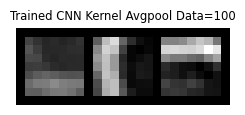

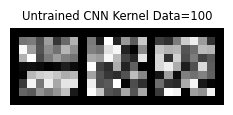

In [ ]:
for num_image, cnn_kernel in cnn_kernel_dict.items():
    untrained_kernel = untrained_cnn_kernel_dict[num_image]
    cnnavg_kernel = cnnavg_kernel_dict[num_image]
    vis_kernel(cnn_kernel, ch=0, allkernels=False, title='Trained CNN Kernel Maxpool Data={}'.format(num_image))
    vis_kernel(cnnavg_kernel, ch=0, allkernels=False, title='Trained CNN Kernel Avgpool Data={}'.format(num_image))
    vis_kernel(untrained_kernel, ch=0, allkernels=False, title='Untrained CNN Kernel Data={}'.format(num_image))

plt.show()

PART 7

100%|██████████| 300/300 [01:00<00:00,  4.94it/s]


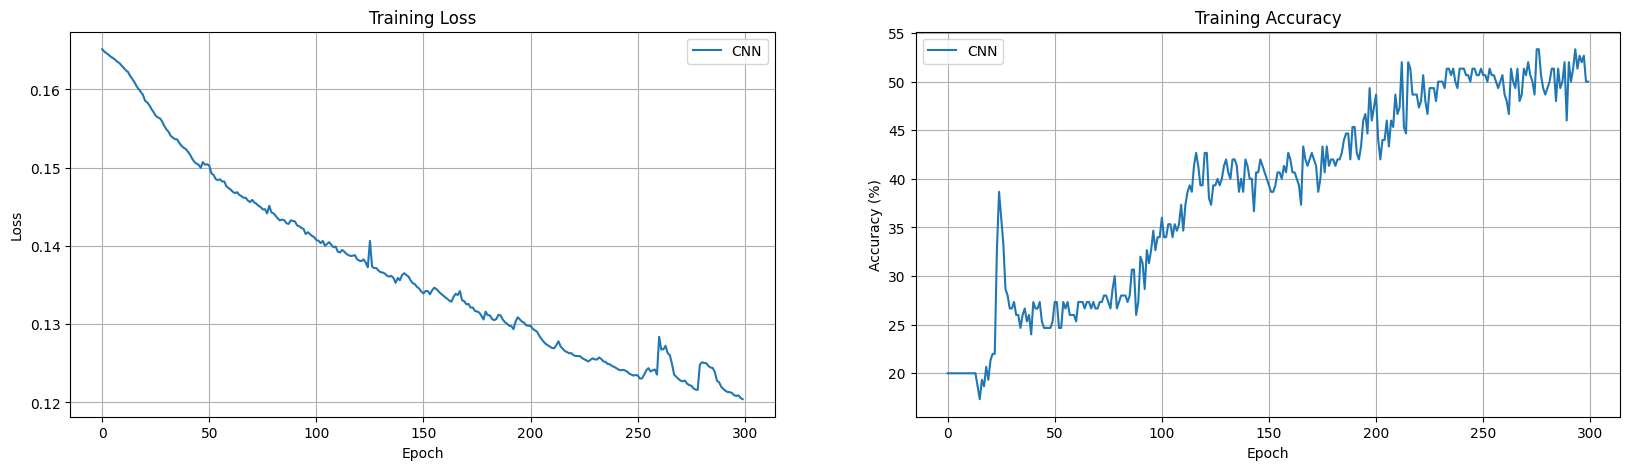

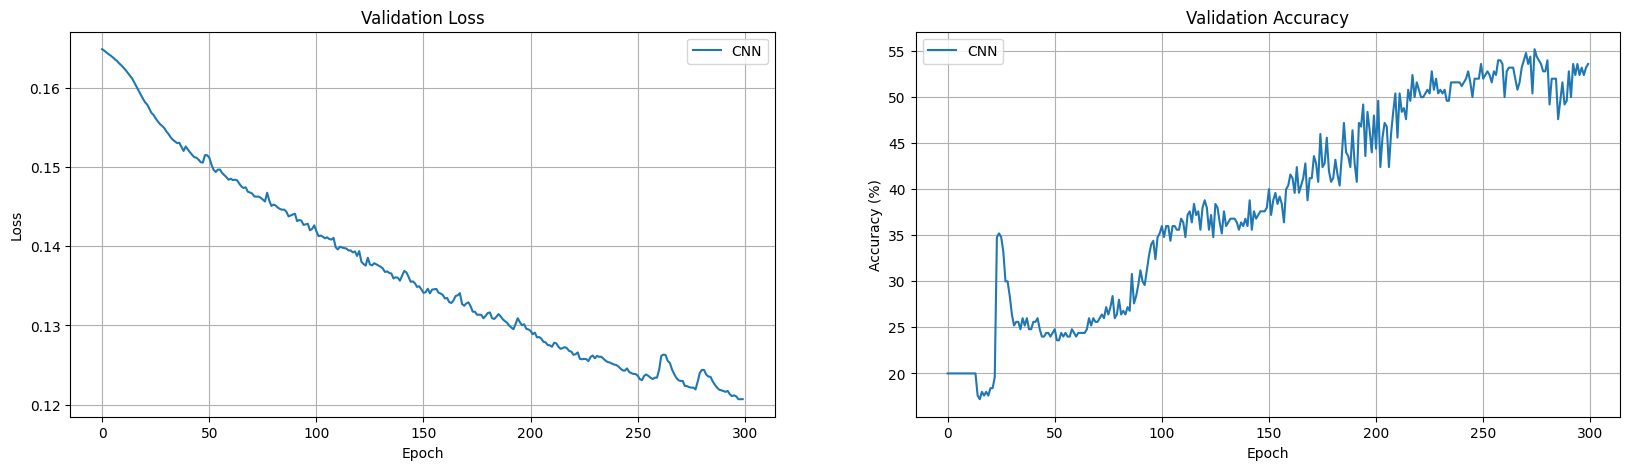

CNN Acc: 53.6000


In [ ]:
num_epochs = 300
lr = 0.001
kernel_size = 3

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

train_loader = train_loader_dict[30]

set_seed(seed)
deeper_cnn_model = DeeperCNN(kernel_size=kernel_size)
untrained_deeper_cnn_model = deepcopy(deeper_cnn_model)
deeper_cnn_model.to(device)

deeper_cnn_optimizer = optim.Adam(deeper_cnn_model.parameters(), lr=lr)
# deeper_cnn_optimizer = optim.SGD(deeper_cnn_model.parameters(), lr=lr, momentum=0.9)

deeper_cnn_results = train_model(deeper_cnn_model, deeper_cnn_optimizer, num_epochs, train_loader, valid_loader)

vis_training_curve(deeper_cnn_results["train_loss"], deeper_cnn_results["train_acc"], None, None)
vis_validation_curve(deeper_cnn_results["valid_loss"], deeper_cnn_results["valid_acc"], None, None)

print("CNN Acc: {:.4f}".format(deeper_cnn_results["final_valid_acc"]))


100%|██████████| 300/300 [00:47<00:00,  6.28it/s]


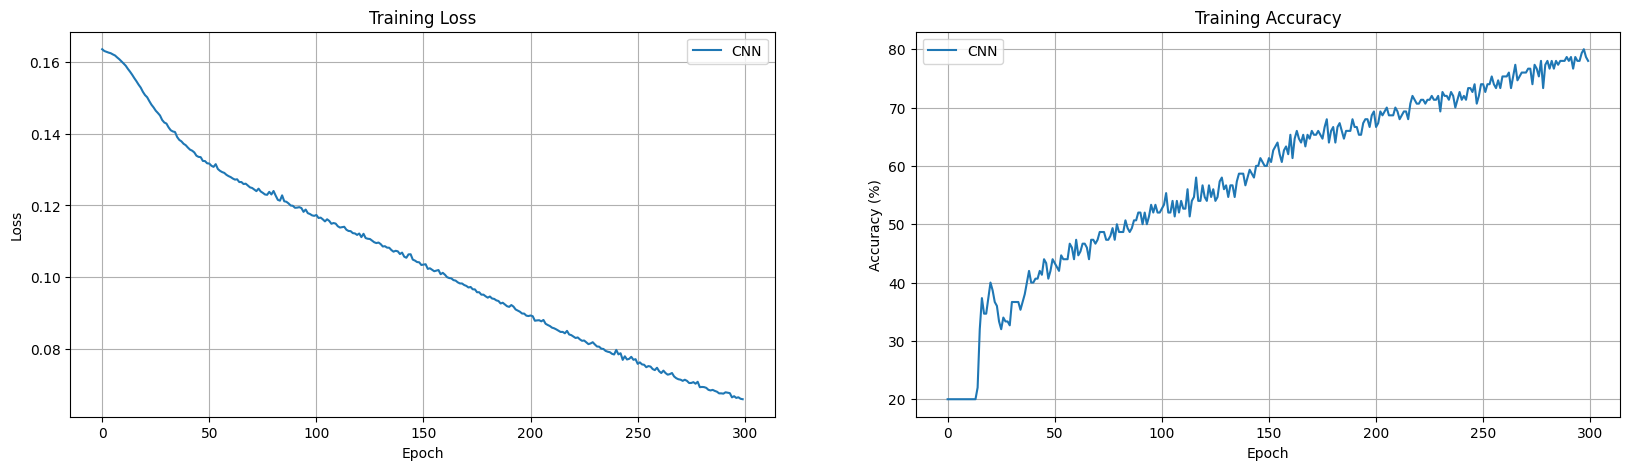

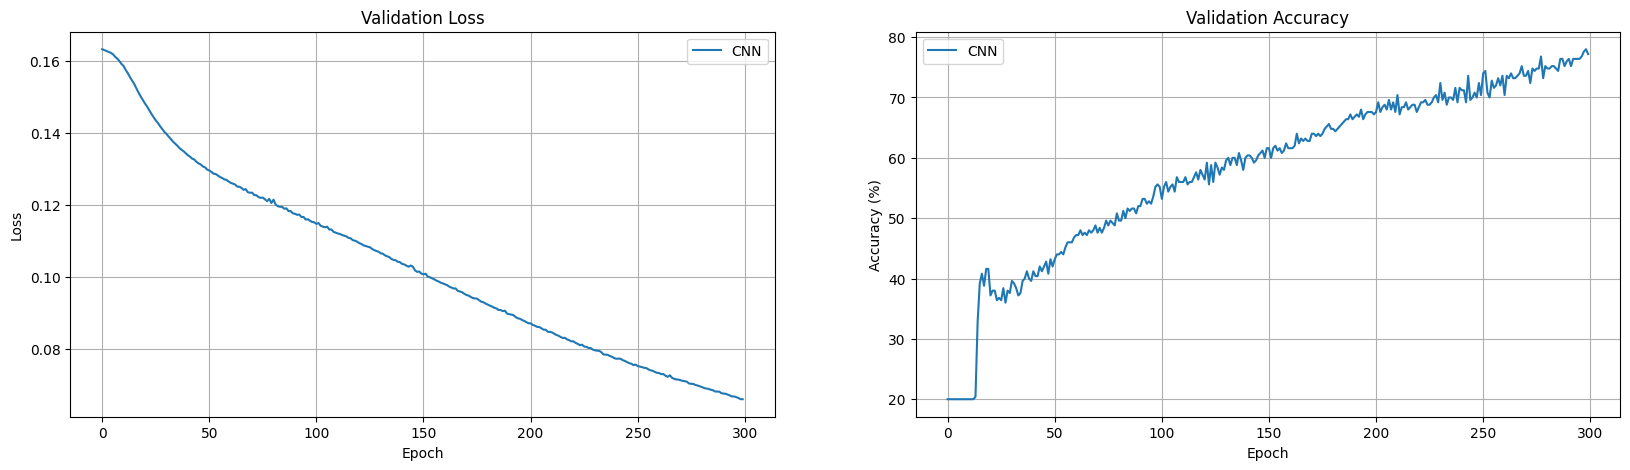

CNN Acc: 77.2000


In [ ]:
num_epochs = 300
lr = 0.001
kernel_size = 3

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
criterion = nn.CrossEntropyLoss()

train_loader = train_loader_dict[30]

set_seed(seed)
wider_cnn_model = WiderCNN(kernel_size=kernel_size)
untrained_wider_cnn_model = deepcopy(wider_cnn_model)
wider_cnn_model.to(device)

wider_cnn_optimizer = optim.Adam(wider_cnn_model.parameters(), lr=lr)
# wider_cnn_optimizer = optim.SGD(wider_cnn_model.parameters(), lr=lr, momentum=0.9)

wider_cnn_results = train_model(wider_cnn_model, wider_cnn_optimizer, num_epochs, train_loader, valid_loader)

vis_training_curve(wider_cnn_results["train_loss"], wider_cnn_results["train_acc"], None, None)
vis_validation_curve(wider_cnn_results["valid_loss"], wider_cnn_results["valid_acc"], None, None)

print("CNN Acc: {:.4f}".format(wider_cnn_results["final_valid_acc"]))
